### 第17組: 以 PTT 數據挖掘日韓旅遊差異與滿意度對比

#### 資料來源        
PTT 「日旅版」與「韓旅版」2025/06/1至2026/06/01的資料，「日旅版」共 1122筆資料，「韓旅版」共 1078 筆資料。

#### 動機與目的
日本與韓國作為台灣民眾出國觀光的兩大首選，在社群媒體上累積了極為龐大的討論聲量。    
以PTT 的「日旅版」與「韓旅版」為資料來源，旨在對比並挖掘出日韓兩國在鄉民討論中的核心差異與關鍵特徵。另外，運用情緒字典進行情緒分析，進而發掘兩國的滿意度落差，找出引發鄉民抱怨的雷點。

#### 資料清理

In [ ]:
import pandas as pd
import jieba
import jieba.analyse
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

c:\Users\orika\anaconda3\envs\sma2026\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
df_j = pd.read_csv('raw_data/japan.csv')
df_k = pd.read_csv('raw_data/korea.csv')
df_j.head(3)

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource,country
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,pttbird,Japan_Travel,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""Hurubear"", ""...",61.220.191.67,2025/5/28 01:26,ptt,日本
1,2,https://www.ptt.cc/bbs/Japan_Travel/M.17483327...,[問題]高千穗一日遊疑問,2025/5/27 15:59,n61208,Japan_Travel,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""Dheroblood"",...",223.141.206.76,2025/5/28 01:26,ptt,日本
2,3,https://www.ptt.cc/bbs/Japan_Travel/M.17483552...,[問題]花火大會選擇（葛飾納涼/熱海/隅田川）,2025/5/27 22:13,angelstar,Japan_Travel,１． 出遊日期： 2025年7月下旬\n\n２． 行程：想參加花火大會（帶小孩）\n\n３．...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""leejones"", ""...",123.192.200.9,2025/5/28 01:26,ptt,日本


In [ ]:
df_k.head(3)

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource,country
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,Aaron22,Korea_Travel,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""lakai199"", ""...",49.216.53.202,2023/4/28 01:50,ptt,韓國
1,2,https://www.ptt.cc/bbs/Korea_Travel/M.16825675...,[問題]睡機場或其他,2023/4/27 11:53,massaget,Korea_Travel,各位大大好，小弟即將在下個月前往韓國\n由於虎航的的班機表定是01:30到仁川機場，一航的過...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""dbdudsorj"", ...",118.163.134.243,2023/4/28 01:50,ptt,韓國
2,3,https://www.ptt.cc/bbs/Korea_Travel/M.16826436...,[遊記]首爾｜6天5夜自由行。景點美食與城市體驗,2023/4/28 08:59,abc9442,Korea_Travel,圖文網誌建議閱讀版：\nhttps://listentolu.com/2023/04/seo...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""richuncle97""...",101.12.49.111,2023/4/30 01:54,ptt,韓國


In [ ]:
#-------------日本--------------#
clear_df_j = df_j.copy()

#去除本次不會用到的欄位
drop_cols = ['system_id', 'artUrl', 'artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource']
clear_df_j.drop(drop_cols, axis = 1, inplace = True)

#去除文章內容為空值的筆數
clear_df_j.dropna(subset = ['artContent'], axis=0, how='any', inplace=True)

#新增['sentence']欄位，用'。'取代'\n\n'，並移除'\n'
clear_df_j['sentence'] = clear_df_j['artContent'].str.replace(r'\n\n','。', regex=True)
clear_df_j['sentence'] = clear_df_j['sentence'].str.replace(r'\n','，', regex=True)

#移除內文中的網址
clear_df_j['sentence'] = clear_df_j['sentence'].replace(r'http\S+', '', regex=True).replace(r'www\S+', '', regex=True)

clear_df_j.head(10)

,artTitle,artDate,artContent,country,sentence
0,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版。之前研究了一輪神戶住宿。離三宮車站近+經濟實惠+一定水準。看到最優...
1,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,家人週末想在當地參加kkday一日遊行程，看了幾個套裝大同小異，唯獨幾個景點稍微不同，想請教...
2,[問題]花火大會選擇（葛飾納涼/熱海/隅田川）,2025/5/27 22:13,１． 出遊日期： 2025年7月下旬\n\n２． 行程：想參加花火大會（帶小孩）\n\n３．...,日本,１． 出遊日期： 2025年7月下旬。２． 行程：想參加花火大會（帶小孩）。３． 特別希望：...
3,Re:[問題]函館四天三夜&還可以去哪些城市/地方,2025/5/27 22:53,晚安 我是原Po\n不好意思有些函館 交通的問題想請教\n\n因為查了一些文章 還是有些細節...,日本,晚安 我是原Po，不好意思有些函館 交通的問題想請教。因為查了一些文章 還是有些細節不確定。...
4,[問題]東北楓葉推薦10月底還是11月初？,2025/5/27 23:43,今年想規劃到東北賞楓葉(7天)\n預計從青森出發往南至仙台，大致如下：\nDay1-2 弘前...,日本,今年想規劃到東北賞楓葉(7天)，預計從青森出發往南至仙台，大致如下：，Day1-2 弘前、奧...
5,[問題]北海道道央六天五夜請益,2025/5/28 01:06,行程請教範例\n\n１． 出遊日期： 6/24-6/29\n\n２． 每日行程：這次和老婆及...,日本,行程請教範例。１． 出遊日期： 6/24-6/29。２． 每日行程：這次和老婆及兒子（小學畢...
6,[問題]9月初東京自由行帶長輩，近郊一日遊建議,2025/5/28 13:53,大家好，這邊是第一次發文的新手旅人\n預計在今年9月初安排一趟東京自由行，包括 2 位年約 ...,日本,大家好，這邊是第一次發文的新手旅人，預計在今年9月初安排一趟東京自由行，包括 2 位年約 6...
7,[遊記]五島走透透在宇久島獨享海洋與海島,2025/5/28 14:47,旅遊日期：2025年4月16日\n\n有照片完整圖文網誌版：\nhttps://journa...,日本,旅遊日期：2025年4月16日。有照片完整圖文網誌版：， – 平清盛，的弟弟。。時間逐漸接近...
8,[遊記]岡山之倉敷美觀地區&夜間打光姬路城,2025/5/28 17:57,造訪日期：2025年2月\n\n好讀網誌版：\nhttps://littlem0908.pi...,日本,造訪日期：2025年2月。好讀網誌版：，
9,[讓售]東京地鐵一日券大人2張,2025/5/28 20:15,1. 讓售品項：\n東京地鐵一日券大人X ２ 期限至 2026-4-24\n\n2.物品...,日本,1. 讓售品項：，東京地鐵一日券大人X ２ 期限至 2026-4-24。2.物品圖片：，...


In [ ]:
#-------------韓國--------------#
clear_df_k = df_k.copy()

#去除本次不會用到的欄位
drop_cols = ['system_id', 'artUrl', 'artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource']
clear_df_k.drop(drop_cols, axis = 1, inplace = True)

#去除文章內容為空值的筆數
clear_df_k.dropna(subset = ['artContent'], axis=0, how='any', inplace=True)

#新增['sentence']欄位，用'。'取代'\n\n'，並移除'\n'
clear_df_k['sentence'] = clear_df_k['artContent'].str.replace(r'\n\n','。', regex=True)
clear_df_k['sentence'] = clear_df_k['sentence'].str.replace(r'\n','，', regex=True)

#移除內文中的網址
clear_df_k['sentence'] = clear_df_k['sentence'].replace(r'http\S+', '', regex=True).replace(r'www\S+', '', regex=True)

clear_df_k.head(10)

,artTitle,artDate,artContent,country,sentence
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐，不去就醫，...
1,[問題]睡機場或其他,2023/4/27 11:53,各位大大好，小弟即將在下個月前往韓國\n由於虎航的的班機表定是01:30到仁川機場，一航的過...,韓國,各位大大好，小弟即將在下個月前往韓國，由於虎航的的班機表定是01:30到仁川機場，一航的過境...
2,[遊記]首爾｜6天5夜自由行。景點美食與城市體驗,2023/4/28 08:59,圖文網誌建議閱讀版：\nhttps://listentolu.com/2023/04/seo...,韓國,圖文網誌建議閱讀版：， (欸)。直到最近從沒飛過韓國的老弟也來問我首爾推不推薦，哪裡好玩？。...
3,[問題]請問金浦機場幾個問題,2023/4/28 12:48,1. 住宿的地點在東大門歷史文化公園站\n用subway app查詢從金浦機場過去有兩種方式...,韓國,1. 住宿的地點在東大門歷史文化公園站，用subway app查詢從金浦機場過去有兩種方式，...
4,[住宿]首爾乙支路高爺商業公寓樓下機場巴士,2023/4/29 21:34,"住宿名稱：乙支路高爺商業公寓\n 入住時間：112年3月\n 住宿地址：246, E...",韓國,"住宿名稱：乙支路高爺商業公寓， 入住時間：112年3月， 住宿地址：246, Eul..."
5,[徵求]5/5-5/20首爾,2023/4/30 22:03,徵求類別：食伴or 旅伴\n原PO性別：男27\n徵 求：5/5-5/20 一起吃飯喝酒或...,韓國,徵求類別：食伴or 旅伴，原PO性別：男27，徵 求：5/5-5/20 一起吃飯喝酒或是出...
6,[徵求]釜山5/8-15旅伴食伴,2023/5/1 22:44,徵求類別：旅伴食伴\n 原PO性別：1981老男孩\n 徵 求：徵一位同路旅伴/食伴分...,韓國,徵求類別：旅伴食伴， 原PO性別：1981老男孩， 徵 求：徵一位同路旅伴/食伴分享旅...
7,[食記]釜山海景咖啡廳與餐廳H.US/松香韓定食,2023/5/1 23:32,【釜山】 青沙浦 H.US 可遠眺燈塔的海景咖啡廳\n\n圖文版：\nhttps://www...,韓國,【釜山】 青沙浦 H.US 可遠眺燈塔的海景咖啡廳。圖文版：， BUSAN PASS，且不想...
8,[遊記]江源航空4/30停飛取消,2023/5/1 23:41,4/27-4/30搭乘江原航空去襄陽的旅遊，在30號一早到達機場後看到班機顯示全部都取消（c...,韓國,4/27-4/30搭乘江原航空去襄陽的旅遊，在30號一早到達機場後看到班機顯示全部都取消（c...
9,[反推]反推DJB韓流卡,2023/5/2 00:12,先講結論:韓國上網最好找大公司服務\n\n我與朋友於DJB官網上購買4日韓國上網實體SIM卡...,韓國,先講結論:韓國上網最好找大公司服務。我與朋友於DJB官網上購買4日韓國上網實體SIM卡，當天...


#### 斷句

In [ ]:
#-------------日本--------------#
clear_df_j['sentence'] = clear_df_j['sentence'].str.split("[,，。！!？?]{1,}")

sent_df_j = clear_df_j.explode('sentence').reset_index(drop=True)

sent_df_j.head(10)

,artTitle,artDate,artContent,country,sentence
0,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,之前研究了一輪神戶住宿
2,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,離三宮車站近+經濟實惠+一定水準
3,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,看到最優選擇應該就是Brenza了
4,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,雖然還沒入住無法提供心得
5,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,但是帳目數據上看起來是不錯的
6,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,
7,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,家人週末想在當地參加kkday一日遊行程
8,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,看了幾個套裝大同小異
9,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,唯獨幾個景點稍微不同


In [ ]:
#-------------韓國--------------#
clear_df_k['sentence'] = clear_df_k['sentence'].str.split("[,，。！!？?]{1,}")

sent_df_k = clear_df_k.explode('sentence').reset_index(drop=True)

sent_df_k.head(10)

,artTitle,artDate,artContent,country,sentence
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,在旅途的最後一晚突然胃痛不適
2,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,想說隔天一早就要回台
3,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,決定硬撐
4,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,不去就醫
5,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,直接返台
6,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,到機場報到完
7,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,看到藥局變去詢問是否有胃藥可以緩解不適（靠翻譯
8,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,軟體）
9,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,銷售人員販售我10條「處方藥」


#### 斷詞

In [ ]:
# 初始化斷詞引擎：不一定要設定，只使用內建效果也可以
# 參考網址：https://raw.githubusercontent.com/ldkrsi/jieba-zh_TW/master/jieba/dict.txt
jieba.set_dictionary('dict/dict.txt')
jieba.load_userdict('dict/user_dict.txt')
jieba.add_word('日旅版')
jieba.add_word('韓旅版')

Building prefix dict from c:\Users\orika\Desktop\socialmdeia_final\dict\dict.txt ...
Dumping model to file cache C:\Users\orika\AppData\Local\Temp\jieba.u4acfdb2611b9c85516ff1848d831a1c4.cache
Loading model cost 0.995 seconds.
Prefix dict has been built successfully.


In [ ]:
#-------------日本--------------#
#去除句子中除了字母、數字、空白字符以外的符號
sent_df_j['sentence'] = sent_df_j['sentence'].str.replace(r'[^\w\s]+', '', regex=True).astype(str)

# 把長度小於1的sentence刪掉
sent_df_j = sent_df_j[sent_df_j["sentence"].str.len() > 1]

sent_df_j.head(10)

,artTitle,artDate,artContent,country,sentence
0,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,之前研究了一輪神戶住宿
2,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,離三宮車站近經濟實惠一定水準
3,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,看到最優選擇應該就是Brenza了
4,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,雖然還沒入住無法提供心得
5,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,但是帳目數據上看起來是不錯的
7,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,家人週末想在當地參加kkday一日遊行程
8,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,看了幾個套裝大同小異
9,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,唯獨幾個景點稍微不同
10,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,想請教各位的看法


In [ ]:
#-------------韓國--------------#
#去除句子中除了字母、數字、空白字符以外的符號
sent_df_k['sentence'] = sent_df_k['sentence'].str.replace(r'[^\w\s]+', '', regex=True).astype(str)

# 把長度小於1的sentence刪掉
sent_df_k = sent_df_k[sent_df_k["sentence"].str.len() > 1]

sent_df_k.head(10)

,artTitle,artDate,artContent,country,sentence
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,在旅途的最後一晚突然胃痛不適
2,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,想說隔天一早就要回台
3,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,決定硬撐
4,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,不去就醫
5,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,直接返台
6,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,到機場報到完
7,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,看到藥局變去詢問是否有胃藥可以緩解不適靠翻譯
8,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,軟體
9,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,銷售人員販售我10條處方藥


In [ ]:
#-------------日本--------------#
word_df_j = sent_df_j.assign(word = sent_df_j['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

# 去除空值
word_df_j = word_df_j.dropna(subset=['word'])

word_df_j = word_df_j.loc[word_df_j['word'].str.len() > 1]

word_df_j.head(10)

,artTitle,artDate,artContent,country,word
0,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,之於
0,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,日旅版
0,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,回饋
0,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,日旅版
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,之前
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,研究
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,一輪
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,神戶
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,住宿
2,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,三宮


In [ ]:
#-------------韓國--------------#
word_df_k = sent_df_k.assign(word = sent_df_k['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

# 去除空值
word_df_k = word_df_k.dropna(subset=['word'])

word_df_k = word_df_k.loc[word_df_k['word'].str.len() > 1]

word_df_k.head(10)

,artTitle,artDate,artContent,country,word
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,初去
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,首爾
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,旅遊
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,旅途
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,最後
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,一晚
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,突然
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,胃痛
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,不適


#### 移除停用字

In [ ]:
# 以檔案形式匯入通用的停用字檔案
# 將stopwords存成list
stopwords = [line.strip() for line in open('dict/stopwords.txt', 'r', encoding='utf-8').readlines()]
stopwords_manual = ["日旅版", "韓旅版", "日本", "韓國", "旅遊", "現在", "因為", "沒有", "可以", "真的", "自己", "覺得", "不知道", "一個", "時間", "第一天", "已經", "我們", "這個", "請問", "其實", "發現", "還是", "知道", "請問一下"]
stopwords_manual.extend(["看到", "前往", "使用", "直接", "下午", "行程", "飯店", "機場","謝謝"])
stopwords_manual.extend([
    "最後","目前","附近","推薦","建議","需要","PO","10",
    "喜歡","選擇","分鐘","小時","目前","XD","不錯","感覺",
    "安排","地方","一下","真的","覺得","推薦", "搭乘", "需要", "時間", "使用", "分享", "朋友", "問題", "行程", "已經", "的話", "大概", "部分", "大家"
])

stopwords.extend(stopwords_manual)

In [ ]:
#-------------日本--------------#
noStop_df_j = word_df_j[~word_df_j['word'].isin(stopwords)]
noStop_df_j.head()

,artTitle,artDate,artContent,country,word
0,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,之於
0,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,回饋
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,研究
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,一輪
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,神戶


In [ ]:
#-------------韓國--------------#
noStop_df_k = word_df_k[~word_df_k['word'].isin(stopwords)]
noStop_df_k.head()

,artTitle,artDate,artContent,country,word
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,初去
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,首爾
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,旅途
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,一晚


## 2. 計算詞頻 & 生成文字雲

#### 2.1 計算詞頻

In [ ]:
#-------------日本--------------#
freq_df_j = pd.DataFrame(noStop_df_j['word'].value_counts()).sort_values(by = ['count'], ascending = False).reset_index()
freq_df_j.head(10)

,word,count
0,預約,654
1,車站,599
2,東京,555
3,日期,549
4,住宿,530
5,溫泉,528
6,公園,519
7,神社,495
8,晚上,483
9,排隊,473


In [ ]:
#-------------韓國--------------#
freq_df_k = pd.DataFrame(noStop_df_k['word'].value_counts()).sort_values(by = ['count'], ascending = False).reset_index()
freq_df_k.head(10)

,word,count
0,首爾,1162
1,釜山,904
2,市場,359
3,明洞,336
4,行李,307
5,樂天,300
6,景點,292
7,地鐵,291
8,計程車,286
9,餐廳,280


In [ ]:
noStop_df_j[noStop_df_j['word'] == ('10')]['word'].count()

0

In [ ]:
# 設定圖的字體大小
plt.rcParams['font.size'] = 14

# 設定圖的中文字體 (無法顯示的話可以試試‘Microsoft JhengHei’字體)
# 也可參考：https://pyecontech.com/2020/03/27/python_matplotlib_chinese/
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows 中文字體

# 設定文字雲中文字體路徑
FontPath = 'raw_data/SourceHanSansTW-Regular.otf' # 設定字型

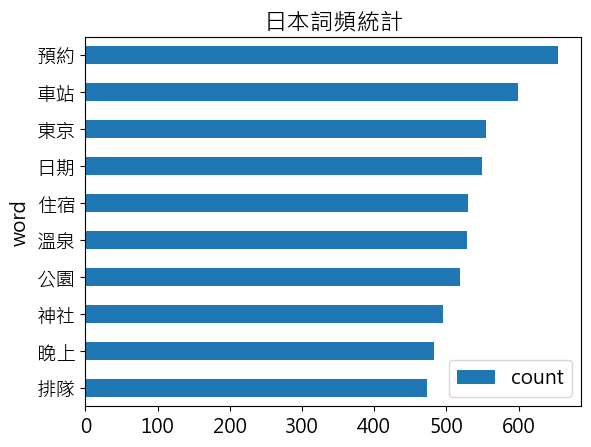

In [ ]:
freq_df_j.head(10).plot.barh(x = 'word', y = 'count',title='日本詞頻統計').invert_yaxis()
plt.show()

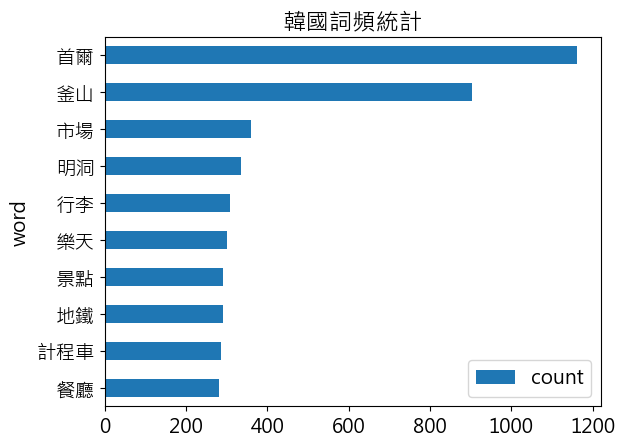

In [ ]:
freq_df_k.head(10).plot.barh(x = 'word', y = 'count',title='韓國詞頻統計').invert_yaxis()
plt.show()

#### 2.2 文字雲

In [ ]:
# wordcloud的輸入須為dict，因此先將freq_df轉換成成dict
freq_dict_j = freq_df_j.set_index('word').to_dict()
freq_dict_j = freq_dict_j['count']

freq_dict_k = freq_df_k.set_index('word').to_dict()
freq_dict_k = freq_dict_k['count']

# 繪製文字雲
wordcloud_j = WordCloud(background_color = 'white', width = 800, height = 400, font_path = FontPath, max_words = 50)
wordcloud_j.generate_from_frequencies(freq_dict_j)

wordcloud_k = WordCloud(background_color = 'white', width = 800, height = 400, font_path = FontPath, max_words = 50)
wordcloud_k.generate_from_frequencies(freq_dict_k)


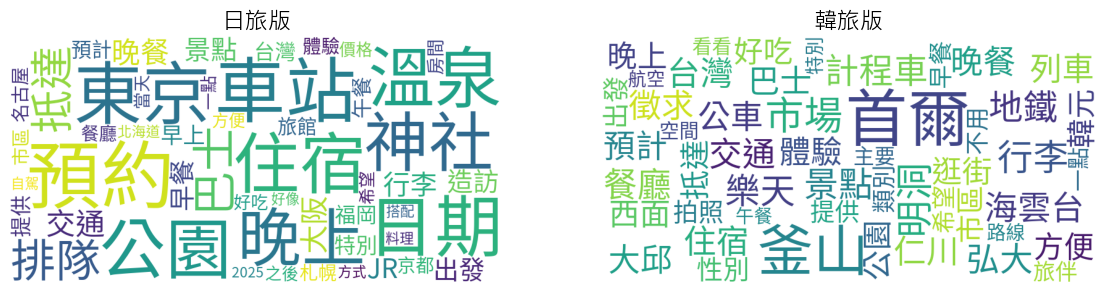

In [ ]:
plt.figure(figsize = (14,8))

plt.subplot(1,2,1)
plt.imshow(wordcloud_j)
plt.axis('off')
plt.title("日旅版")

plt.subplot(1,2,2)
plt.imshow(wordcloud_k)
plt.axis('off')
plt.title("韓旅版")

plt.show()

## 3. Lexicon-based 情緒分析
進行基於情緒字典的情緒分析，首先需要準備情緒字典後再將字典與斷詞後的文章進行合併

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import Colormap
from wordcloud import WordCloud
import jieba
%matplotlib inline

In [ ]:
# plt.rcParams['font.sans-serif']=['SimHei'] #使 matplotilb 中文能正常顯示
fprop = fm.FontProperties(fname="./raw_data/SourceHanSansTW-Regular.otf")

# 設定整份 notebook 圖片的長寬與 dpi
plt.rcParams["figure.figsize"] = [6, 4]
plt.rcParams["figure.dpi"] = 150

## 3.1 使用課程範例提供之LIWC字典  

In [ ]:
# 讀取情緒字典
liwc_dict = pd.read_csv("./dict/liwc/LIWC_CH.csv")
liwc_dict = liwc_dict.rename(columns={'name': 'word', "class": 'sentiments'})
liwc_dict.head()

,word,sentiments
0,):,affect
1,3q,affect
2,:(,affect
3,:),affect
4,<3,affect


In [ ]:
liwc_dict['sentiments'].describe()

count       4682
unique         6
top       affect
freq        2061
Name: sentiments, dtype: object

## 3.2 情緒字典與斷詞結果進行合併
將情緒字典與斷詞結果進行合併。

### 3.2.1 日旅版 斷詞合併

In [ ]:
liwc_df_j = pd.merge(noStop_df_j[[ "artTitle", "artDate", "artContent", "country", "word"]], liwc_dict, how="left", on="word")
liwc_df_j['artDate'] = pd.to_datetime(liwc_df_j['artDate']).dt.date
liwc_df_j.head()

,artTitle,artDate,artContent,country,word,sentiments
0,Re:[問題]神戶住宿選擇,2025-05-27,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,之於,NaN
1,Re:[問題]神戶住宿選擇,2025-05-27,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,回饋,NaN
2,Re:[問題]神戶住宿選擇,2025-05-27,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,研究,NaN
3,Re:[問題]神戶住宿選擇,2025-05-27,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,一輪,NaN
4,Re:[問題]神戶住宿選擇,2025-05-27,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,神戶,NaN


### 3.2.2 韓旅版 斷詞合併

In [ ]:
liwc_df_k = pd.merge(noStop_df_k[[ "artTitle", "artDate", "artContent", "country", "word"]], liwc_dict, how="left", on="word")
liwc_df_k['artDate'] = pd.to_datetime(liwc_df_k['artDate']).dt.date
liwc_df_k.head()

,artTitle,artDate,artContent,country,word,sentiments
0,「韓國旅遊局」投訴真的有用！,2023-04-27,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月,NaN
1,「韓國旅遊局」投訴真的有用！,2023-04-27,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,初去,NaN
2,「韓國旅遊局」投訴真的有用！,2023-04-27,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,首爾,NaN
3,「韓國旅遊局」投訴真的有用！,2023-04-27,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,旅途,NaN
4,「韓國旅遊局」投訴真的有用！,2023-04-27,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,一晚,NaN


## 3.3 正負向情緒詞彙頻率折線圖圖
分別畫出關於日本旅遊和韓國旅遊的正向與負向情緒的折線圖

### 3.3.1 日旅版情感詞彙頻率

In [ ]:
sentiment_count_j = pd.DataFrame(
    liwc_df_j.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count_j['sentiments'] == "positive") | (sentiment_count_j['sentiments'] == "negative")
sentiment_count_j = sentiment_count_j.loc[mask]

sentiment_count_j = sentiment_count_j.rename(columns={0: "size"})
sentiment_count_j = sentiment_count_j.sort_values(["artDate"])
sentiment_count_j.head(10)

,artDate,sentiments,size
2,2025-05-27,negative,1
3,2025-05-27,positive,8
8,2025-05-28,negative,11
9,2025-05-28,positive,38
13,2025-05-29,negative,18
14,2025-05-29,positive,52
18,2025-05-30,negative,7
19,2025-05-30,positive,32
23,2025-05-31,negative,9
24,2025-05-31,positive,34


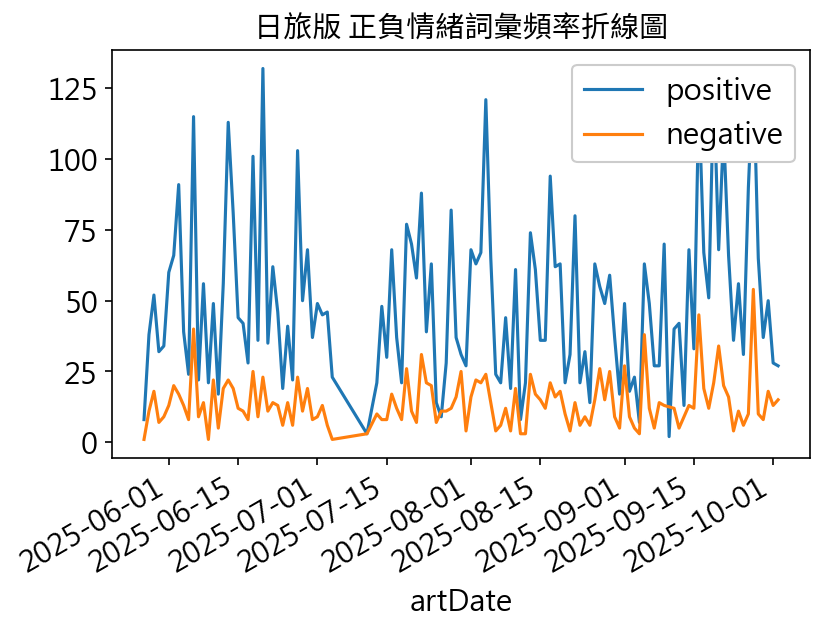

In [ ]:
colors = ["tab:blue", "tab:orange"]
pos_j = sentiment_count_j[sentiment_count_j["sentiments"] == "positive"]
neg_j = sentiment_count_j[sentiment_count_j["sentiments"] == "negative"]


fig, ax = plt.subplots()

ax.plot(pos_j["artDate"], pos_j["size"], color=colors[0])
ax.plot(neg_j["artDate"], neg_j["size"], color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right", framealpha=1)
fig.autofmt_xdate()
plt.title("日旅版 正負情緒詞彙頻率折線圖", fontproperties=fprop)  #
plt.show()

### 日旅版Rolling Average

使用滾動平均有助於平滑數據，使情緒趨勢更加清晰。
1. 去除瞬間噪聲： 情緒數據可能受到瞬間事件或噪聲的影響，例如突發的大量評論或新聞。滾動平均有助於平滑這些突變，使你更容易觀察到整體趨勢。
2. 強調長期趨勢： 滾動平均有助於強調長期情緒趨勢，而不受短期波動的干擾。這對於觀察情緒的漸變和長期變化非常有用。

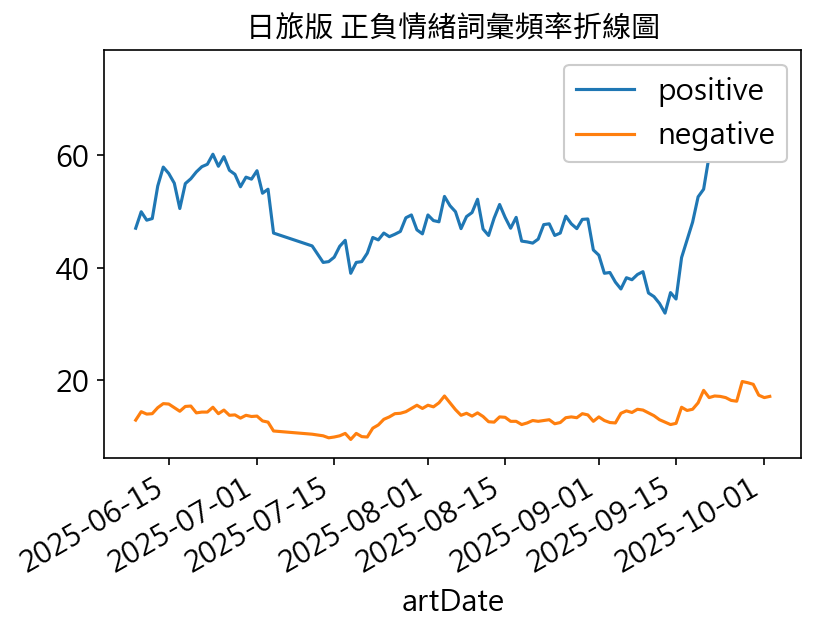

In [ ]:
colors = ["tab:blue", "tab:orange"]
pos_j = sentiment_count_j[sentiment_count_j["sentiments"] == "positive"]
neg_j = sentiment_count_j[sentiment_count_j["sentiments"] == "negative"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos_j["artDate"], pos_j['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg_j["artDate"], neg_j["size"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right", framealpha=1)
fig.autofmt_xdate()
plt.title("日旅版 正負情緒詞彙頻率折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

### 3.3.2 韓旅版情感詞彙頻率

In [ ]:
liwc_df_k['artDate'] = pd.to_datetime(liwc_df_k['artDate']).dt.date

sentiment_count_k = pd.DataFrame(
    liwc_df_k.groupby(["artDate", "sentiments"]).size()
).reset_index()


mask = (sentiment_count_k['sentiments'] == "positive") | (sentiment_count_k['sentiments'] == "negative")
sentiment_count_k = sentiment_count_k.loc[mask]

sentiment_count_k = sentiment_count_k.rename(columns={0: "size"})
sentiment_count_k = sentiment_count_k.sort_values(["artDate"])
sentiment_count_k.head(10)

,artDate,sentiments,size
2,2023-04-27,negative,5
3,2023-04-27,positive,5
8,2023-04-28,negative,14
9,2023-04-28,positive,54
12,2023-04-29,negative,1
13,2023-04-29,positive,5
16,2023-04-30,negative,1
17,2023-04-30,positive,4
20,2023-05-01,negative,1
21,2023-05-01,positive,16


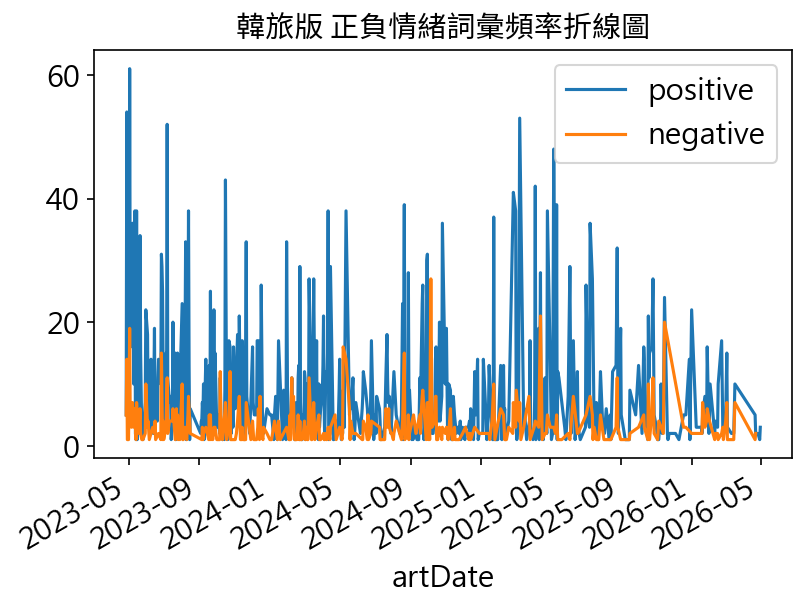

In [ ]:
colors = ["tab:blue", "tab:orange"]
pos_k = sentiment_count_k[sentiment_count_k["sentiments"] == "positive"]
neg_k = sentiment_count_k[sentiment_count_k["sentiments"] == "negative"]


fig, ax = plt.subplots()

ax.plot(pos_k["artDate"], pos_k["size"], color=colors[0])
ax.plot(neg_k["artDate"], neg_k["size"], color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("韓旅版 正負情緒詞彙頻率折線圖", fontproperties=fprop)  #
plt.show()

### 韓旅版 Rolling Average

使用滾動平均有助於平滑數據，使情緒趨勢更加清晰。
1. 去除瞬間噪聲： 情緒數據可能受到瞬間事件或噪聲的影響，例如突發的大量評論或新聞。滾動平均有助於平滑這些突變，使你更容易觀察到整體趨勢。
2. 強調長期趨勢： 滾動平均有助於強調長期情緒趨勢，而不受短期波動的干擾。這對於觀察情緒的漸變和長期變化非常有用。

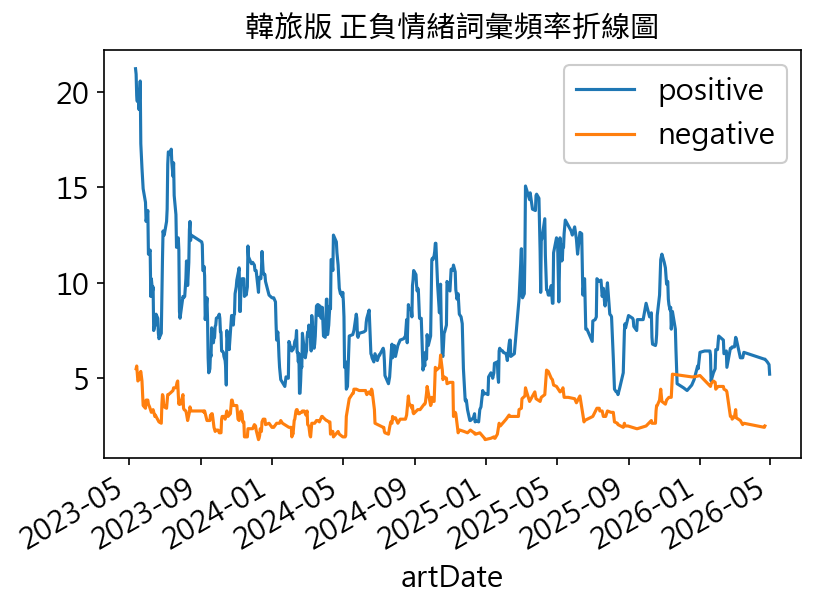

In [ ]:
colors = ["tab:blue", "tab:orange"]
pos_k = sentiment_count_k[sentiment_count_k["sentiments"] == "positive"]
neg_k = sentiment_count_k[sentiment_count_k["sentiments"] == "negative"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos_k["artDate"], pos_k['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg_k["artDate"], neg_k["size"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right", framealpha=1)
fig.autofmt_xdate()
plt.title("韓旅版 正負情緒詞彙頻率折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

## 3.4 正負向情緒詞彙比例折線圖

### 3.4.1 日旅版情緒詞彙

In [ ]:
sentiment_count_j = sentiment_count_j.assign(
    ratio=sentiment_count_j.groupby("artDate")["size"].transform(lambda n: n / n.sum())
)
sentiment_count_j.head(10)

,artDate,sentiments,size,ratio
2,2025-05-27,negative,1,0.111111
3,2025-05-27,positive,8,0.888889
8,2025-05-28,negative,11,0.224490
9,2025-05-28,positive,38,0.775510
13,2025-05-29,negative,18,0.257143
14,2025-05-29,positive,52,0.742857
18,2025-05-30,negative,7,0.179487
19,2025-05-30,positive,32,0.820513
23,2025-05-31,negative,9,0.209302
24,2025-05-31,positive,34,0.790698


In [ ]:
pos_j = sentiment_count_j[sentiment_count_j["sentiments"] == "positive"]
neg_j = sentiment_count_j[sentiment_count_j["sentiments"] == "negative"]

Text(0.5, 1.0, '日旅版 正負情緒比例折線圖')

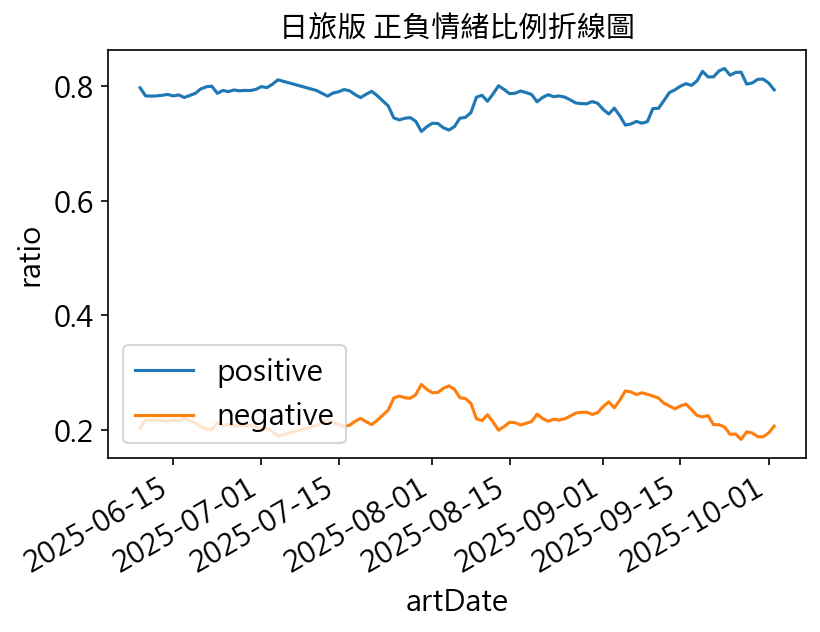

In [ ]:
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(pos_j["artDate"], pos_j["ratio"].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg_j["artDate"], neg_j["ratio"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
plt.ylabel("ratio")
ax.legend(["positive", "negative"], loc="lower left")
fig.autofmt_xdate()
plt.title("日旅版 正負情緒比例折線圖", fontproperties=fprop)

### 3.4.2 韓旅版情緒詞彙

In [ ]:
sentiment_count_k = sentiment_count_k.assign(
    ratio=sentiment_count_k.groupby("artDate")["size"].transform(lambda n: n / n.sum())
)
sentiment_count_k.head(10)

,artDate,sentiments,size,ratio
2,2023-04-27,negative,5,0.500000
3,2023-04-27,positive,5,0.500000
8,2023-04-28,negative,14,0.205882
9,2023-04-28,positive,54,0.794118
12,2023-04-29,negative,1,0.166667
13,2023-04-29,positive,5,0.833333
16,2023-04-30,negative,1,0.200000
17,2023-04-30,positive,4,0.800000
20,2023-05-01,negative,1,0.058824
21,2023-05-01,positive,16,0.941176


In [ ]:
pos_k = sentiment_count_k[sentiment_count_k["sentiments"] == "positive"]
neg_k = sentiment_count_k[sentiment_count_k["sentiments"] == "negative"]

Text(0.5, 1.0, '韓旅版 正負情緒比例折線圖')

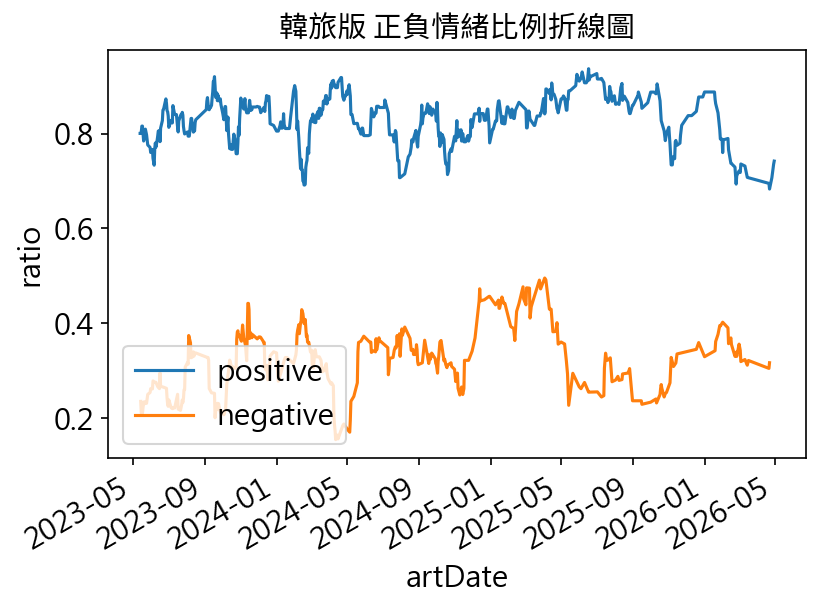

In [ ]:
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(pos_k["artDate"], pos_k["ratio"].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg_k["artDate"], neg_k["ratio"].rolling(rolling_days).mean(), color=colors[1])

plt.xlabel("artDate")
plt.ylabel("ratio")
ax.legend(["positive", "negative"], loc="lower left")
fig.autofmt_xdate()
plt.title("韓旅版 正負情緒比例折線圖", fontproperties=fprop)

## 3.5 正負向情緒分數折線圖

### 3.5.1 日旅版情緒分數

In [ ]:
sentiment_value_j = (
    sentiment_count_j.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
sentiment_value_j.head()

,artDate,negative,positive
0,2025-05-27,1.0,8.0
1,2025-05-28,11.0,38.0
2,2025-05-29,18.0,52.0
3,2025-05-30,7.0,32.0
4,2025-05-31,9.0,34.0


In [ ]:
# sentiment 計算方式: positive - negative
sentiment_value_j["sentiment_value"] = (
    sentiment_value_j["positive"]
    - sentiment_value_j["negative"]
)
sentiment_value_j.head()

,artDate,negative,positive,sentiment_value
0,2025-05-27,1.0,8.0,7.0
1,2025-05-28,11.0,38.0,27.0
2,2025-05-29,18.0,52.0,34.0
3,2025-05-30,7.0,32.0,25.0
4,2025-05-31,9.0,34.0,25.0


Text(0.5, 1.0, '日旅版 正負情緒分數趨勢折線圖')

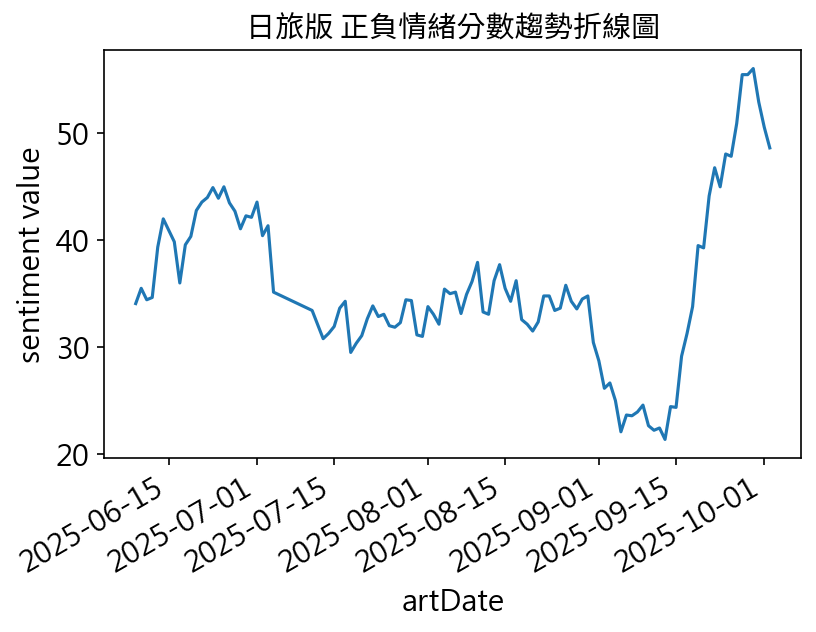

In [ ]:
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(sentiment_value_j["artDate"], sentiment_value_j["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("artDate")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("日旅版 正負情緒分數趨勢折線圖", fontproperties=fprop)

### 3.5.2 韓旅版情緒分數

In [ ]:
sentiment_value_k = (
    sentiment_count_k.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
sentiment_value_k.head()

,artDate,negative,positive
0,2023-04-27,5.0,5.0
1,2023-04-28,14.0,54.0
2,2023-04-29,1.0,5.0
3,2023-04-30,1.0,4.0
4,2023-05-01,1.0,16.0


In [ ]:
# sentiment 計算方式: positive - negative
sentiment_value_k["sentiment_value"] = (
    sentiment_value_k["positive"]
    - sentiment_value_k["negative"]
)
sentiment_value_k.head()

,artDate,negative,positive,sentiment_value
0,2023-04-27,5.0,5.0,0.0
1,2023-04-28,14.0,54.0,40.0
2,2023-04-29,1.0,5.0,4.0
3,2023-04-30,1.0,4.0,3.0
4,2023-05-01,1.0,16.0,15.0


Text(0.5, 1.0, '韓旅版 正負情緒分數趨勢折線圖')

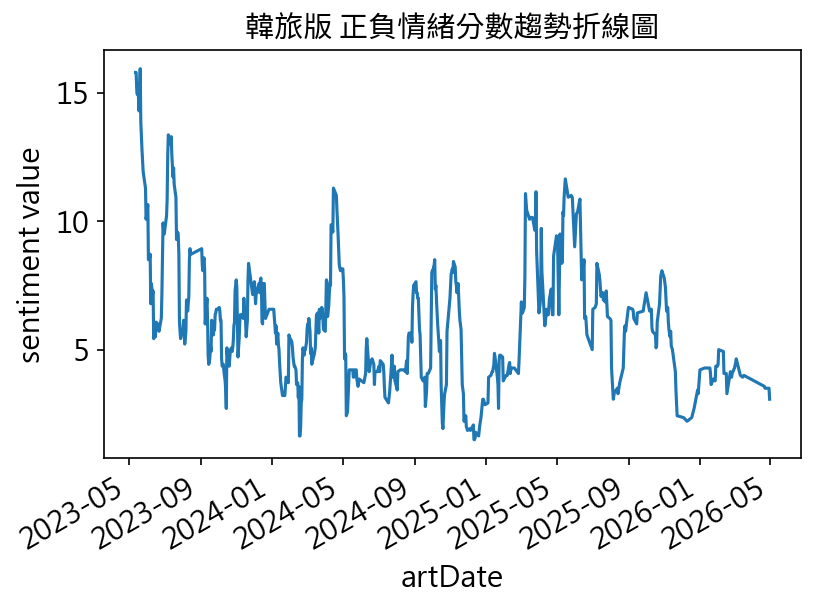

In [ ]:
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(sentiment_value_k["artDate"], sentiment_value_k["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("artDate")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("韓旅版 正負情緒分數趨勢折線圖", fontproperties=fprop)

## 3.6 文章為單位的情緒分析

### 3.6.1 日旅版情緒分析

In [ ]:
sentiment_count_by_article_j = pd.DataFrame(
    liwc_df_j.groupby(["artTitle", "artDate", "sentiments"]).size()
).reset_index()
sentiment_count_by_article_j = sentiment_count_by_article_j.rename(columns={0: "size"})
sentiment_count_by_article_j.head(10)

,artTitle,artDate,sentiments,size
0,10月北海道之旅請益（函館部分）,2025-06-23,affect,7
1,10月北海道之旅請益（函館部分）,2025-06-23,anger,1
2,10月北海道之旅請益（函館部分）,2025-06-23,negative,4
3,10月北海道之旅請益（函館部分）,2025-06-23,positive,3
4,10月底立山黑部/上高地行程請益,2025-08-01,affect,3
5,10月底立山黑部/上高地行程請益,2025-08-01,negative,1
6,10月底立山黑部/上高地行程請益,2025-08-01,positive,1
7,10月底立山黑部/上高地行程請益,2025-08-01,sad,1
8,Fw:[分享]中華航空CI222台北松山TSA→東京羽田HND,2025-06-14,affect,11
9,Fw:[分享]中華航空CI222台北松山TSA→東京羽田HND,2025-06-14,anger,1


In [ ]:
sentiment_value_by_article_j = (
    sentiment_count_by_article_j.pivot_table(
         index=["artTitle", "artDate"], columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
sentiment_value_by_article_j.head()

,artTitle,artDate,affect,anger,anx,negative,positive,sad
0,10月北海道之旅請益（函館部分）,2025-06-23,7.0,1.0,0.0,4.0,3.0,0.0
1,10月底立山黑部/上高地行程請益,2025-08-01,3.0,0.0,0.0,1.0,1.0,1.0
2,Fw:[分享]中華航空CI222台北松山TSA→東京羽田HND,2025-06-14,11.0,1.0,1.0,3.0,8.0,1.0
3,Fw:[心得]到東京健身房訓練健力吧！,2025-08-27,1.0,0.0,0.0,0.0,1.0,0.0
4,Fw:[食記]東京吉祥寺餛飩拉麵-餃子みんみん,2025-08-20,4.0,0.0,0.0,0.0,4.0,0.0


In [ ]:
# sentiment 計算方式: positive - negative
sentiment_value_by_article_j["sentiment_value"] = (
    sentiment_value_by_article_j["positive"]
    - sentiment_value_by_article_j["negative"]
)
sentiment_value_by_article_j.head()

,artTitle,artDate,affect,anger,anx,negative,positive,sad,sentiment_value
0,10月北海道之旅請益（函館部分）,2025-06-23,7.0,1.0,0.0,4.0,3.0,0.0,-1.0
1,10月底立山黑部/上高地行程請益,2025-08-01,3.0,0.0,0.0,1.0,1.0,1.0,0.0
2,Fw:[分享]中華航空CI222台北松山TSA→東京羽田HND,2025-06-14,11.0,1.0,1.0,3.0,8.0,1.0,5.0
3,Fw:[心得]到東京健身房訓練健力吧！,2025-08-27,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,Fw:[食記]東京吉祥寺餛飩拉麵-餃子みんみん,2025-08-20,4.0,0.0,0.0,0.0,4.0,0.0,4.0


In [ ]:
sentiment_value_by_article_j['sentiment_class'] = sentiment_value_by_article_j['sentiment_value'].apply(lambda x: "正向" if x > 0 else "負向" )
sentiment_value_by_article_j.head(10)

,artTitle,artDate,affect,anger,anx,negative,positive,sad,sentiment_value,sentiment_class
0,10月北海道之旅請益（函館部分）,2025-06-23,7.0,1.0,0.0,4.0,3.0,0.0,-1.0,負向
1,10月底立山黑部/上高地行程請益,2025-08-01,3.0,0.0,0.0,1.0,1.0,1.0,0.0,負向
2,Fw:[分享]中華航空CI222台北松山TSA→東京羽田HND,2025-06-14,11.0,1.0,1.0,3.0,8.0,1.0,5.0,正向
3,Fw:[心得]到東京健身房訓練健力吧！,2025-08-27,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
4,Fw:[食記]東京吉祥寺餛飩拉麵-餃子みんみん,2025-08-20,4.0,0.0,0.0,0.0,4.0,0.0,4.0,正向
5,Fw:[食記]東京滿滿蔥與香菜的河粉-PhoThinTokyo,2025-08-26,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
6,Fw:[食記]橫濱元祖油堂-日式乾拌拉麵,2025-09-25,7.0,0.0,0.0,1.0,6.0,0.0,5.0,正向
7,Fw:[食記]迴轉壽司活日本橫濱河豚白子及鮟鱇魚肝,2025-08-08,20.0,1.0,0.0,3.0,16.0,0.0,13.0,正向
8,Fw:[食記]龜正Kurukuru壽司日本大分在地漁獲壽司,2025-06-22,3.0,0.0,0.0,0.0,3.0,0.0,3.0,正向
9,GoTaxi6人座搭乘分享（名古屋）,2025-08-04,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向


In [ ]:
clear_df_sentiment_j = pd.merge(df_j, sentiment_value_by_article_j[['artTitle', 'artDate', 'sentiment_class']], how="left",  on=["artTitle", "artDate"])
clear_df_sentiment_j["artDate"] = pd.to_datetime(clear_df_sentiment_j["artDate"], errors='coerce')
clear_df_sentiment_j['artDate'] = clear_df_sentiment_j['artDate'].dt.date

clear_df_sentiment_j.head()

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource,country,sentiment_class
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025-05-27,pttbird,Japan_Travel,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""Hurubear"", ""...",61.220.191.67,2025/5/28 01:26,ptt,日本,NaN
1,2,https://www.ptt.cc/bbs/Japan_Travel/M.17483327...,[問題]高千穗一日遊疑問,2025-05-27,n61208,Japan_Travel,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""Dheroblood"",...",223.141.206.76,2025/5/28 01:26,ptt,日本,NaN
2,3,https://www.ptt.cc/bbs/Japan_Travel/M.17483552...,[問題]花火大會選擇（葛飾納涼/熱海/隅田川）,2025-05-27,angelstar,Japan_Travel,１． 出遊日期： 2025年7月下旬\n\n２． 行程：想參加花火大會（帶小孩）\n\n３．...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""leejones"", ""...",123.192.200.9,2025/5/28 01:26,ptt,日本,負向
3,4,https://www.ptt.cc/bbs/Japan_Travel/M.17483575...,Re:[問題]函館四天三夜&還可以去哪些城市/地方,2025-05-27,Vincient,Japan_Travel,晚安 我是原Po\n不好意思有些函館 交通的問題想請教\n\n因為查了一些文章 還是有些細節...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""akarilala"", ...",42.79.60.139,2025/5/28 01:26,ptt,日本,正向
4,5,https://www.ptt.cc/bbs/Japan_Travel/M.17483606...,[問題]東北楓葉推薦10月底還是11月初？,2025-05-27,fredliou,Japan_Travel,今年想規劃到東北賞楓葉(7天)\n預計從青森出發往南至仙台，大致如下：\nDay1-2 弘前...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""eric00169"", ...",111.83.64.100,2025/5/28 01:26,ptt,日本,正向


In [ ]:
# 對齊日期格式
df_j["artDate"] = pd.to_datetime(df_j["artDate"], errors='coerce').dt.date
sentiment_value_by_article_j["artDate"] = pd.to_datetime(sentiment_value_by_article_j["artDate"], errors='coerce').dt.date

sentiment_art_count_j = pd.DataFrame(
    clear_df_sentiment_j.groupby(["artDate", "sentiment_class"]).size()
).reset_index()
sentiment_art_count_j = sentiment_art_count_j.rename(columns={0: "size"})
sentiment_art_count_j = sentiment_art_count_j.sort_values(["artDate"])
sentiment_art_count_j

,artDate,sentiment_class,size
0,2025-05-27,正向,2
1,2025-05-27,負向,1
2,2025-05-28,正向,6
3,2025-05-29,正向,12
4,2025-05-29,負向,2
...,...,...,...
204,2025-09-30,負向,1
205,2025-10-01,正向,8
206,2025-10-01,負向,3
207,2025-10-02,正向,5


產生日旅版正負文章數趨勢折線圖

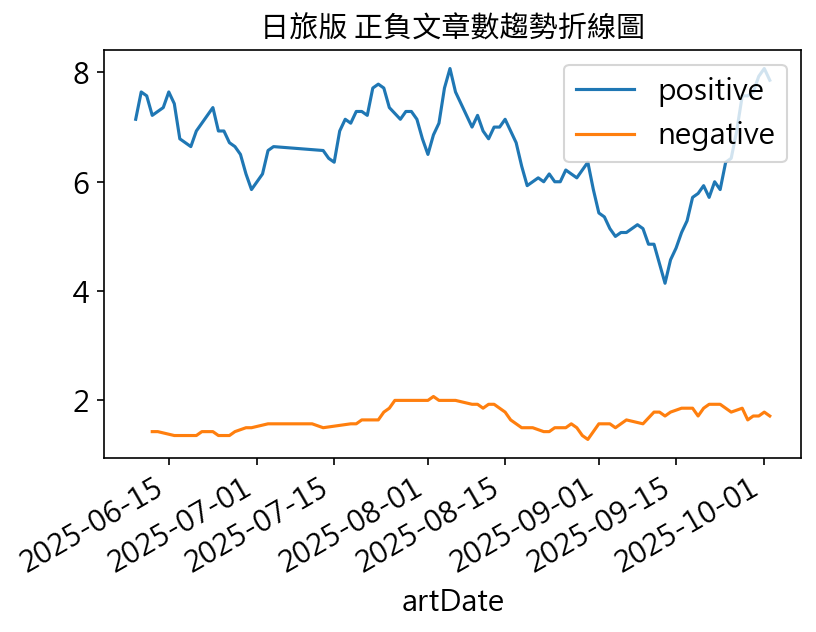

In [ ]:
colors = ["tab:blue", "tab:orange"]
pos_j = sentiment_art_count_j[sentiment_art_count_j["sentiment_class"] == "正向"]
neg_j = sentiment_art_count_j[sentiment_art_count_j["sentiment_class"] == "負向"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos_j["artDate"], pos_j['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg_j["artDate"], neg_j["size"].rolling(rolling_days).mean(), color=colors[1])
# ax.plot(pos["artDate"], pos['size'], color=colors[0])
# ax.plot(neg["artDate"], neg["size"], color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("日旅版 正負文章數趨勢折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

### 3.6.2 韓旅版情緒分析

In [ ]:
sentiment_count_by_article_k = pd.DataFrame(
    liwc_df_k.groupby(["artTitle", "artDate", "sentiments"]).size()
).reset_index()
sentiment_count_by_article_k = sentiment_count_by_article_k.rename(columns={0: "size"})
sentiment_count_by_article_k.head(10)

,artTitle,artDate,sentiments,size
0,0324、0329誠徵夜店夥伴（女性）,2024-03-19,affect,7
1,0324、0329誠徵夜店夥伴（女性）,2024-03-19,negative,1
2,0324、0329誠徵夜店夥伴（女性）,2024-03-19,positive,5
3,10月韓國行程請益,2023-09-25,affect,6
4,10月韓國行程請益,2023-09-25,positive,6
5,12/30-31食伴,2023-12-11,affect,2
6,12/30-31食伴,2023-12-11,anx,1
7,12/30-31食伴,2023-12-11,negative,2
8,2025韓國遊學推薦｜LEXISKorea弘大新校區,2025-10-10,affect,21
9,2025韓國遊學推薦｜LEXISKorea弘大新校區,2025-10-10,anx,4


In [ ]:
sentiment_value_by_article_k = (
    sentiment_count_by_article_k.pivot_table(
         index=["artTitle", "artDate"], columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
sentiment_value_by_article_k.head()

,artTitle,artDate,affect,anger,anx,negative,positive,sad
0,0324、0329誠徵夜店夥伴（女性）,2024-03-19,7.0,0.0,0.0,1.0,5.0,0.0
1,10月韓國行程請益,2023-09-25,6.0,0.0,0.0,0.0,6.0,0.0
2,12/30-31食伴,2023-12-11,2.0,0.0,1.0,2.0,0.0,0.0
3,2025韓國遊學推薦｜LEXISKorea弘大新校區,2025-10-10,21.0,0.0,4.0,5.0,14.0,0.0
4,"4/1-4/3,想找一天去DMZ非軍事區",2025-03-17,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# sentiment 計算方式: positive - negative
sentiment_value_by_article_k["sentiment_value"] = (
    sentiment_value_by_article_k["positive"]
    - sentiment_value_by_article_k["negative"]
)
sentiment_value_by_article_k.head()

,artTitle,artDate,affect,anger,anx,negative,positive,sad,sentiment_value
0,0324、0329誠徵夜店夥伴（女性）,2024-03-19,7.0,0.0,0.0,1.0,5.0,0.0,4.0
1,10月韓國行程請益,2023-09-25,6.0,0.0,0.0,0.0,6.0,0.0,6.0
2,12/30-31食伴,2023-12-11,2.0,0.0,1.0,2.0,0.0,0.0,-2.0
3,2025韓國遊學推薦｜LEXISKorea弘大新校區,2025-10-10,21.0,0.0,4.0,5.0,14.0,0.0,9.0
4,"4/1-4/3,想找一天去DMZ非軍事區",2025-03-17,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
sentiment_value_by_article_k['sentiment_class'] = sentiment_value_by_article_k['sentiment_value'].apply(lambda x: "正向" if x > 0 else "負向" )
sentiment_value_by_article_k.head(10)

,artTitle,artDate,affect,anger,anx,negative,positive,sad,sentiment_value,sentiment_class
0,0324、0329誠徵夜店夥伴（女性）,2024-03-19,7.0,0.0,0.0,1.0,5.0,0.0,4.0,正向
1,10月韓國行程請益,2023-09-25,6.0,0.0,0.0,0.0,6.0,0.0,6.0,正向
2,12/30-31食伴,2023-12-11,2.0,0.0,1.0,2.0,0.0,0.0,-2.0,負向
3,2025韓國遊學推薦｜LEXISKorea弘大新校區,2025-10-10,21.0,0.0,4.0,5.0,14.0,0.0,9.0,正向
4,"4/1-4/3,想找一天去DMZ非軍事區",2025-03-17,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
5,4/14首爾晚餐食伴,2025-04-01,1.0,0.0,0.0,0.0,1.0,0.0,1.0,正向
6,Fw:[分享]仁川機場Matina貴賓室-持JCB信用卡免費進,2026-04-21,5.0,0.0,0.0,1.0,5.0,0.0,4.0,正向
7,Fw:[分享]大韓航空-首爾仁川機場2航商務貴賓室,2023-08-03,4.0,0.0,0.0,0.0,4.0,0.0,4.0,正向
8,Fw:[分享]大韓航空KE186TPE-ICNB747-8i商務艙,2023-07-23,20.0,0.0,1.0,6.0,13.0,1.0,7.0,正向
9,Fw:[分享]濟州島2023-May自駕,2023-05-30,9.0,0.0,1.0,2.0,7.0,0.0,5.0,正向


In [ ]:
clear_df_sentiment_k = pd.merge(df_k, sentiment_value_by_article_k[['artTitle', 'artDate', 'sentiment_class']], how="left",  on=["artTitle", "artDate"])
clear_df_sentiment_k["artDate"] = pd.to_datetime(clear_df_sentiment_k["artDate"], errors='coerce')
clear_df_sentiment_k['artDate'] = clear_df_sentiment_k['artDate'].dt.date

clear_df_sentiment_k.head()

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource,country,sentiment_class
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023-04-27,Aaron22,Korea_Travel,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""lakai199"", ""...",49.216.53.202,2023/4/28 01:50,ptt,韓國,負向
1,2,https://www.ptt.cc/bbs/Korea_Travel/M.16825675...,[問題]睡機場或其他,2023-04-27,massaget,Korea_Travel,各位大大好，小弟即將在下個月前往韓國\n由於虎航的的班機表定是01:30到仁川機場，一航的過...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""dbdudsorj"", ...",118.163.134.243,2023/4/28 01:50,ptt,韓國,正向
2,3,https://www.ptt.cc/bbs/Korea_Travel/M.16826436...,[遊記]首爾｜6天5夜自由行。景點美食與城市體驗,2023-04-28,abc9442,Korea_Travel,圖文網誌建議閱讀版：\nhttps://listentolu.com/2023/04/seo...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""richuncle97""...",101.12.49.111,2023/4/30 01:54,ptt,韓國,正向
3,4,https://www.ptt.cc/bbs/Korea_Travel/M.16826572...,[問題]請問金浦機場幾個問題,2023-04-28,rufus,Korea_Travel,1. 住宿的地點在東大門歷史文化公園站\n用subway app查詢從金浦機場過去有兩種方式...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""dbdudsorj"", ...",60.251.58.169,2023/4/30 01:54,ptt,韓國,NaN
4,5,https://www.ptt.cc/bbs/Korea_Travel/M.16827752...,[住宿]首爾乙支路高爺商業公寓樓下機場巴士,2023-04-29,jay70134,Korea_Travel,"住宿名稱：乙支路高爺商業公寓\n 入住時間：112年3月\n 住宿地址：246, E...","[{""cmtStatus"": ""推"", ""cmtPoster"": ""chiacuro"", ""...",180.217.35.114,2023/4/30 01:54,ptt,韓國,正向


In [ ]:
# 對齊日期格式
df_k["artDate"] = pd.to_datetime(df_k["artDate"], errors='coerce').dt.date
sentiment_value_by_article_k["artDate"] = pd.to_datetime(sentiment_value_by_article_k["artDate"], errors='coerce').dt.date

sentiment_art_count_k = pd.DataFrame(
    clear_df_sentiment_k.groupby(["artDate", "sentiment_class"]).size()
).reset_index()
sentiment_art_count_k = sentiment_art_count_k.rename(columns={0: "size"})
sentiment_art_count_k = sentiment_art_count_k.sort_values(["artDate"])
sentiment_art_count_k

,artDate,sentiment_class,size
0,2023-04-27,正向,1
1,2023-04-27,負向,1
2,2023-04-28,正向,1
3,2023-04-29,正向,1
4,2023-04-30,正向,1
...,...,...,...
631,2026-04-21,正向,1
632,2026-04-22,負向,1
633,2026-04-26,正向,1
634,2026-04-29,正向,1


產生韓旅版正負文章數趨勢折線圖

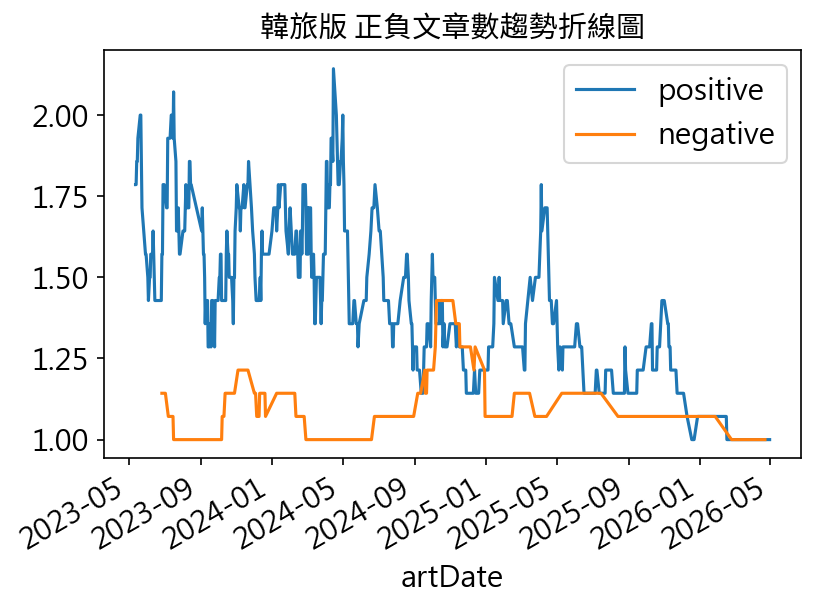

In [ ]:
colors = ["tab:blue", "tab:orange"]
pos_k = sentiment_art_count_k[sentiment_art_count_k["sentiment_class"] == "正向"]
neg_k = sentiment_art_count_k[sentiment_art_count_k["sentiment_class"] == "負向"]

# fig, ax = plt.subplots(figsize = (6,4), dpi = 150) # 也可以在該圖設定參數
fig, ax = plt.subplots()

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14
ax.plot(pos_k["artDate"], pos_k['size'].rolling(rolling_days).mean(), color=colors[0])
ax.plot(neg_k["artDate"], neg_k["size"].rolling(rolling_days).mean(), color=colors[1])
# ax.plot(pos["artDate"], pos['size'], color=colors[0])
# ax.plot(neg["artDate"], neg["size"], color=colors[1])

plt.xlabel("artDate")
# plt.ylabel('size')
ax.legend(["positive", "negative"], loc="upper right")
fig.autofmt_xdate()
plt.title("韓旅版 正負文章數趨勢折線圖", fontproperties=fprop)  # 記得加上才能顯示中文
plt.show()

## 3.7 情緒代表字

### 3.7.1 日旅版情緒代表字

In [ ]:
word_count_j = liwc_df_j.groupby(["word", "sentiments"]).size().reset_index()
word_count_j = word_count_j.rename(columns={0: "size"})
word_count_j = word_count_j.sort_values(["size"], ascending=False)

word_count_j.head(10)

,word,sentiments,size
400,好吃,positive,277
399,好吃,affect,277
506,希望,positive,269
505,希望,affect,269
654,感謝,affect,223
655,感謝,positive,223
1507,適合,affect,196
1508,適合,positive,196
967,決定,affect,185
968,決定,positive,185


### 分別找出正向負向情緒代表字

In [ ]:
# 正向
word_of_pos_j = word_count_j.loc[(word_count_j["sentiments"] == "positive")]
word_of_pos_j.head(15)

,word,sentiments,size
400,好吃,positive,277
506,希望,positive,269
655,感謝,positive,223
1508,適合,positive,196
968,決定,positive,185
156,免費,positive,166
1248,簡單,positive,160
116,值得,positive,126
1210,確定,positive,112
1362,舒服,positive,112


In [ ]:
# 負向
word_of_neg_j = word_count_j.loc[(word_count_j["sentiments"] == "negative")]
word_of_neg_j.head(15)

,word,sentiments,size
800,擔心,negative,91
1660,麻煩,negative,82
825,放棄,negative,59
1531,錯過,negative,53
1300,缺點,negative,52
1564,隨便,negative,49
74,事故,negative,35
1107,猶豫,negative,33
1518,遺憾,negative,29
1219,禁止,negative,28


### 日旅版正負向情緒文字統計

C:\Users\orika\AppData\Local\Temp\ipykernel_400\1292093554.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos_j["word"], fontproperties=fprop)
C:\Users\orika\AppData\Local\Temp\ipykernel_400\1292093554.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg_j["word"], fontproperties=fprop)


Text(0.5, 1.0, '日旅版 負向情緒總數')

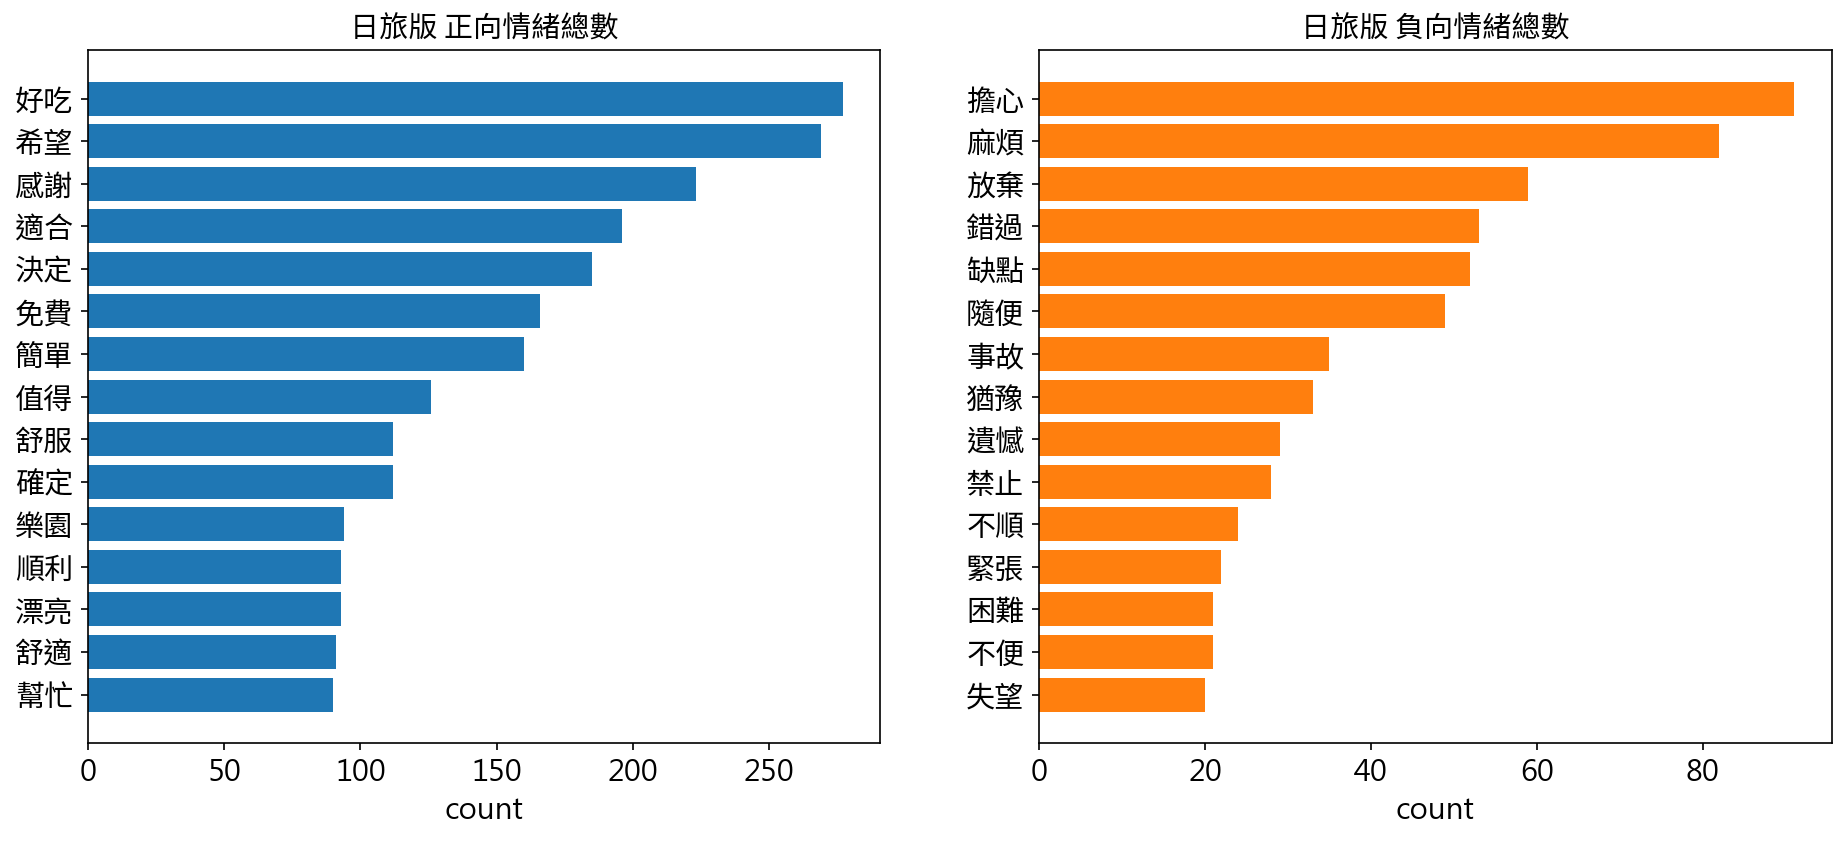

In [ ]:
pos_j = word_of_pos_j.head(15).sort_values(["size"], ascending=True)
neg_j = word_of_neg_j.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].barh(pos_j["word"], pos_j["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos_j["word"], fontproperties=fprop)
ax[0].set_title("日旅版 正向情緒總數", fontproperties=fprop)

ax[1].barh(neg_j["word"], neg_j["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg_j["word"], fontproperties=fprop)
ax[1].set_title("日旅版 負向情緒總數", fontproperties=fprop)

### 3.7.2 韓旅版情緒代表字

In [ ]:
word_count_k = liwc_df_k.groupby(["word", "sentiments"]).size().reset_index()
word_count_k = word_count_k.rename(columns={0: "size"})
word_count_k = word_count_k.sort_values(["size"], ascending=False)

word_count_k.head(10)

,word,sentiments,size
771,樂天,affect,300
772,樂天,positive,300
353,好吃,affect,211
354,好吃,positive,211
431,希望,affect,185
432,希望,positive,185
789,歡迎,affect,155
790,歡迎,positive,155
1295,適合,affect,153
1296,適合,positive,153


### 分別找出正向負向情緒代表字

In [ ]:
# 正向
word_of_pos_k = word_count_k.loc[(word_count_j["sentiments"] == "positive")]
word_of_pos_k.head(15)

,word,sentiments,size
432,希望,positive,185
151,免費,positive,136
436,幫忙,positive,117
104,值得,affect,86
1022,確定,positive,80
235,可愛,affect,66
686,擔心,affect,64
859,漂亮,affect,52
1309,重要,affect,44
400,容易,affect,40


In [ ]:
# 負向
word_of_neg_k = word_count_k.loc[(word_count_j["sentiments"] == "negative")]
word_of_neg_k.head(15)

,word,sentiments,size
771,樂天,affect,300
1295,適合,affect,153
1143,興趣,affect,88
1021,確定,affect,80
768,樂園,positive,78
1414,麻煩,affect,77
1148,舒適,positive,69
1145,舒服,affect,68
74,享受,positive,58
64,乾淨,affect,56


### 韓旅版 正負向情緒文字統計

C:\Users\orika\AppData\Local\Temp\ipykernel_400\2390488641.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos_k["word"], fontproperties=fprop)
C:\Users\orika\AppData\Local\Temp\ipykernel_400\2390488641.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg_k["word"], fontproperties=fprop)


Text(0.5, 1.0, '韓旅版 負向情緒總數')

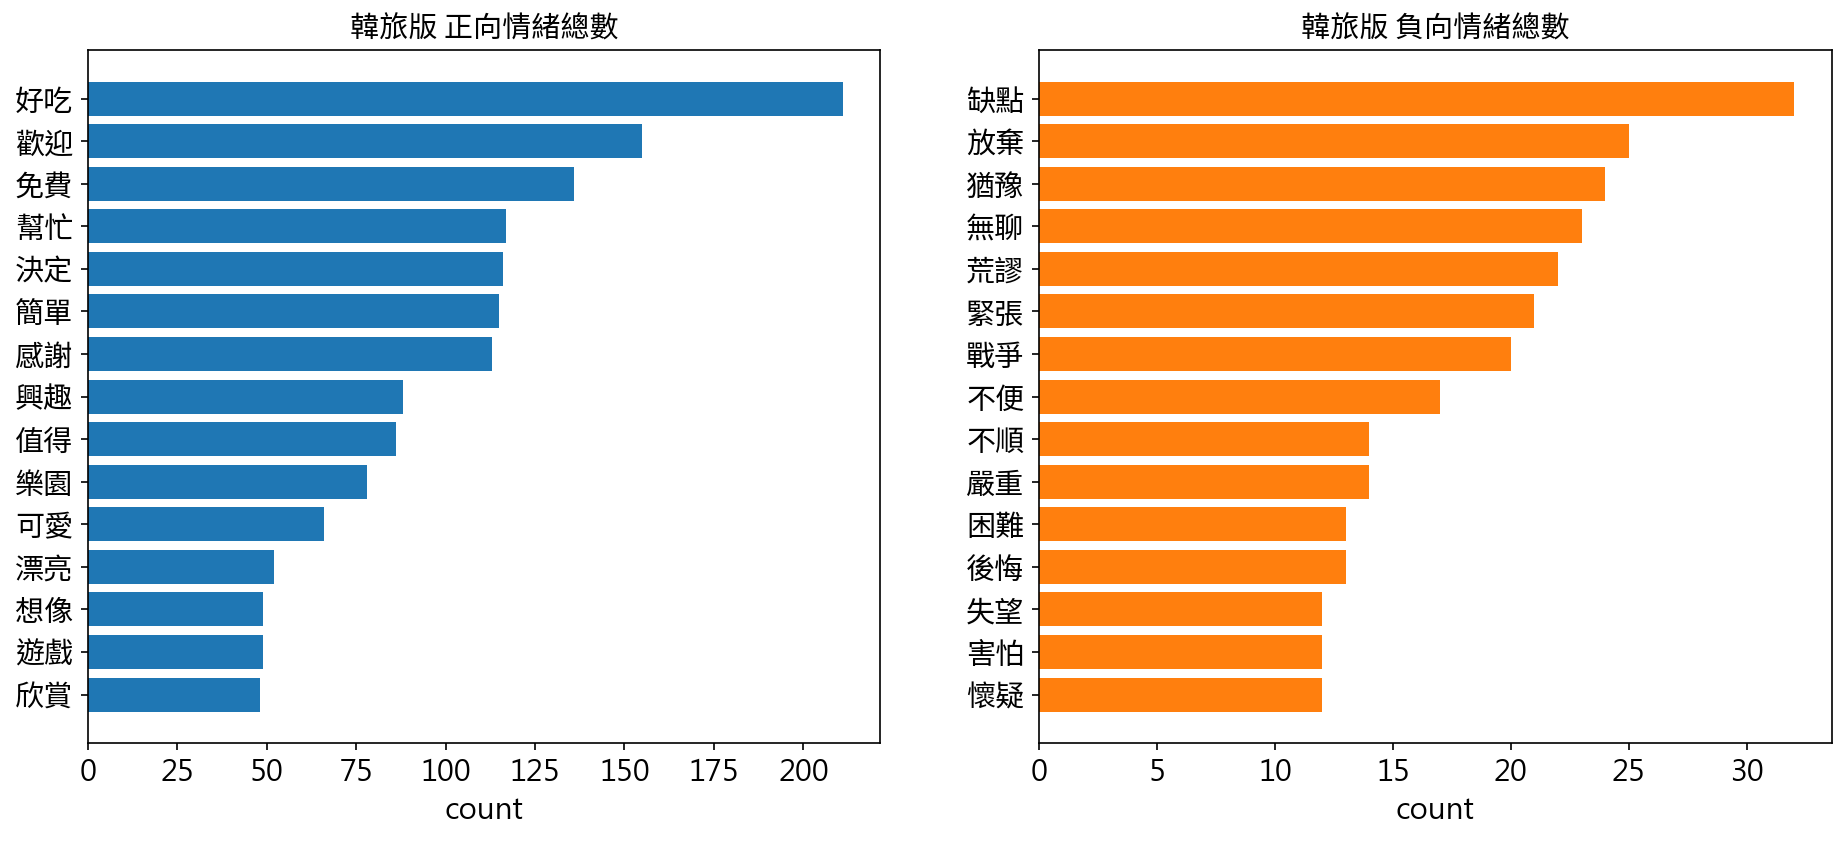

In [ ]:
pos_k = word_of_pos_k.head(15).sort_values(["size"], ascending=True)
neg_k = word_of_neg_k.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].barh(pos_k["word"], pos_k["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos_k["word"], fontproperties=fprop)
ax[0].set_title("韓旅版 正向情緒總數", fontproperties=fprop)

ax[1].barh(neg_k["word"], neg_k["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg_k["word"], fontproperties=fprop)
ax[1].set_title("韓旅版 負向情緒總數", fontproperties=fprop)

## 3.8 重新計算日韓旅版情緒

### 3.8.1 日旅版字詞移除重新計算情緒

In [ ]:
# 設定要移除的字詞列表
words_to_remove_j = ['問題', '希望', '錯過', '隨便', '擔心', '控制', '壓力', '強烈', '負擔', '挑剔', '不好意思', '邪惡', '禁止', '麻煩', '猶豫', '放棄', '猶豫', '廢話', '驚人', '單獨']
# 使用 ~ 運算子和 isin() 方法過濾掉包含在 words_to_remove 列表中的行
liwc_dict_revise_j = liwc_dict[~liwc_dict['word'].isin(words_to_remove_j)]
# 使用更新後的情緒字典 merge
liwc_df_revise_j = pd.merge(noStop_df_j[["artTitle", "artDate", "artContent", "country", "word"]], liwc_dict_revise_j, how="left", on="word")
liwc_df_revise_j.head()

,artTitle,artDate,artContent,country,word,sentiments
0,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,之於,NaN
1,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,回饋,NaN
2,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,研究,NaN
3,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,一輪,NaN
4,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,神戶,NaN


C:\Users\orika\AppData\Local\Temp\ipykernel_400\3737225658.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos_j["word"], fontproperties=fprop)
C:\Users\orika\AppData\Local\Temp\ipykernel_400\3737225658.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg_j["word"], fontproperties=fprop)


Text(0.5, 1.0, '日旅版 負向情緒總數')

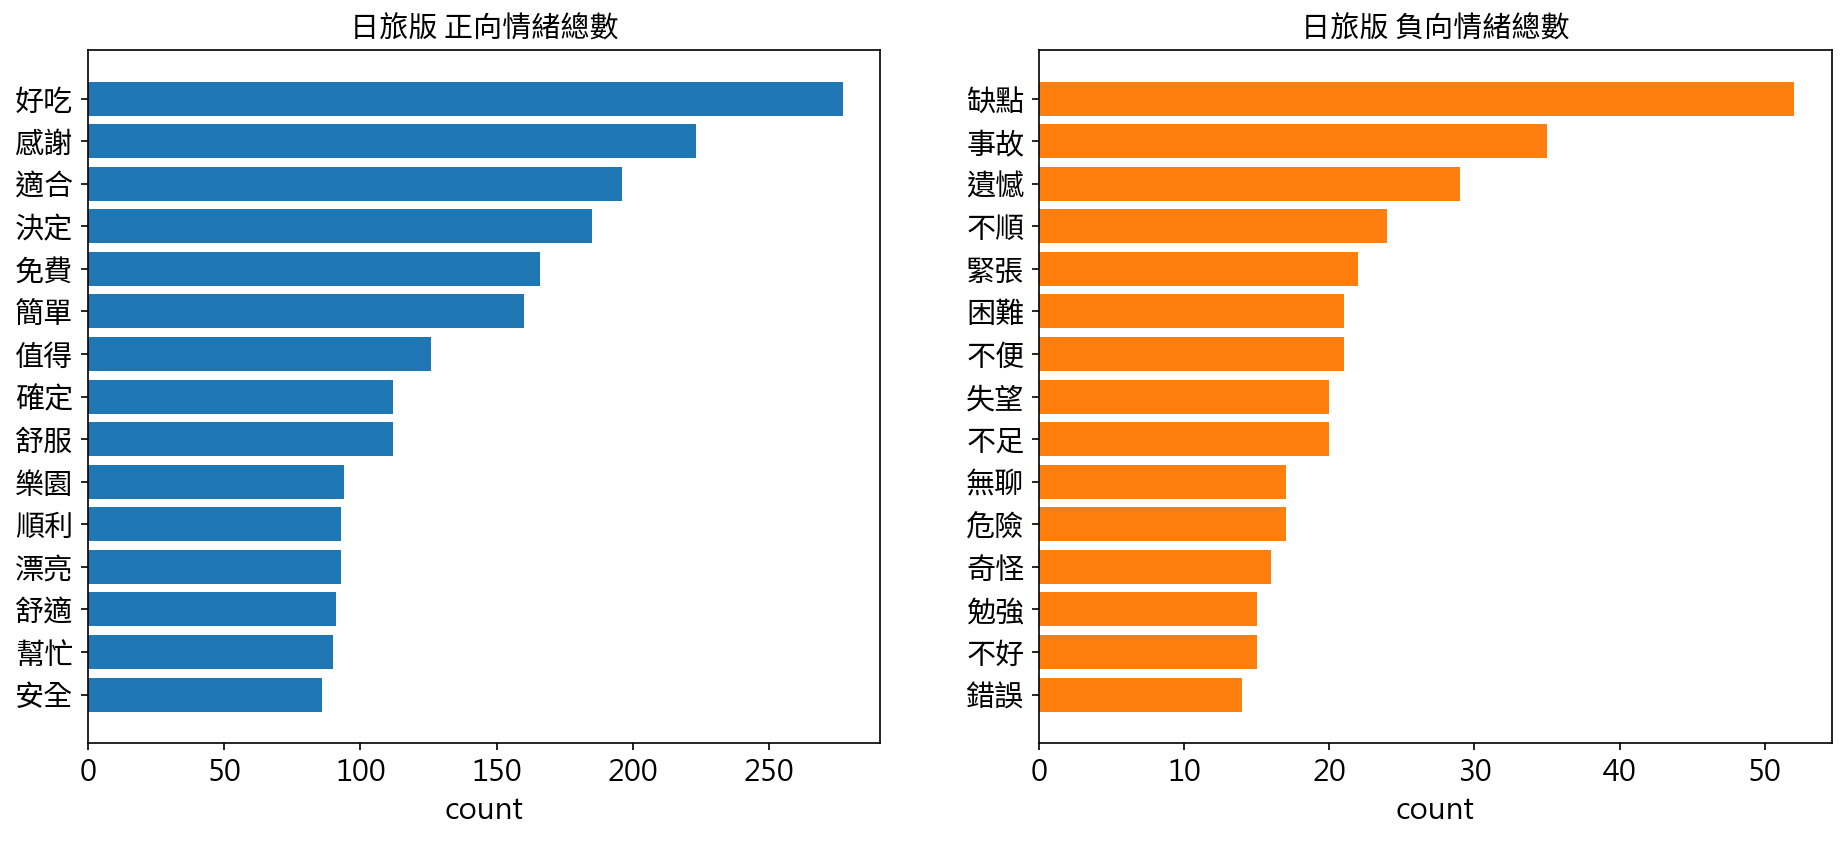

In [ ]:
word_count_j = liwc_df_revise_j.groupby(["word", "sentiments"]).size().reset_index()

word_count_j = word_count_j.rename(columns={0: "size"})
word_count_j = word_count_j.sort_values(["size"], ascending=False)

word_of_pos_j = word_count_j.loc[(word_count_j["sentiments"] == "positive")]
word_of_neg_j = word_count_j.loc[(word_count_j["sentiments"] == "negative")]

pos_j = word_of_pos_j.head(15).sort_values(["size"], ascending=True)
neg_j = word_of_neg_j.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].barh(pos_j["word"], pos_j["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos_j["word"], fontproperties=fprop)
ax[0].set_title("日旅版 正向情緒總數", fontproperties=fprop)

ax[1].barh(neg_j["word"], neg_j["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg_j["word"], fontproperties=fprop)
ax[1].set_title("日旅版 負向情緒總數", fontproperties=fprop)

### 重新繪製日旅版情緒分數趨勢圖

Text(0.5, 1.0, '日旅版 正負情緒分數趨勢折線圖')

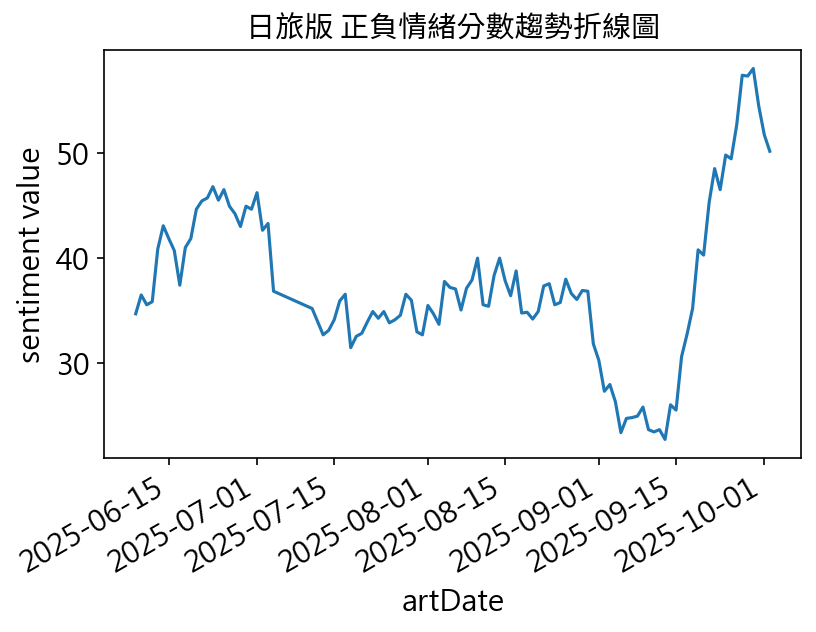

In [ ]:
liwc_df_revise_j["artDate"] = pd.to_datetime(liwc_df_revise_j["artDate"]).dt.date

sentiment_count_revise_j = pd.DataFrame(
    liwc_df_revise_j.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask_j = (sentiment_count_revise_j['sentiments'] == "positive") | (sentiment_count_revise_j['sentiments'] == "negative")
sentiment_count_revise_j = sentiment_count_revise_j.loc[mask_j]

sentiment_count_revise_j = sentiment_count_revise_j.rename(columns={0: "size"})
sentiment_count_revise_j = sentiment_count_revise_j.sort_values(["artDate"])

sentiment_value_revise_j = (
    sentiment_count_revise_j.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

# sentiment 計算方式: positive - negative
sentiment_value_revise_j["sentiment_value"] = (
    sentiment_value_revise_j["positive"]
    - sentiment_value_revise_j["negative"]
)

# 繪製情緒分數趨勢圖
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(sentiment_value_revise_j["artDate"], sentiment_value_revise_j["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("artDate")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("日旅版 正負情緒分數趨勢折線圖", fontproperties=fprop)

### 3.8.2 韓旅版字詞移除重新計算情緒

In [ ]:
# 設定要移除的字詞列表
words_to_remove_k = ['問題', '希望', '錯過', '隨便', '擔心', '控制', '壓力', '強烈', '負擔', '挑剔', '不好意思', '邪惡', '禁止', '麻煩', '樂天', '確定', '重要',
                     '享受', '和平']
# 使用 ~ 運算子和 isin() 方法過濾掉包含在 words_to_remove 列表中的行
liwc_dict_revise_k = liwc_dict[~liwc_dict['word'].isin(words_to_remove_k)]
# 使用更新後的情緒字典 merge
liwc_df_revise_k = pd.merge(noStop_df_k[["artTitle", "artDate", "artContent", "country", "word"]], liwc_dict_revise_k, how="left", on="word")
liwc_df_revise_k.head()

,artTitle,artDate,artContent,country,word,sentiments
0,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月,NaN
1,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,初去,NaN
2,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,首爾,NaN
3,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,旅途,NaN
4,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,一晚,NaN


C:\Users\orika\AppData\Local\Temp\ipykernel_400\1568917593.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(pos_k["word"], fontproperties=fprop)
C:\Users\orika\AppData\Local\Temp\ipykernel_400\1568917593.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(neg_k["word"], fontproperties=fprop)


Text(0.5, 1.0, '韓旅版 負向情緒總數')

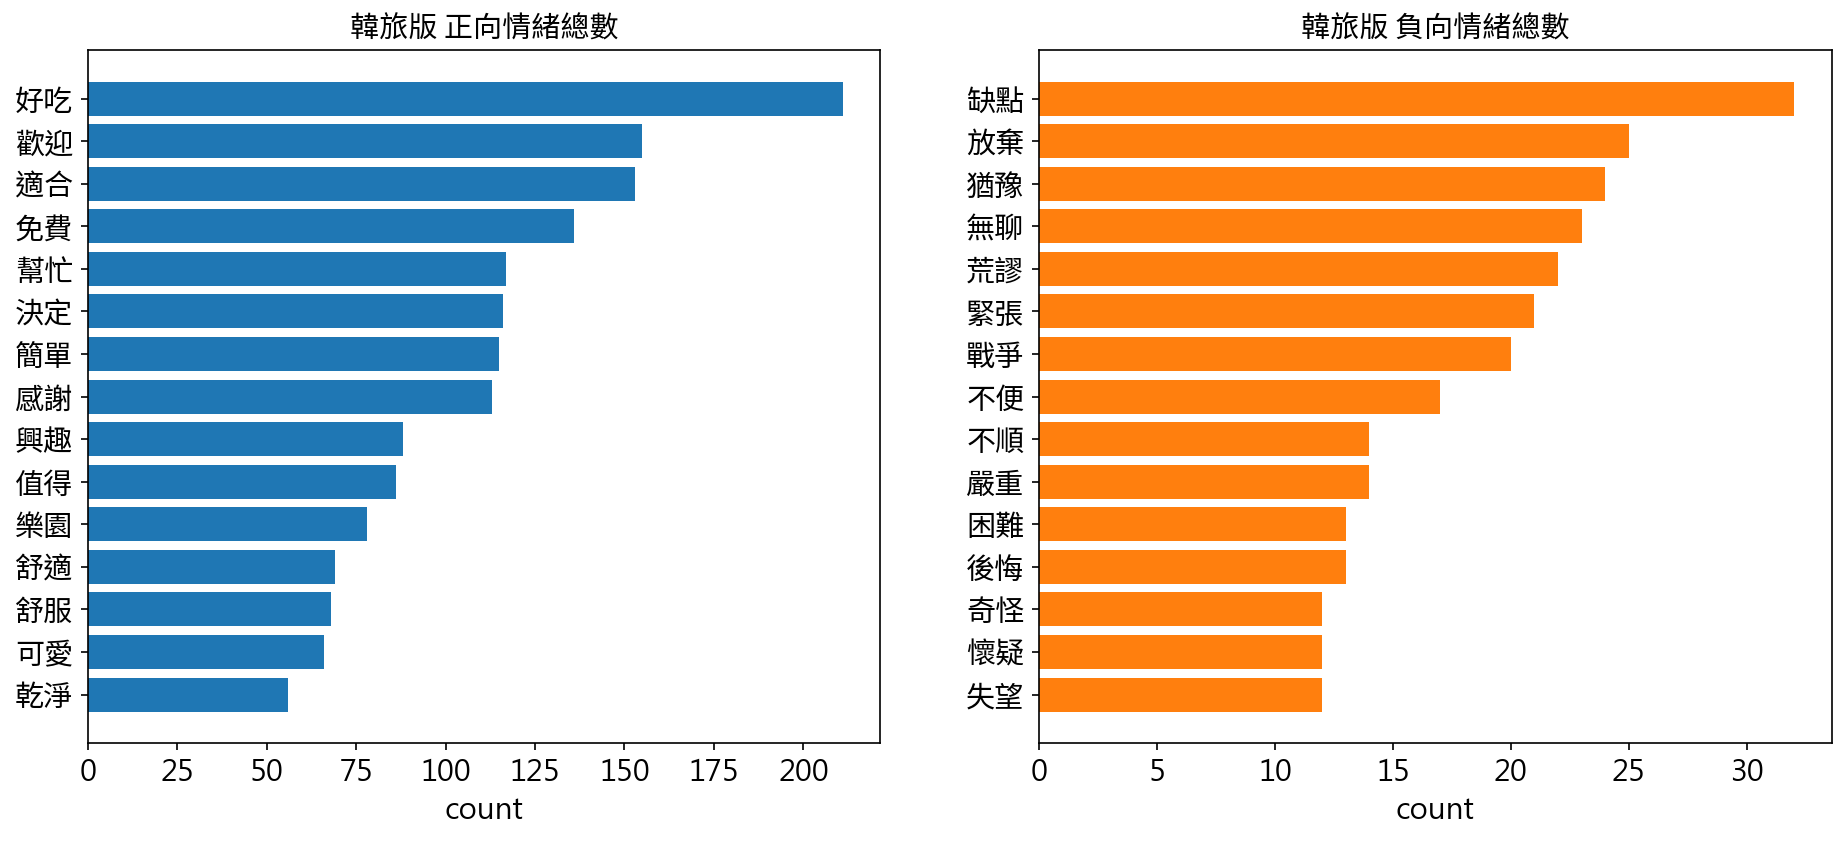

In [ ]:
word_count_k = liwc_df_revise_k.groupby(["word", "sentiments"]).size().reset_index()

word_count_k = word_count_k.rename(columns={0: "size"})
word_count_k = word_count_k.sort_values(["size"], ascending=False)

word_of_pos_k = word_count_k.loc[(word_count_k["sentiments"] == "positive")]
word_of_neg_k = word_count_k.loc[(word_count_k["sentiments"] == "negative")]

pos_k = word_of_pos_k.head(15).sort_values(["size"], ascending=True)
neg_k = word_of_neg_k.head(15).sort_values(["size"], ascending=True)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].barh(pos_k["word"], pos_k["size"], color=colors[0])
ax[0].set_xlabel("count")
ax[0].set_yticklabels(pos_k["word"], fontproperties=fprop)
ax[0].set_title("韓旅版 正向情緒總數", fontproperties=fprop)

ax[1].barh(neg_k["word"], neg_k["size"], color=colors[1])
ax[1].set_xlabel("count")
ax[1].set_yticklabels(neg_k["word"], fontproperties=fprop)
ax[1].set_title("韓旅版 負向情緒總數", fontproperties=fprop)

### 重新繪製韓旅版情緒分數趨勢圖

Text(0.5, 1.0, '韓旅版 正負情緒分數趨勢折線圖')

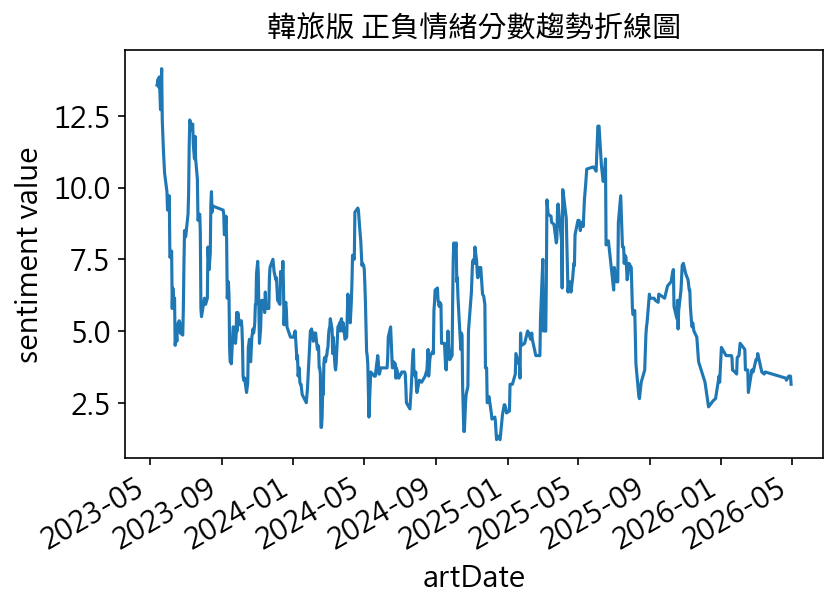

In [ ]:
liwc_df_revise_k["artDate"] = pd.to_datetime(liwc_df_revise_k["artDate"]).dt.date

sentiment_count_revise_k = pd.DataFrame(
    liwc_df_revise_k.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask_k = (sentiment_count_revise_k['sentiments'] == "positive") | (sentiment_count_revise_k['sentiments'] == "negative")
sentiment_count_revise_k = sentiment_count_revise_k.loc[mask_k]

sentiment_count_revise_k = sentiment_count_revise_k.rename(columns={0: "size"})
sentiment_count_revise_k = sentiment_count_revise_k.sort_values(["artDate"])

sentiment_value_revise_k = (
    sentiment_count_revise_k.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

# sentiment 計算方式: positive - negative
sentiment_value_revise_k["sentiment_value"] = (
    sentiment_value_revise_k["positive"]
    - sentiment_value_revise_k["negative"]
)

# 繪製情緒分數趨勢圖
fig, ax = plt.subplots()

rolling_days = 14
ax.plot(sentiment_value_revise_k["artDate"], sentiment_value_revise_k["sentiment_value"].rolling(rolling_days).mean())
ax.set_xlabel("artDate")
ax.set_ylabel("sentiment value")
fig.autofmt_xdate()
plt.title("韓旅版 正負情緒分數趨勢折線圖", fontproperties=fprop)

## 4. CKIP 詞性標記

In [ ]:
from ckiptagger import data_utils, construct_dictionary, WS, POS, NER
import time

In [ ]:
# 下載 ckip model
data_utils.download_data_gdown("./")

Downloading...
From (original): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771
From (redirected): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771&confirm=t&uuid=8dc4b074-1a62-4dde-b5ca-abd41eddf06f
To: c:\Users\nini\Desktop\NSYSU\1142\MIS581\socialmdeia_final\socialmdeia_final\data.zip
100%|██████████| 1.88G/1.88G [06:11<00:00, 5.05MB/s]


In [ ]:
# 將三份工具的模型路徑指向我們剛才下載的檔案「data」
ws = WS("./data")
pos = POS("./data")
ner = NER("./data")

c:\Users\nini\AppData\Local\Programs\Python\Python311\Lib\site-packages\ckiptagger\model_ws.py:106: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
c:\Users\nini\AppData\Local\Programs\Python\Python311\Lib\site-packages\ckiptagger\model_pos.py:56: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
c:\Users\nini\AppData\Local\Programs\Python\Python311\Lib\site-packages\ckiptagger\model_ner.py:57: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by th

In [ ]:
# 定義文字清理的相關 function
def Segmentation_Core(data, tokenizer):
    # 將所有的斷行字元配上 escape 以防失效
    regexPattern = '|'.join(map(re.escape, tokenizer))
    output_list = re.split(regexPattern, data)
    # 過濾空白行
    output_list = list(filter(None, output_list))
    return output_list

def Sentence_Segmentation(article, keep_digits=False, keep_alphabets=False):
    """ Sentence_Segmentation function 用於執行中文斷行任務

    順序如下：
    1. 去除(\\n)
    2. 去除特殊符號字元
    3. 保留數字
    4. 依照斷句字元進行斷句全形的分號、逗號、句號、問號以及驚嘆號
    5. 避免空白斷句結果

    Args:
        article(string): 欲斷行之文章內容
        keep_digits(Boolean): 決定是否保留數字於斷行後的結果
        keep_alphabets(Boolean): 決定是否保留字母於斷行後的結果
    Returns:
        List [] 每個 element 就是一行
    """
    sepical_symbols = r'[.＂<>:《》+\-=#$%&()*@＃＄％＆＇\(\)\[\]\{\}（）＊＋－／：\
    ＜＝＞＠［＼］＾＿｀｛｜｝～｟｠｢｣､、〃》「」『』【】〔〕〖〗〘〙〚〛〜〝〞〟〰〾〿–—一‘’‛“”„‟…‧﹏★→─]+'
    segmentation_used_note = (";", "；", "！", "!", "？", "?", "。")


    paragraphs = list(filter(lambda x: re.sub(r'\s+','', x), article.split("\n")))
    # print(len(paragraphs))
    # print(paragraphs)

    result = []
    for paragraph in paragraphs:

        clean_paragraph = paragraph
        try:
            if not keep_digits:
                clean_paragraph = re.sub(r'\d*\.?\d+','', clean_paragraph) #remove space & digits
            if not keep_alphabets:
                clean_paragraph = re.sub('[a-zA-Z]+', '', clean_paragraph)

            clean_paragraph = re.sub(r'[\s]+','', clean_paragraph) #remove space

            clean_paragraph = re.sub(sepical_symbols,'',clean_paragraph)

        except:
            return "error"

        res = Segmentation_Core(clean_paragraph, segmentation_used_note)
        result.append(res)

    return result

In [ ]:
# 自定義辭典
with open('dict/user_dict.txt') as f:
    lines = f.read().splitlines()

dict = {k.split()[0]: k.split()[1] for v, k in enumerate(lines)}
dictionary2 = construct_dictionary(dict)


In [ ]:
def get_pos(post_id, word_sentence, pos_sentence):
    tokens = []
    # print("\nPOS: ", end="\u3000")
    assert len(word_sentence) == len(pos_sentence)
    for word, pos in zip(word_sentence, pos_sentence): # token level
        tokens.append([post_id, word, pos])
    # print(f"{word}({pos})", end="\u3000")
    return tokens

def get_ner(post_id, entity_sentence):
    entities = []
    # print("\nNER:___________ ")
    for entity in sorted(entity_sentence): # token level
        entities.append([post_id, entity[3], entity[2]])
    return entities

def get_nlp_result(data_df):
    start = time.time()

    pos_list = []
    entity_list = []
    sentence_list = []

    # 遍歷 dataframe 的每筆資料
    for index, row in data_df.iterrows():

        # 資料清理 ＆ 斷句
        tmp = Sentence_Segmentation(row['artContent'])
        flat_list = [item for sublist in tmp for item in sublist]

        # ckip
        word_sentence_list = ws(flat_list, coerce_dictionary = dictionary2)
        pos_sentence_list = pos(word_sentence_list)
        entity_sentence_list = ner(word_sentence_list, pos_sentence_list)

        post_id = row['system_id'] if 'system_id' in data_df.columns else index

        # 遍歷該 document 中的每一個句子
        for i, sentence in enumerate(flat_list):
            # print(f"sentence {i}: {sentence}")
            sentence_list.append([post_id, sentence])
            temp_tokens = get_pos(post_id, word_sentence_list[i], pos_sentence_list[i])
            temp_entites = get_ner(post_id, entity_sentence_list[i])

            pos_list.append(temp_tokens)
            if len(temp_entites) != 0:
                entity_list.append(temp_entites)

    pos_flat = [item for sublist in pos_list for item in sublist]
    entity_flat = [item for sublist in entity_list for item in sublist]

    pos_table = pd.DataFrame(data=pos_flat,
                    columns=['system_id','word','pos'])

    entity_table = pd.DataFrame(data=entity_flat,
                        columns=['system_id','word','ner'])

    sentence_table = pd.DataFrame(data=sentence_list,
                    columns=['system_id','sentence'])

    end = time.time()
    print("time costing: {}".format(end - start))

    return pos_table, entity_table, sentence_table

In [ ]:
pos_table_j, entity_table_j, sentence_table_j = get_nlp_result(clear_df_j)
pos_table_k, entity_table_k, sentence_table_k = get_nlp_result(clear_df_k)

time costing: 1517.3164927959442
time costing: 878.57057929039


In [ ]:
pos_table_j.head()

,system_id,word,pos
0,0,取之於,VJ
1,0,日旅版,Na
2,0,回饋,VC
3,0,於,P
4,0,日旅版,Na


In [ ]:
entity_table_j.head()

,system_id,word,ner
0,1,週末,DATE
1,1,熊野座神社,FAC
2,1,白川水源阿蘇,LOC
3,1,高千穗,PRODUCT
4,1,這個週末,DATE


In [ ]:
sentence_table_j.head()

,system_id,sentence
0,0,取之於日旅版回饋於日旅版
1,0,之前研究了輪神戶住宿
2,0,離三宮車站近經濟實惠定水準
3,0,看到最優選擇應該就是了
4,0,雖然還沒入住無法提供心得


In [ ]:
pos_table_k.head()

,system_id,word,pos
0,0,四,Neu
1,0,月初,Nd
2,0,去,VCL
3,0,了,Di
4,0,首爾,Nc


In [ ]:
entity_table_k.head()

,system_id,word,ner
0,0,四月初,DATE
1,0,首爾,GPE
2,0,隔天,DATE
3,0,台,GPE
4,0,韓國觀光局,ORG


In [ ]:
sentence_table_k.head()

,system_id,sentence
0,0,四月初去了首爾旅遊，在旅途的最後晚突然胃痛不適，想說隔天早就要回台，決定硬撐
1,0,不去就醫，直接返台
2,0,到機場報到完，看到藥局變去詢問是否有胃藥可以緩解不適靠翻譯
3,0,軟體
4,0,銷售人員販售我條處方藥，售價台幣千多


In [ ]:
# 檢查日筆數
print("日旅")
print(f"total posts numbers: {len(pos_table_j['system_id'].unique())}")
print(f"posts have NER: {len(entity_table_j['system_id'].unique())}")

# 檢查韓筆數
print("韓旅")
print(f"total posts numbers: {len(pos_table_k['system_id'].unique())}")
print(f"posts have NER: {len(entity_table_k['system_id'].unique())}")

日旅
total posts numbers: 1119
posts have NER: 1113
韓旅
total posts numbers: 1078
posts have NER: 1061


### 4.1 NER 種類分析

In [ ]:
entity_table_j['ner'].unique()

array(['DATE', 'FAC', 'LOC', 'PRODUCT', 'GPE', 'EVENT', 'TIME', 'PERSON',
       'CARDINAL', 'ORG', 'ORDINAL', 'LANGUAGE', 'NORP', 'MONEY',
       'QUANTITY', 'WORK_OF_ART', 'LAW', 'PERCENT'], dtype=object)

In [ ]:
ner_count_j = entity_table_j.groupby(['ner'])['ner'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(10)
ner_count_j

,ner,count
4,GPE,11077
3,FAC,5958
1,DATE,4536
7,LOC,4077
16,TIME,3785
0,CARDINAL,3488
13,PERSON,2842
11,ORG,1790
9,NORP,852
10,ORDINAL,769


In [ ]:
entity_table_k['ner'].unique()

array(['DATE', 'GPE', 'ORG', 'FAC', 'NORP', 'ORDINAL', 'TIME', 'CARDINAL',
       'LANGUAGE', 'PERSON', 'MONEY', 'PRODUCT', 'LOC', 'QUANTITY',
       'WORK_OF_ART', 'LAW', 'EVENT', 'PERCENT'], dtype=object)

In [ ]:
ner_count_k = entity_table_k.groupby(['ner'])['ner'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(10)
ner_count_k

,ner,count
4,GPE,6617
3,FAC,2916
1,DATE,1772
16,TIME,1557
0,CARDINAL,1512
7,LOC,1199
13,PERSON,1105
11,ORG,1013
9,NORP,587
5,LANGUAGE,543


In [ ]:
# 日旅
ner_count_j = entity_table_j['ner'].value_counts().reset_index()
ner_count_j.columns = ['ner', 'count']

# 韓旅
ner_count_k = entity_table_k['ner'].value_counts().reset_index()
ner_count_k.columns = ['ner', 'count']

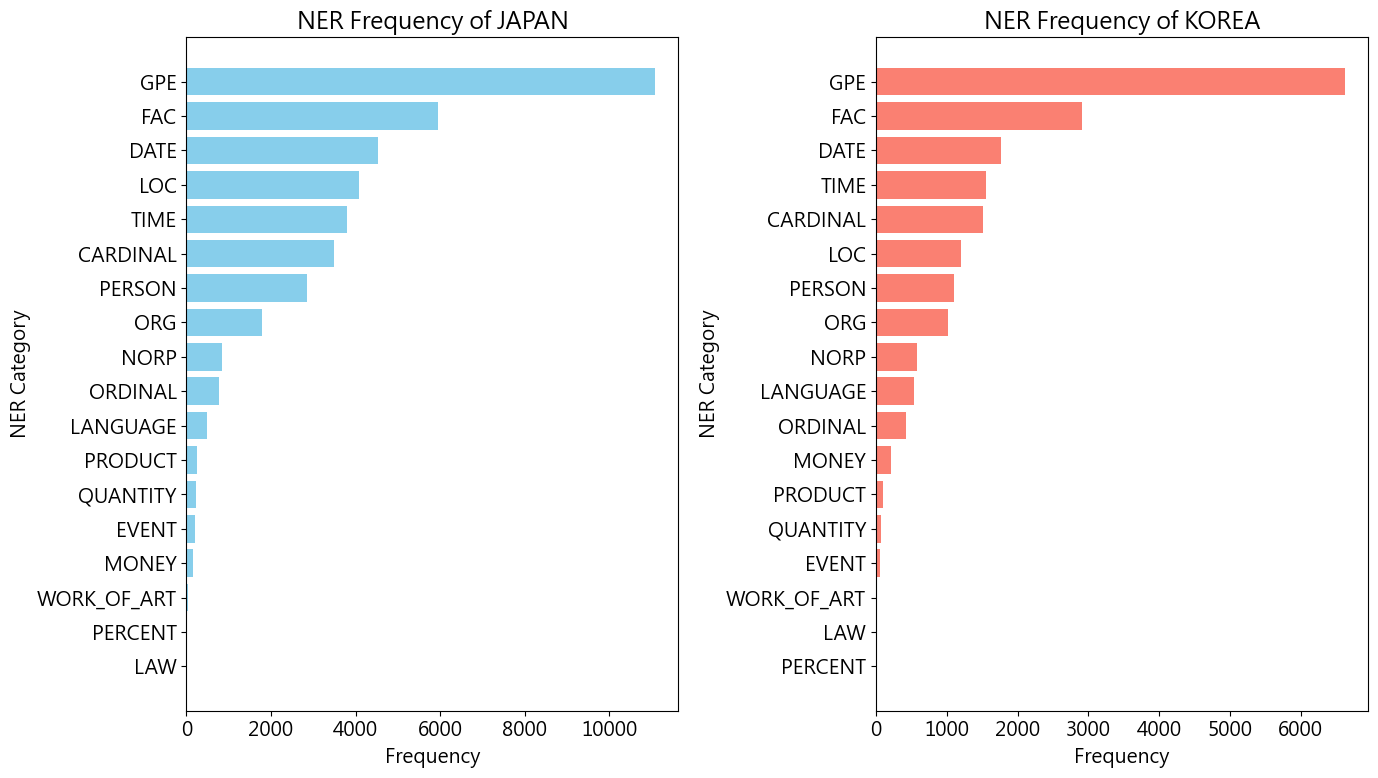

In [ ]:
plt.figure(figsize=(14, 8))

# 日本
plt.subplot(1, 2, 1)
plt.barh(ner_count_j['ner'], ner_count_j['count'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("NER Frequency of JAPAN")
plt.xlabel("Frequency")
plt.ylabel("NER Category")

# 韓國
plt.subplot(1, 2, 2)
plt.barh(ner_count_k['ner'], ner_count_k['count'], color='salmon')
plt.gca().invert_yaxis()
plt.title("NER Frequency of KOREA")
plt.xlabel("Frequency")
plt.ylabel("NER Category")

plt.tight_layout()
plt.show()

#### ORG：涉及到的組織

In [ ]:
def get_ner_top10(entity_table, ner_type="ORG"):
    # 篩選指定 NER 類別
    filtered = entity_table[entity_table['ner'] == ner_type]

    # 計算次數並取前 10
    ner_count = filtered.groupby('word')['word'].agg(['count'])
    ner_count = ner_count.sort_values(['count'], ascending=False).head(10).reset_index()

    return ner_count

# 分別取得日本與韓國的 NORP 前 10 名資料
ner_j_top10 = get_ner_top10(entity_table_j, "ORG")
ner_k_top10 = get_ner_top10(entity_table_k, "ORG")

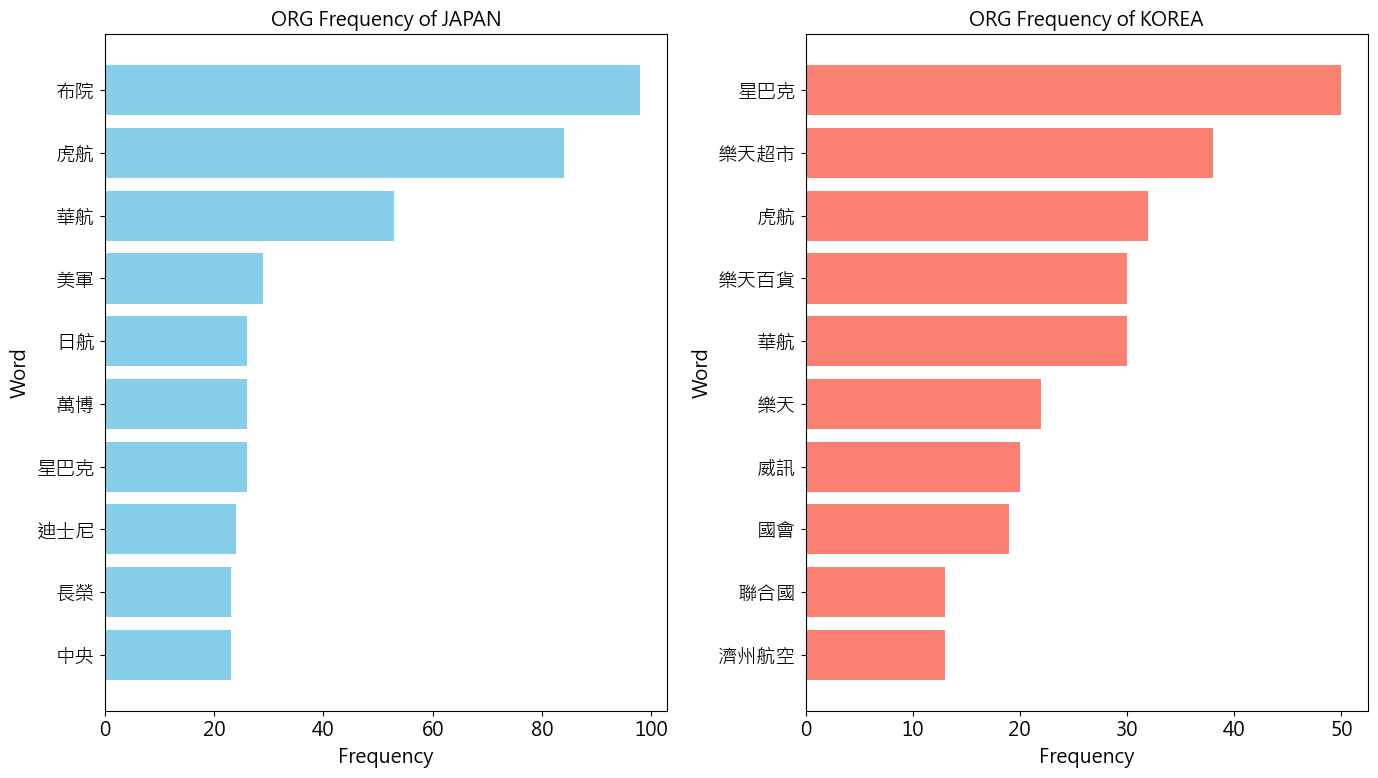

In [ ]:
plt.figure(figsize=(14, 8))

# 日本
plt.subplot(1, 2, 1)
plt.barh(ner_j_top10['word'], ner_j_top10['count'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('ORG Frequency of JAPAN', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')

# 韓國
plt.subplot(1, 2, 2)
plt.barh(ner_k_top10['word'], ner_k_top10['count'], color='salmon')
plt.gca().invert_yaxis()
plt.title('ORG Frequency of KOREA', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.tight_layout()
plt.show()

#### GPE：涉及到的地名

In [ ]:
def get_ner_top10(entity_table, ner_type="GPE"):
    # 篩選指定 NER 類別
    filtered = entity_table[entity_table['ner'] == ner_type]

    # 計算次數並取前 10
    ner_count = filtered.groupby('word')['word'].agg(['count'])
    ner_count = ner_count.sort_values(['count'], ascending=False).head(10).reset_index()

    return ner_count

# 分別取得日本與韓國的 NORP 前 10 名資料
ner_j_top10 = get_ner_top10(entity_table_j, "GPE")
ner_k_top10 = get_ner_top10(entity_table_k, "GPE")

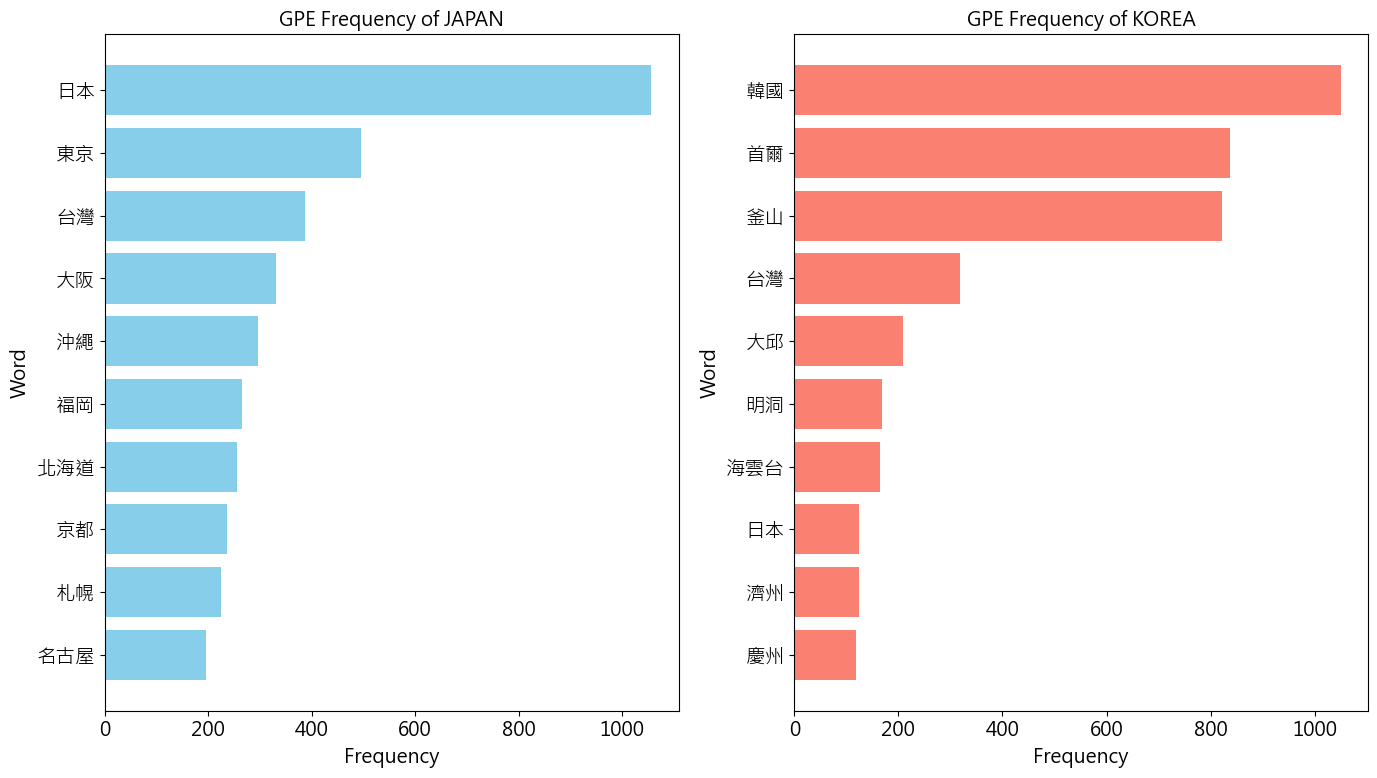

In [ ]:
plt.figure(figsize=(14, 8))

# 日本
plt.subplot(1, 2, 1)
plt.barh(ner_j_top10['word'], ner_j_top10['count'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('GPE Frequency of JAPAN', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')

# 韓國
plt.subplot(1, 2, 2)
plt.barh(ner_k_top10['word'], ner_k_top10['count'], color='salmon')
plt.gca().invert_yaxis()
plt.title('GPE Frequency of KOREA', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.tight_layout()
plt.show()

### 4.2 POS 種類分析

In [ ]:
pos_table_j['pos'].unique()

array(['VJ', 'Na', 'VC', 'P', 'Nd', 'VE', 'Di', 'VA', 'Neu', 'Nc', 'Nes',
       'VH', 'A', 'D', 'Cbb', 'VD', 'Ng', 'SHI', 'DE', 'FW', 'Nf',
       'COMMACATEGORY', 'Da', 'Nh', 'V_2', 'Nb', 'Neqa', 'Ncd', 'DM',
       'Nep', 'VG', 'VK', 'T', 'PERIODCATEGORY', 'Nv', 'Dfa', 'VCL',
       'Caa', 'VI', 'VL', 'Cba', 'VHC', 'VB', 'VF', 'Dfb', 'Dk', 'Cab',
       'PARENTHESISCATEGORY', 'VAC', 'Neqb', 'I', 'COLONCATEGORY',
       'DOTCATEGORY'], dtype=object)

In [ ]:
pos_filter = pos_table_j[~pos_table_j.pos.isin(['COMMACATEGORY', 'PARENTHESISCATEGORY', 'PERIODCATEGORY', 'COLONCATEGORY'])]
pos_count_j = pos_filter.groupby(['pos'])['pos'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(12)
pos_count_j

,pos,count
16,Na,118404
5,D,63354
18,Nc,54126
36,VC,44169
42,VH,35626
6,DE,33118
14,FW,20266
30,P,20078
33,VA,19894
26,Nf,17402


In [ ]:
pos_table_k['pos'].unique()

array(['Neu', 'Nd', 'VCL', 'Di', 'Nc', 'VA', 'COMMACATEGORY', 'P', 'Na',
       'DE', 'D', 'VH', 'VE', 'V_2', 'VJ', 'VC', 'VD', 'Nh', 'Nf', 'Ng',
       'SHI', 'VK', 'Dk', 'Nep', 'Caa', 'Cbb', 'A', 'Da', 'VL', 'Ncd',
       'FW', 'Nes', 'Neqa', 'Dfa', 'VB', 'VF', 'T', 'Nb', 'Nv', 'VHC',
       'I', 'VG', 'VAC', 'Dfb', 'Cab', 'VI', 'Cba', 'Neqb',
       'PARENTHESISCATEGORY', 'DM', 'COLONCATEGORY', 'ETCCATEGORY',
       'PERIODCATEGORY', 'PAUSECATEGORY'], dtype=object)

In [ ]:
pos_filter = pos_table_k[~pos_table_k.pos.isin(['COMMACATEGORY', 'PARENTHESISCATEGORY', 'PERIODCATEGORY', 'COLONCATEGORY'])]
pos_count_k = pos_filter.groupby(['pos'])['pos'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(12)
pos_count_k

,pos,count
16,Na,62112
5,D,33705
18,Nc,26421
37,VC,23300
43,VH,18906
6,DE,14707
34,VA,10343
30,P,9763
26,Nf,8522
4,Cbb,7117


#### Noun：涉及到的名詞

C:\Users\nini\AppData\Local\Temp\ipykernel_3216\1350797206.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


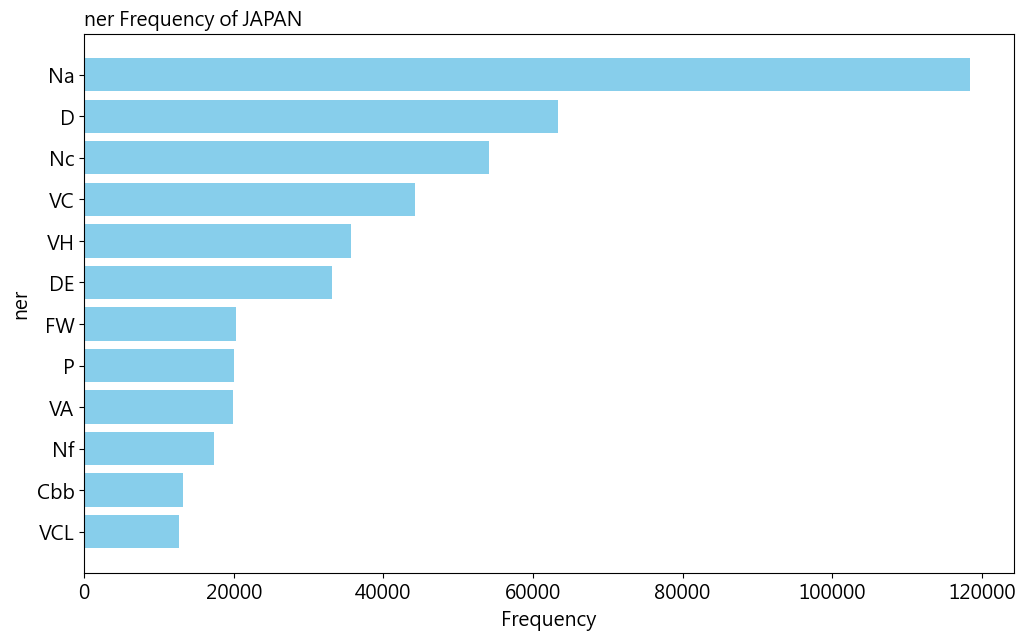

In [ ]:
# 日本
pos_j = pos_count_j['pos']
count_j = pos_count_j['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(pos_j, count_j, color='skyblue')
ax.invert_yaxis()
ax.set_title('ner Frequency of JAPAN',loc ='left', size = 14)
ax.set_ylabel('ner', size = 14)
ax.set_xlabel('Frequency', size = 14)
fig.show()

C:\Users\nini\AppData\Local\Temp\ipykernel_3216\318877595.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


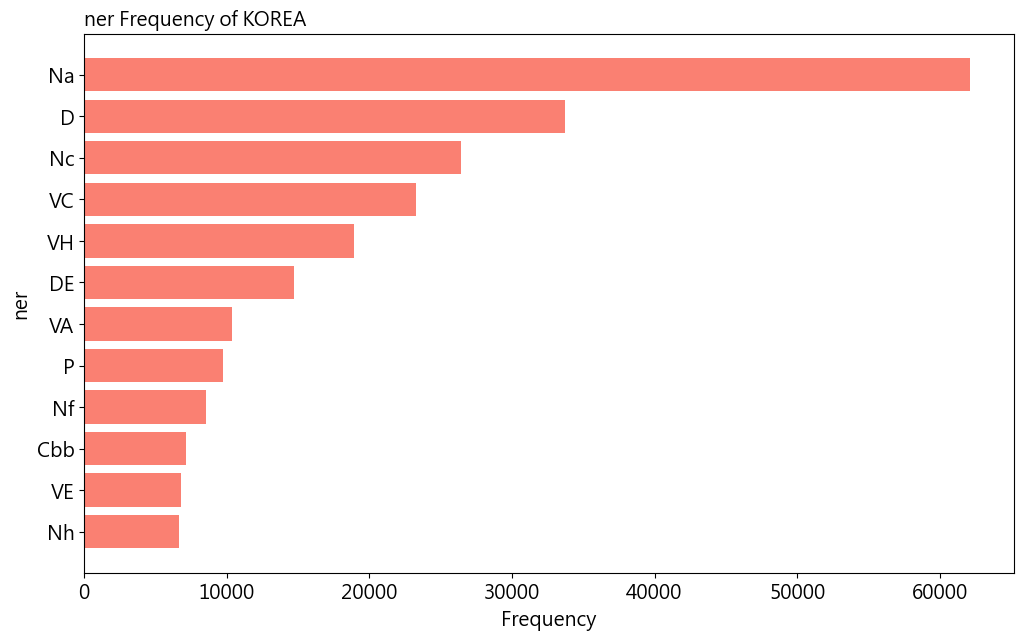

In [ ]:
# 韓國
pos_k = pos_count_k['pos']
count_k = pos_count_k['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(pos_k, count_k, color='salmon')
ax.invert_yaxis()
ax.set_title('ner Frequency of KOREA',loc ='left', size = 14)
ax.set_ylabel('ner', size = 14)
ax.set_xlabel('Frequency', size = 14)
fig.show()

In [ ]:
# 篩選日本與韓國的 Nb (專有名詞)
nb_j = pos_table_j[pos_table_j['pos'] == 'Nb']
nb_k = pos_table_k[pos_table_k['pos'] == 'Nb']

# 計算前 15 名並整理
def get_top15_pos(df):
    count_df = df.groupby('word')['word'].count().reset_index(name='count')
    return count_df.sort_values(['count'], ascending=False).head(15)

noun_count_j = get_top15_pos(nb_j)
noun_count_k = get_top15_pos(nb_k)

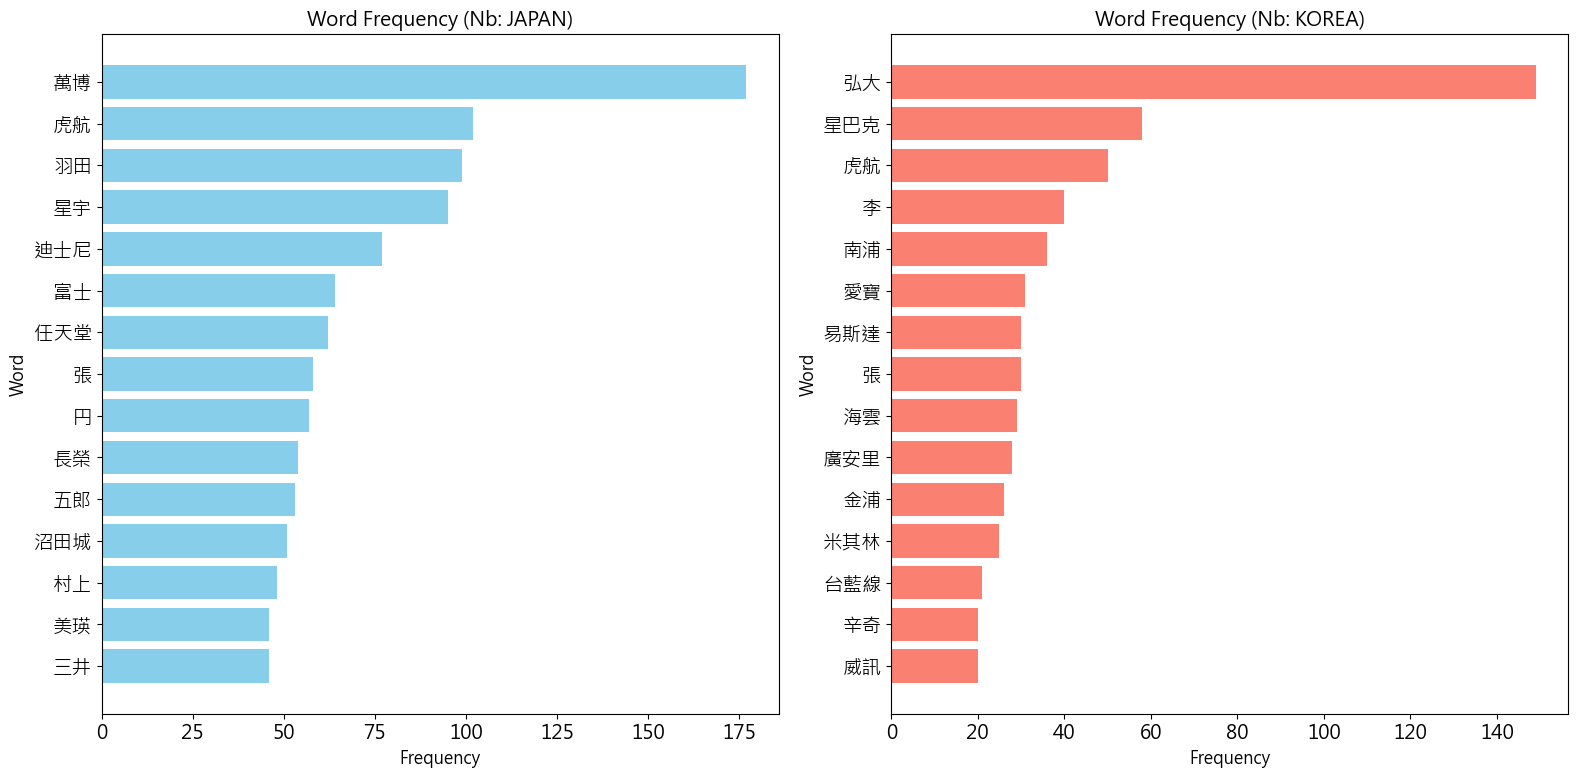

In [ ]:
plt.figure(figsize=(16, 8))

# 日本
plt.subplot(1, 2, 1)
plt.barh(noun_count_j['word'], noun_count_j['count'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Word Frequency (Nb: JAPAN)', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)

# 韓國
plt.subplot(1, 2, 2)
plt.barh(noun_count_k['word'], noun_count_k['count'], color='salmon')
plt.gca().invert_yaxis()
plt.title('Word Frequency (Nb: KOREA)', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)

plt.tight_layout()
plt.show()

#### Verb：涉及到的動詞

In [ ]:
def get_top15_vc(pos_table):
    # 篩選 POS 為 VC 的資料，並過濾掉長度小於等於 1 的字
    vc_data = pos_table[(pos_table['pos'] == 'VC') & (pos_table['word'].str.len() > 1)]

    # 計算次數並取前 15
    vc_count = vc_data.groupby('word')['word'].count().reset_index(name='count')
    return vc_count.sort_values(['count'], ascending=False).head(15)

vc_count_j = get_top15_vc(pos_table_j)
vc_count_k = get_top15_vc(pos_table_k)

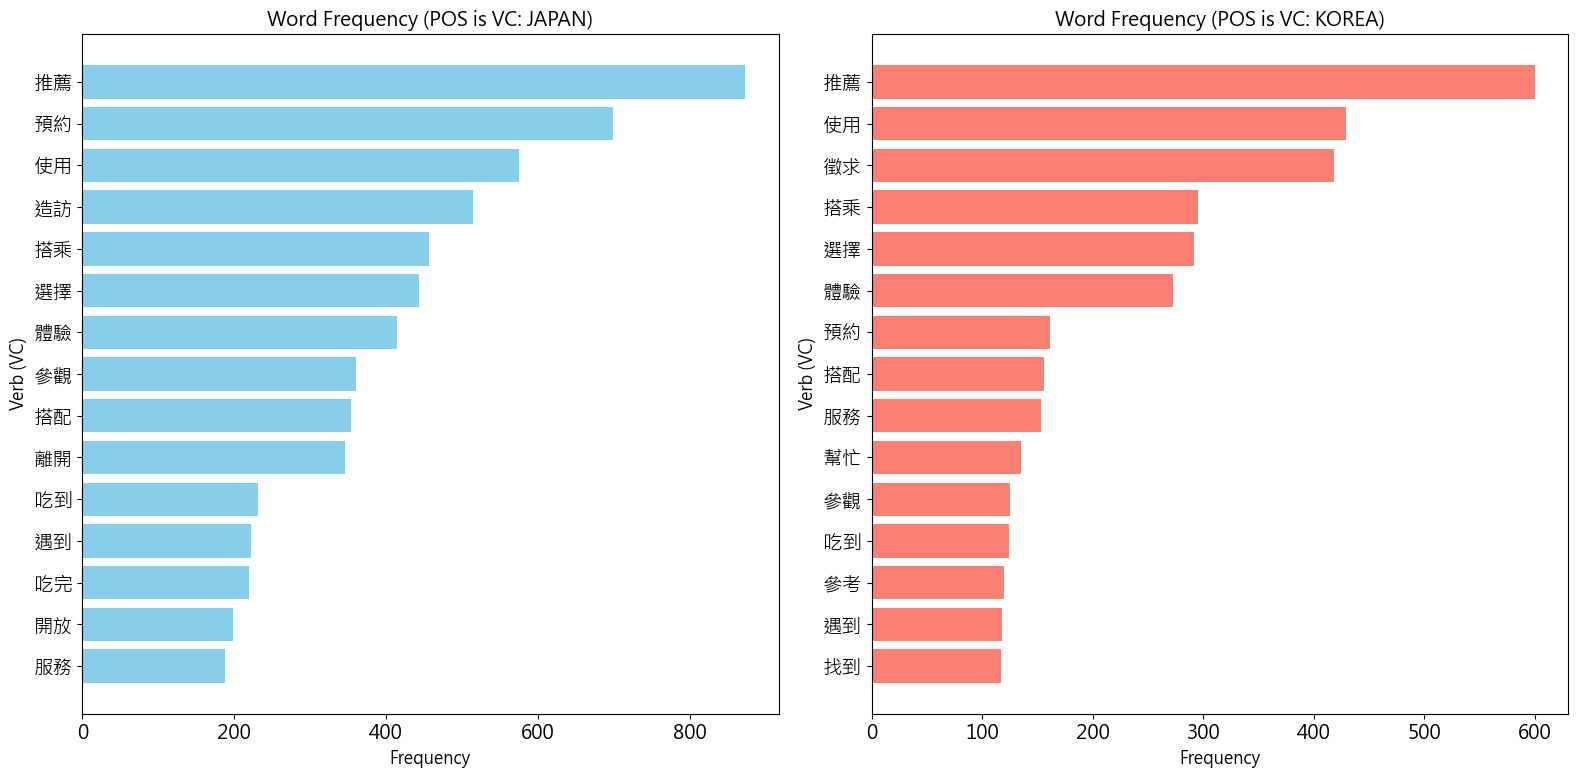

In [ ]:
plt.figure(figsize=(16, 8))

# 日本
plt.subplot(1, 2, 1)
plt.barh(vc_count_j['word'], vc_count_j['count'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Word Frequency (POS is VC: JAPAN)', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Verb (VC)', fontsize=12)

# 韓國
plt.subplot(1, 2, 2)
plt.barh(vc_count_k['word'], vc_count_k['count'], color='salmon')
plt.gca().invert_yaxis()
plt.title('Word Frequency (POS is VC: KOREA)', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Verb (VC)', fontsize=12)

plt.tight_layout()
plt.show()

## 5. 找出重要詞彙 - TFIDF

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import jieba
import jieba.analyse
import math
from nltk import ngrams, FreqDist
from collections import Counter, namedtuple

import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
# 設定圖的中文字體 (無法顯示的話可以試試‘Microsoft JhengHei’字體)
# 也可參考：https://pyecontech.com/2020/03/27/python_matplotlib_chinese/
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] #使圖中中文能正常顯示
plt.rcParams['axes.unicode_minus'] = False #使負號能夠顯示

In [ ]:
#匯入資料
df_j = pd.read_csv('raw_data/japan.csv')
df_k = pd.read_csv('raw_data/korea.csv')
df_j.head(3)

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource,country
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,pttbird,Japan_Travel,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""Hurubear"", ""...",61.220.191.67,2025/5/28 01:26,ptt,日本
1,2,https://www.ptt.cc/bbs/Japan_Travel/M.17483327...,[問題]高千穗一日遊疑問,2025/5/27 15:59,n61208,Japan_Travel,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""Dheroblood"",...",223.141.206.76,2025/5/28 01:26,ptt,日本
2,3,https://www.ptt.cc/bbs/Japan_Travel/M.17483552...,[問題]花火大會選擇（葛飾納涼/熱海/隅田川）,2025/5/27 22:13,angelstar,Japan_Travel,１． 出遊日期： 2025年7月下旬\n\n２． 行程：想參加花火大會（帶小孩）\n\n３．...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""leejones"", ""...",123.192.200.9,2025/5/28 01:26,ptt,日本


In [ ]:
df_k.head(3)

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource,country
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,Aaron22,Korea_Travel,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""lakai199"", ""...",49.216.53.202,2023/4/28 01:50,ptt,韓國
1,2,https://www.ptt.cc/bbs/Korea_Travel/M.16825675...,[問題]睡機場或其他,2023/4/27 11:53,massaget,Korea_Travel,各位大大好，小弟即將在下個月前往韓國\n由於虎航的的班機表定是01:30到仁川機場，一航的過...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""dbdudsorj"", ...",118.163.134.243,2023/4/28 01:50,ptt,韓國
2,3,https://www.ptt.cc/bbs/Korea_Travel/M.16826436...,[遊記]首爾｜6天5夜自由行。景點美食與城市體驗,2023/4/28 08:59,abc9442,Korea_Travel,圖文網誌建議閱讀版：\nhttps://listentolu.com/2023/04/seo...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""richuncle97""...",101.12.49.111,2023/4/30 01:54,ptt,韓國


In [ ]:
MetaData_j = df_j.copy()

# 去除一些不需要的欄位
MetaData_j = MetaData_j.drop(['artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource'], axis=1)
# 只留下中文字
MetaData_j['sentence'] = MetaData_j['artContent'].fillna('').apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '', x))
MetaData_j.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...
1,2,https://www.ptt.cc/bbs/Japan_Travel/M.17483327...,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,家人週末想在當地參加一日遊行程看了幾個套裝大同小異唯獨幾個景點稍微不同想請教各位的看法基本上...
2,3,https://www.ptt.cc/bbs/Japan_Travel/M.17483552...,[問題]花火大會選擇（葛飾納涼/熱海/隅田川）,2025/5/27 22:13,１． 出遊日期： 2025年7月下旬\n\n２． 行程：想參加花火大會（帶小孩）\n\n３．...,日本,出遊日期年月下旬行程想參加花火大會帶小孩特別希望不需要太早佔位亦可觀賞到煙火散場時人潮沒有太...


In [ ]:
MetaData_k = df_k.copy()

# 去除一些不需要的欄位
MetaData_k = MetaData_k.drop(['artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource'], axis=1)
# 只留下中文字
MetaData_k['sentence'] = MetaData_k['artContent'].fillna('').apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '', x))
MetaData_k.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...
1,2,https://www.ptt.cc/bbs/Korea_Travel/M.16825675...,[問題]睡機場或其他,2023/4/27 11:53,各位大大好，小弟即將在下個月前往韓國\n由於虎航的的班機表定是01:30到仁川機場，一航的過...,韓國,各位大大好小弟即將在下個月前往韓國由於虎航的的班機表定是到仁川機場一航的過境旅館又已經客滿想...
2,3,https://www.ptt.cc/bbs/Korea_Travel/M.16826436...,[遊記]首爾｜6天5夜自由行。景點美食與城市體驗,2023/4/28 08:59,圖文網誌建議閱讀版：\nhttps://listentolu.com/2023/04/seo...,韓國,圖文網誌建議閱讀版我會記得有藍天和春風以及有你相陪的那一段粉雪路網路上的分享資訊已經豐富得讓...


In [ ]:
# 設定繁體中文詞庫
jieba.set_dictionary('./dict/dict.txt.big')

# 新增stopwords
with open('./dict/stopwords.txt',encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

In [ ]:
# 設定斷詞 function
def getToken(row):
    seg_list = jieba.lcut(row)
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1] # 篩選掉停用字與字元數小於1的詞彙

    return seg_list

In [ ]:
data_j = MetaData_j.copy()

# 斷詞、去除停用字並將word欄位展開
data_j['word'] = data_j.sentence.apply(getToken).explode('word')

data_j.head(3)

Building prefix dict from c:\Users\nini\Desktop\NSYSU\1142\MIS581\socialmdeia_final\socialmdeia_final\dict\dict.txt.big ...
Loading model from cache C:\Users\nini\AppData\Local\Temp\jieba.ub01dbff3076852d519d04b1e682c58bd.cache
Loading model cost 1.494 seconds.
Prefix dict has been built successfully.


,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,取之於
1,2,https://www.ptt.cc/bbs/Japan_Travel/M.17483327...,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,家人週末想在當地參加一日遊行程看了幾個套裝大同小異唯獨幾個景點稍微不同想請教各位的看法基本上...,旅版
2,3,https://www.ptt.cc/bbs/Japan_Travel/M.17483552...,[問題]花火大會選擇（葛飾納涼/熱海/隅田川）,2025/5/27 22:13,１． 出遊日期： 2025年7月下旬\n\n２． 行程：想參加花火大會（帶小孩）\n\n３．...,日本,出遊日期年月下旬行程想參加花火大會帶小孩特別希望不需要太早佔位亦可觀賞到煙火散場時人潮沒有太...,回饋


In [ ]:
data_k = MetaData_k.copy()

# 斷詞、去除停用字並將word欄位展開
data_k['word'] = data_k.sentence.apply(getToken).explode('word')

data_k.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,四月
1,2,https://www.ptt.cc/bbs/Korea_Travel/M.16825675...,[問題]睡機場或其他,2023/4/27 11:53,各位大大好，小弟即將在下個月前往韓國\n由於虎航的的班機表定是01:30到仁川機場，一航的過...,韓國,各位大大好小弟即將在下個月前往韓國由於虎航的的班機表定是到仁川機場一航的過境旅館又已經客滿想...,初去
2,3,https://www.ptt.cc/bbs/Korea_Travel/M.16826436...,[遊記]首爾｜6天5夜自由行。景點美食與城市體驗,2023/4/28 08:59,圖文網誌建議閱讀版：\nhttps://listentolu.com/2023/04/seo...,韓國,圖文網誌建議閱讀版我會記得有藍天和春風以及有你相陪的那一段粉雪路網路上的分享資訊已經豐富得讓...,首爾


In [ ]:
japan_df = MetaData_j.copy()
korea_df = MetaData_k.copy()
japan_df.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...
1,2,https://www.ptt.cc/bbs/Japan_Travel/M.17483327...,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,家人週末想在當地參加一日遊行程看了幾個套裝大同小異唯獨幾個景點稍微不同想請教各位的看法基本上...
2,3,https://www.ptt.cc/bbs/Japan_Travel/M.17483552...,[問題]花火大會選擇（葛飾納涼/熱海/隅田川）,2025/5/27 22:13,１． 出遊日期： 2025年7月下旬\n\n２． 行程：想參加花火大會（帶小孩）\n\n３．...,日本,出遊日期年月下旬行程想參加花火大會帶小孩特別希望不需要太早佔位亦可觀賞到煙火散場時人潮沒有太...


In [ ]:
korea_df.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...
1,2,https://www.ptt.cc/bbs/Korea_Travel/M.16825675...,[問題]睡機場或其他,2023/4/27 11:53,各位大大好，小弟即將在下個月前往韓國\n由於虎航的的班機表定是01:30到仁川機場，一航的過...,韓國,各位大大好小弟即將在下個月前往韓國由於虎航的的班機表定是到仁川機場一航的過境旅館又已經客滿想...
2,3,https://www.ptt.cc/bbs/Korea_Travel/M.16826436...,[遊記]首爾｜6天5夜自由行。景點美食與城市體驗,2023/4/28 08:59,圖文網誌建議閱讀版：\nhttps://listentolu.com/2023/04/seo...,韓國,圖文網誌建議閱讀版我會記得有藍天和春風以及有你相陪的那一段粉雪路網路上的分享資訊已經豐富得讓...


In [ ]:
# 保留需要的欄位
japan_df = japan_df.loc[:,["system_id", "sentence"]]

# 改成使用空格連接斷完的詞
japan_df['word'] = japan_df.sentence.apply(getToken).map(' '.join)
japan_df.head()

,system_id,sentence,word
0,1,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,取之於 旅版 回饋 旅版 研究 一輪 神戶 住宿 三宮 車站 經濟 實惠 水準 最優 還沒 ...
1,2,家人週末想在當地參加一日遊行程看了幾個套裝大同小異唯獨幾個景點稍微不同想請教各位的看法基本上...,家人 週末 參加 一日遊 行程 幾個 套裝 大同小異 唯獨 幾個 景點 稍微 請教 看法 上...
2,3,出遊日期年月下旬行程想參加花火大會帶小孩特別希望不需要太早佔位亦可觀賞到煙火散場時人潮沒有太...,出遊 日期 下旬 行程 參加 花火 大會 小孩 特別 希望 太早 佔位 亦可 觀賞 煙火 散...
3,4,晚安我是原不好意思有些函館交通的問題想請教因為查了一些文章還是有些細節不確定函館山觀景台想請...,晚安 不好意思 函館 交通 問題 請教 因為查 文章 細節 確定 函館 觀景 台想 請問 下...
4,5,今年想規劃到東北賞楓葉天預計從青森出發往南至仙台大致如下弘前奧入瀨八甲田山抱溪返谷平泉中尊寺...,今年 規劃 東北 楓葉 預計 青森 出發 往南至 仙台 弘前 奧入 八甲 田山 抱溪 返谷 ...


In [ ]:
# 保留需要的欄位
korea_df = korea_df.loc[:,["system_id", "sentence"]]

# 改成使用空格連接斷完的詞
korea_df['word'] = korea_df.sentence.apply(getToken).map(' '.join)
korea_df.head()

,system_id,sentence,word
0,1,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,四月 初去 首爾 旅遊 旅途 突然 胃痛 不適 隔天 一早 決定 硬撐 不去 就醫 直接 返...
1,2,各位大大好小弟即將在下個月前往韓國由於虎航的的班機表定是到仁川機場一航的過境旅館又已經客滿想...,小弟 下個月 韓國 虎航 班機 表定 仁川 機場 一航 過境 旅館 客滿 請教 大會 考慮 ...
2,3,圖文網誌建議閱讀版我會記得有藍天和春風以及有你相陪的那一段粉雪路網路上的分享資訊已經豐富得讓...,圖文 網誌 建議 閱讀 我會 記得 藍天 春風 相陪 一段 雪路 網路上 分享 資訊 豐富 ...
3,4,住宿的地點在東大門歷史文化公園站用查詢從金浦機場過去有兩種方式號線地鐵搭站總共分到達不用轉乘...,住宿 地點 大門 歷史 文化公園 查詢 金浦 機場 過去 兩種 號線 地鐵 搭站 總共 到達...
4,5,住宿名稱乙支路高爺商業公寓入住時間年月住宿地址住宿電話住宿房型雙床單房公寓圖文好讀版快閃首爾...,住宿 名稱 支路 高爺 商業 公寓 入住 住宿 地址 住宿 電話 住宿 房型 雙床 單房 公...


In [ ]:
# Bag of Word
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(japan_df["word"])
vocabulary_j = vectorizer.get_feature_names_out()

# 轉成 dataframe
DTM_df_j = pd.DataFrame(columns = vocabulary_j, data = X.toarray())
DTM_df_j

,一一,一丁,一三麗鷗,一上午,一下下,一下全部,一下子,一下站,一不小心,一並,...,龜正,龜殼,龜毛,龜狀,龜琴,龜甲,龜石,龜虎,龜號,龜龜
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2334,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2335,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2336,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2337,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Bag of Word
vectorizer = CountVectorizer()
Y = vectorizer.fit_transform(korea_df["word"])
vocabulary_k = vectorizer.get_feature_names_out()

# 轉成 dataframe
DTM_df_k = pd.DataFrame(columns = vocabulary_k, data = Y.toarray())
DTM_df_k

,一一,一上午,一下下,一下子,一下站,一不小心,一串,一乘,一二,一二三,...,龍頭山,龍騰卡,龐大,龜尾,龜尾慶,龜尾慶山,龜山島,龜島,龜毛,龜速
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1074,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1075,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1076,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
transformer_j = TfidfTransformer()
# 將詞頻矩陣X統計成TF-IDF值
tfidf_j = transformer_j.fit_transform(X)

# 轉成dataframe
TFIDF_df_j = pd.DataFrame(columns = vocabulary_j, data = tfidf_j.toarray())

TFIDF_df_j

,一一,一丁,一三麗鷗,一上午,一下下,一下全部,一下子,一下站,一不小心,一並,...,龜正,龜殼,龜毛,龜狀,龜琴,龜甲,龜石,龜虎,龜號,龜龜
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2334,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2335,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2336,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2337,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
transformer_k = TfidfTransformer()
# 將詞頻矩陣Y統計成TF-IDF值
tfidf_k = transformer_k.fit_transform(Y)

# 轉成dataframe
TFIDF_df_k = pd.DataFrame(columns = vocabulary_k, data = tfidf_k.toarray())

TFIDF_df_k

,一一,一上午,一下下,一下子,一下站,一不小心,一串,一乘,一二,一二三,...,龍頭山,龍騰卡,龐大,龜尾,龜尾慶,龜尾慶山,龜山島,龜島,龜毛,龜速
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 檢視結果   

#### 取每一個字詞在所有文件裡的TF-IDF平均值

In [ ]:
jp_tfidf = TFIDF_df_j.mean().to_frame().reset_index()
jp_tfidf.columns = ["word", "avg"]

jp_tfidf.sort_values('avg', ascending = False).head(10)

,word,avg
42996,飯店,0.014917
35221,行程,0.014208
20727,日本,0.010514
23560,機場,0.010472
19197,推薦,0.010144
22493,東京,0.009776
37967,車站,0.009385
26184,溫泉,0.008530
11885,大阪,0.008391
3545,住宿,0.008222


In [ ]:
kr_tfidf = TFIDF_df_k.mean().to_frame().reset_index()
kr_tfidf.columns = ["word", "avg"]

kr_tfidf.sort_values('avg', ascending = False).head(10)

,word,avg
9692,徵求,0.037460
23566,釜山,0.033996
25234,首爾,0.033884
24705,韓國,0.027698
13767,機場,0.027604
11121,推薦,0.021830
20262,行程,0.021782
25103,飯店,0.019075
9856,性別,0.018290
21057,請問,0.017986


#### 取每份文件裡TF-IDF值最大的前10個字詞當為常用字詞，再取每一個字詞在常用字詞中出現頻率

In [ ]:
toptens_j = TFIDF_df_j.copy()
toptens_j.insert(0, 'doc_id', toptens_j.index+1)

toptens_j

,doc_id,一一,一丁,一三麗鷗,一上午,一下下,一下全部,一下子,一下站,一不小心,...,龜正,龜殼,龜毛,龜狀,龜琴,龜甲,龜石,龜虎,龜號,龜龜
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2334,2335,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2335,2336,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2336,2337,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2337,2338,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
toptens_k = TFIDF_df_k.copy()
toptens_k.insert(0, 'doc_id', toptens_k.index+1)

toptens_k

,doc_id,一一,一上午,一下下,一下子,一下站,一不小心,一串,一乘,一二,...,龍頭山,龍騰卡,龐大,龜尾,龜尾慶,龜尾慶山,龜山島,龜島,龜毛,龜速
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073,1074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1074,1075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1075,1076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1076,1077,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
toptens_j = toptens_j.melt(id_vars = "doc_id", var_name = "word", value_name = 'tfidf')
toptens_j

,doc_id,word,tfidf
0,1,一一,0.0
1,2,一一,0.0
2,3,一一,0.0
3,4,一一,0.0
4,5,一一,0.0
...,...,...,...
103931121,2335,龜龜,0.0
103931122,2336,龜龜,0.0
103931123,2337,龜龜,0.0
103931124,2338,龜龜,0.0


In [ ]:
toptens_k = toptens_k.melt(id_vars = "doc_id", var_name = "word", value_name = 'tfidf')
toptens_k

,doc_id,word,tfidf
0,1,一一,0.0
1,2,一一,0.0
2,3,一一,0.0
3,4,一一,0.0
4,5,一一,0.0
...,...,...,...
27898635,1074,龜速,0.0
27898636,1075,龜速,0.0
27898637,1076,龜速,0.0
27898638,1077,龜速,0.0


nlargest() 會回傳指定列中最大的前10個值所對應的資料

In [ ]:
# 先過濾掉 tfidf 為 0 的字詞，只保留文章中真正出現過的詞
toptens_j_filtered = toptens_j[toptens_j['tfidf'] > 0]

# 從每篇文章挑選出tf-idf最大的前十個詞
result_j = (
    toptens_j_filtered.groupby("doc_id")
    .apply(lambda x: x.nlargest(10, "tfidf"))
    .reset_index(drop=True)
    .groupby(['word'], as_index=False).size() # 計算每個詞被選中的次數
)

result_j['size'] = result_j['size'].astype(int)

# # 排序看前十名
result_j.sort_values('size', ascending=False).head(10)

C:\Users\nini\AppData\Local\Temp\ipykernel_1556\30813718.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, "tfidf"))


,word,size
5629,飯店,91
4144,福岡,57
3628,溫泉,54
1729,大阪,52
3100,東京,51
1294,名古屋,48
443,京都,45
4740,行程,42
5041,車站,41
2224,巴士,41


In [ ]:
# 先過濾掉 tfidf 為 0 的字詞，只保留文章中真正出現過的詞
toptens_k_filtered = toptens_k[toptens_k['tfidf'] > 0]

# 從每篇文章挑選出tf-idf最大的前十個詞
result_k = (
    toptens_k_filtered.groupby("doc_id")
    .apply(lambda x: x.nlargest(10, "tfidf"))
    .reset_index(drop=True)
    .groupby(['word'], as_index=False).size() # 計算每個詞被選中的次數
)

result_k['size'] = result_k['size'].astype(int)

# # 排序看前十名
result_k.sort_values('size', ascending=False).head(10)

C:\Users\nini\AppData\Local\Temp\ipykernel_1556\3465669774.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, "tfidf"))


,word,size
2386,徵求,115
5334,釜山,86
3309,機場,51
5660,飯店,50
5685,首爾,43
1733,大邱,42
5649,食伴,40
2943,明洞,37
4703,西面,34
2986,晚餐,29


## 6. 透過結巴斷詞與N-gram幫助建立斷詞字典

### 6.1 Bigram

In [ ]:
# 設定 ngram 斷詞 function
def ngram_getToken(row, n):
    # 進行斷詞
    seg_list = jieba.lcut(row)

    # 篩選掉停用字與字元數小於1的詞彙
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1]

    # ngram斷詞
    seg_list = ngrams(seg_list, n)
    seg_list = [" ".join(w) for w in list(seg_list)]

    return seg_list

In [ ]:
jp_bigram = MetaData_j.copy()

jp_bigram["word"] = jp_bigram['sentence'].apply(lambda row: ngram_getToken(row, 2))
jp_bigram = jp_bigram.explode('word')

jp_bigram.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,取之於 旅版
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,旅版 回饋
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,回饋 旅版


In [ ]:
kr_bigram = MetaData_k.copy()

kr_bigram["word"] = kr_bigram['sentence'].apply(lambda row: ngram_getToken(row, 2))
kr_bigram = kr_bigram.explode('word')

kr_bigram.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,四月 初去
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,初去 首爾
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,首爾 旅遊


#### 統計最常出現的bigram組合

In [ ]:
# 日旅
# 計算每個組合出現的次數
jp_bigram_count = jp_bigram['word'].value_counts().reset_index()

jp_bigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,造訪 日期,374
1,出遊 日期,133
2,每日 行程,122
3,圖文 網誌,95
4,關西 機場,91
5,車站 附近,86
6,特別 希望,83
7,寄放 行李,81
8,當日 預約,80
9,環球 影城,69


In [ ]:
# 韓旅
# 計算每個組合出現的次數
kr_bigram_count = kr_bigram['word'].value_counts().reset_index()

kr_bigram_count.sort_values('count', ascending=False).head(10)
### 4.2 Trigram

,word,count
0,徵求 類別,187
1,仁川 機場,141
2,豬肉 湯飯,112
3,膠囊 列車,112
4,性別 徵求,94
5,海岸 列車,76
6,廣藏 市場,73
7,樂天 世界,69
8,樂天 超市,69
9,站號 出口,68


In [ ]:
jp_trigram = MetaData_j.copy()

jp_trigram["word"] = jp_trigram['sentence'].apply(lambda row: ngram_getToken(row, 3))
jp_trigram = jp_trigram.explode('word')

jp_trigram.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,取之於 旅版 回饋
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,旅版 回饋 旅版
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,回饋 旅版 研究


In [ ]:
kr_trigram = MetaData_k.copy()

kr_trigram["word"] = kr_trigram['sentence'].apply(lambda row: ngram_getToken(row, 3))
kr_trigram = kr_trigram.explode('word')

kr_trigram.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,四月 初去 首爾
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,初去 首爾 旅遊
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,首爾 旅遊 旅途


#### 統計最常出現的trigram組合

In [ ]:
# 日旅
# 計算每個組合出現的次數
jp_trigram_count = jp_trigram['word'].value_counts().reset_index()
jp_trigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,造訪 日期 圖文,46
1,電話 交通 手段,42
2,日期 圖文 網誌,34
3,物品 買入 價格,33
4,物品 圖片 物品,32
5,圖片 物品 買入,32
6,買入 價格 讓售,27
7,價格 讓售 金額,27
8,沖繩 兒童 王國,25
9,神戶 動物 王國,22


In [ ]:
# 韓旅
# 計算每個組合出現的次數
kr_trigram_count = kr_trigram['word'].value_counts().reset_index()

kr_trigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,徵求 類別 食伴,42
1,徵求 類別 旅伴,34
2,食伴 性別 徵求,31
3,海雲台 藍線 公園,30
4,類別 食伴 性別,28
5,天空 膠囊 列車,25
6,旅伴 食伴 性別,21
7,圖文 網誌 建議,21
8,網誌 建議 閱讀,21
9,旅伴 性別 徵求,20


### 6.3 使用自建字典

In [ ]:
# 新增相關自定義字典
jieba.load_userdict('./dict/lexicon.txt')

**使用自建辭典進行斷詞與計算**

In [ ]:
# 剛才的斷詞結果沒有使用新增的辭典，因此我們重新進行斷詞
data_j = MetaData_j.copy()
data_j['word'] = data_j.sentence.apply(getToken)
data_j = data_j.explode('word')

data_j.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,取之於
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,旅版
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,回饋


In [ ]:
# 剛才的斷詞結果沒有使用新增的辭典，因此我們重新進行斷詞
data_k = MetaData_k.copy()
data_k['word'] = data_k.sentence.apply(getToken)
data_k = data_k.explode('word')

data_k.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,四月
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,初去
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,首爾


更新斷詞字典後重新進行bigram斷詞

In [ ]:
bigramjdist = MetaData_j.copy()

bigramjdist["word"] = bigramjdist['sentence'].apply(lambda row: ngram_getToken(row, 2))
bigramjdist = bigramjdist.explode('word')

bigramjdist.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,取之於 旅版
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,旅版 回饋
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,回饋 旅版


In [ ]:
bigramkdist = MetaData_k.copy()

bigramkdist["word"] = bigramkdist['sentence'].apply(lambda row: ngram_getToken(row, 2))
bigramkdist = bigramkdist.explode('word')

bigramkdist.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,四月 初去
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,初去 首爾
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,首爾 旅遊


In [ ]:
bigramjdist['word'] = bigramjdist['word'].astype(str)

bigramjdist = bigramjdist[
    (bigramjdist['word'] != 'nan') &
    (bigramjdist['word'].str.strip() != '')
]

# 使用FreqDist 取得 bigram 斷詞 與 bigram出現頻率
bigramjdist1 = FreqDist(bigramjdist['word'].apply(lambda x: tuple(x.split(' '))))
bigramjdist1.most_common(5)

[(('每日', '行程'), 122),
 (('圖文', '網誌'), 95),
 (('車站', '附近'), 86),
 (('特別', '希望'), 83),
 (('當日', '預約'), 80)]

In [ ]:
bigramkdist['word'] = bigramkdist['word'].astype(str)

# 使用FreqDist 取得 bigram 斷詞 與 bigram出現頻率
bigramkdist = FreqDist(bigramkdist['word'].apply(lambda x: tuple(x.split(' '))))
bigramkdist.most_common(5)

[(('徵求', '類別'), 187),
 (('性別', '徵求'), 94),
 (('海岸', '列車'), 76),
 (('廣藏', '市場'), 73),
 (('站號', '出口'), 68)]

除了利用N-gram來幫助建立斷詞字典，N-gram也能幫助我們發現詞與詞之間的連貫關係。

接下來針對重新斷詞後的bigram出現頻率最高的前50對進行視覺化，觀察文章的關鍵詞對

In [ ]:
# 建立bigram和count的dictionary
# 這裡取最多的前50項
d_j = {k:v for k,v in bigramjdist1.most_common(50)}
d_k = {k:v for k,v in bigramkdist.most_common(50)}

In [ ]:
# Create network plot
# 日旅
G_j = nx.Graph()

# 建立 nodes 間的連結
for k, v in [d_j][0].items():
    G_j.add_edge(k[0], k[1], weight=v) # nodes：詞彙，weight：組合出現頻率

# 取得調整edge權重
weights = [w[2]['weight']*0.01 for w in  G_j.edges(data=True)]
# -------------------------------------------------------------------------------
# 韓旅
G_k = nx.Graph()

# 建立 nodes 間的連結
for k, v in [d_k][0].items():
    G_k.add_edge(k[0], k[1], weight=v) # nodes：詞彙，weight：組合出現頻率

# 取得調整edge權重
weights = [w[2]['weight']*0.01 for w in  G_k.edges(data=True)]

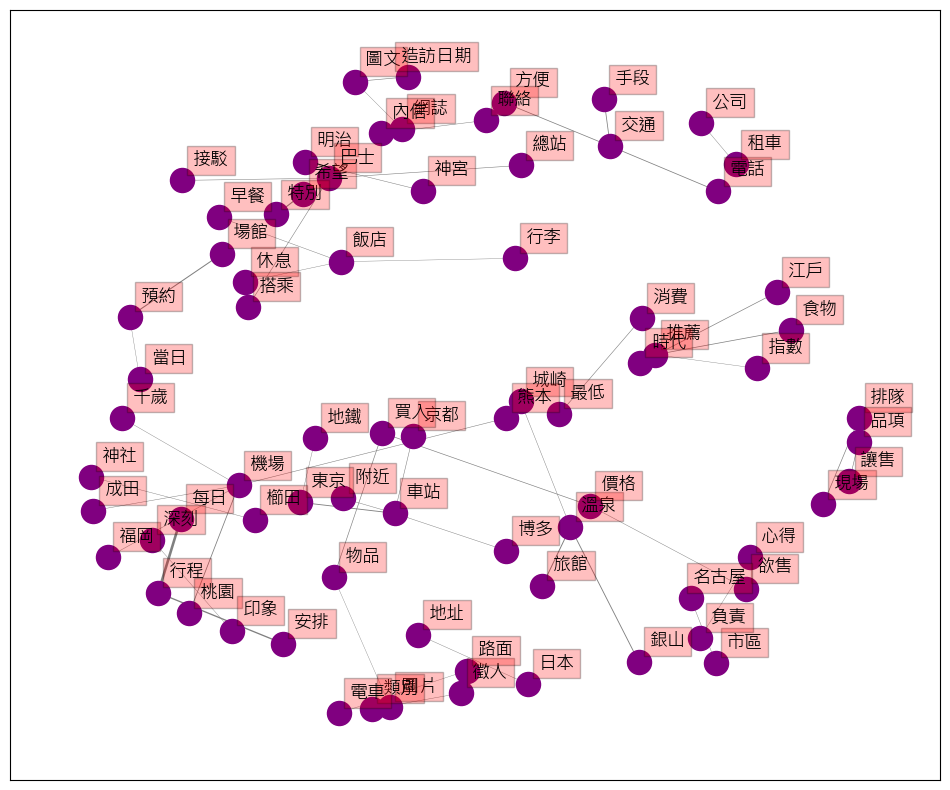

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G_j, k=1.5)

# networks
nx.draw_networkx(G_j, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='purple',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=13)

plt.show()

日旅版

🔹 左下群聚焦於 機場出入境&行程安排
這一群是日本旅遊規劃的起點與核心樞紐，明確指向台日之間的航班與機場節點，包含「機場」、「成田」、「福岡」與「千歲」等具體航點，並緊密連結「行程」、「安排」與「印象」等詞，反映網友對班機起降與整體旅行路線規劃的熱烈討論。

🔹 中右群聚焦於 熱門城市&溫泉景點
此群組主要探討日本各地的重點旅遊區域與住宿消費，包含「東京」、「京都」、「熊本」、「博多」與「名古屋」等知名地名，並扣連「溫泉」、「價格」、「推薦」與「旅館」等概念，呈現出網民對各地特色景點住宿體驗、性價比與行程推薦的綜合評比。

🔹 左上群聚焦於 住宿預約&周邊接駁
這一群涉及具體的飯店預訂與交通接駁細節，包含「飯店」、「預約」、「早餐」與「休息」，並延伸至「巴士」、「接駁」、「神宮」等。顯示網民在分享或請益時，非常注重住宿附加服務與前往周邊景點的交通便利性。

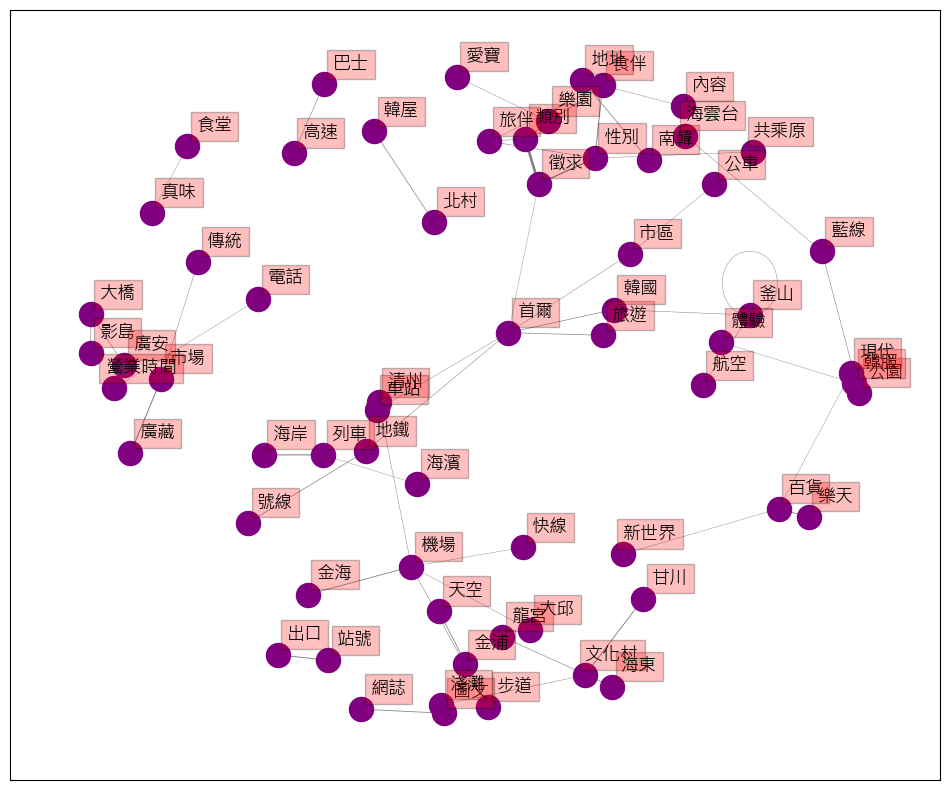

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G_k, k=1.5)

# networks
nx.draw_networkx(G_k, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='purple',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=13)

plt.show()

韓旅版

🔸 右上群聚焦於 尋找旅伴&樂園行程
這一群反映了旅遊論壇上常見的揪團與同行需求，包含「徵求」、「旅伴」、「性別」與「類別」等版規或發文標籤，並進一步與「愛寶」、「樂園」相連。顯示網友在規劃前往大型遊樂園等特定景點時，常會透過發文尋求條件相符的同行者。

🔸 左側群聚焦於 傳統市場&在地美食
此群組主要討論韓國當地的飲食文化與採買行程，包含「市場」、「傳統」、「食堂」、「廣藏」等具體地點與餐飲設施，並延伸出對「營業時間」、「電話」等實用店家資訊的關注，反映出網民對體驗在地生活的熱烈討論。

🔸 中下群呈現出 交通樞紐&機場轉乘
這一群涉及韓國自由行不可或缺的交通規劃，包含「機場」、「地鐵」、「列車」、「金海」等詞彙，並觸及「站號」、「出口」與「號線」等細節。呈現出網民對於跨城市移動（如往返機場）、大眾運輸動線引導的高度重視。

----------

綜合日韓旅兩張語意網絡圖，PTT論壇討論呈現以下三大核心特徵：

🔹🔸交通動線為絕對核心（共通點）： 無論日韓，機場進出與大眾運輸轉乘（地鐵、巴士接駁）皆為網民最依賴社群請益的剛性需求。

🔹 日本旅遊重 多點深度與住宿評比： 討論涵蓋全日多個重點城市，且深入探討溫泉旅館價格、預約細節與接駁服務，展現極精細的攻略導向。

🔸 韓國旅遊重 社交與在地體驗： 討論高度集中於傳統市場（如廣藏市場）美食，並常出現為特定景點（如樂園）徵求旅伴的實體媒合行為。

旅遊議題因為具備『交通➜住宿➜景點』的體驗連續性，字詞彼此高度交織，因此視覺上會呈現出界線模糊且緊密相連的單一網絡。

## 7. Pairwise correlation
計算兩個詞彙間的相關性 Pearson correlation

使用[numpy.corrcoef](https://numpy.org/doc/2.2/reference/generated/numpy.corrcoef.html)的方法計算

In [ ]:
dataj_cor = MetaData_j.copy()

# 需要改成使用空格連接斷好的詞
dataj_cor['word'] = dataj_cor.sentence.apply(getToken).map(' '.join)
dataj_cor.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Japan_Travel/M.17483213...,Re:[問題]神戶住宿選擇,2025/5/27 12:49,取之於日旅版回饋於日旅版\n\n之前研究了一輪神戶住宿\n\n離三宮車站近+經濟實惠+一定水...,日本,取之於日旅版回饋於日旅版之前研究了一輪神戶住宿離三宮車站近經濟實惠一定水準看到最優選擇應該就...,取之於 旅版 回饋 旅版 研究 一輪 神戶 住宿 三宮 車站 經濟 實惠 水準 最優 還沒 ...
1,2,https://www.ptt.cc/bbs/Japan_Travel/M.17483327...,[問題]高千穗一日遊疑問,2025/5/27 15:59,家人週末想在當地參加kkday一日遊行程\n看了幾個套裝大同小異，唯獨幾個景點稍微不同\n想...,日本,家人週末想在當地參加一日遊行程看了幾個套裝大同小異唯獨幾個景點稍微不同想請教各位的看法基本上...,家人 週末 參加 一日遊 行程 幾個 套裝 大同小異 唯獨 幾個 景點 稍微 請教 看法 上...
2,3,https://www.ptt.cc/bbs/Japan_Travel/M.17483552...,[問題]花火大會選擇（葛飾納涼/熱海/隅田川）,2025/5/27 22:13,１． 出遊日期： 2025年7月下旬\n\n２． 行程：想參加花火大會（帶小孩）\n\n３．...,日本,出遊日期年月下旬行程想參加花火大會帶小孩特別希望不需要太早佔位亦可觀賞到煙火散場時人潮沒有太...,出遊日期 下旬 行程 參加 花火大會 小孩 特別 希望 太早 佔位 亦可 觀賞 煙火 散場 ...


In [ ]:
datak_cor = MetaData_k.copy()

# 需要改成使用空格連接斷好的詞
datak_cor['word'] = datak_cor.sentence.apply(getToken).map(' '.join)
datak_cor.head(3)

,system_id,artUrl,artTitle,artDate,artContent,country,sentence,word
0,1,https://www.ptt.cc/bbs/Korea_Travel/M.16825581...,「韓國旅遊局」投訴真的有用！,2023/4/27 09:16,四月初去了首爾旅遊，在旅途的最後一晚突然胃痛不適，想說隔天一早就要回台，決定硬撐\n不去就醫...,韓國,四月初去了首爾旅遊在旅途的最後一晚突然胃痛不適想說隔天一早就要回台決定硬撐不去就醫直接返台到...,四月 初去 首爾 旅遊 旅途 突然 胃痛 不適 隔天 一早 決定 硬撐 不去 就醫 直接 返...
1,2,https://www.ptt.cc/bbs/Korea_Travel/M.16825675...,[問題]睡機場或其他,2023/4/27 11:53,各位大大好，小弟即將在下個月前往韓國\n由於虎航的的班機表定是01:30到仁川機場，一航的過...,韓國,各位大大好小弟即將在下個月前往韓國由於虎航的的班機表定是到仁川機場一航的過境旅館又已經客滿想...,小弟 下個月 韓國 虎航 班機 表定 仁川機場 一航 過境 旅館 客滿 請教 大會 考慮 過...
2,3,https://www.ptt.cc/bbs/Korea_Travel/M.16826436...,[遊記]首爾｜6天5夜自由行。景點美食與城市體驗,2023/4/28 08:59,圖文網誌建議閱讀版：\nhttps://listentolu.com/2023/04/seo...,韓國,圖文網誌建議閱讀版我會記得有藍天和春風以及有你相陪的那一段粉雪路網路上的分享資訊已經豐富得讓...,圖文 網誌 建議 閱讀 我會 記得 藍天 春風 相陪 一段 雪路 網路上 分享 資訊 豐富 ...


In [ ]:
# Bag of Word
# 篩選至少出現在5篇文章以上且詞頻前300的詞彙
vectorizer = CountVectorizer(min_df = 5, max_features = 300)
X = vectorizer.fit_transform(dataj_cor["word"])
vocabulary_j = vectorizer.get_feature_names_out()

# 轉成dataframe
DTM_df_j = pd.DataFrame(columns = vocabulary_j, data = X.toarray())
DTM_df_j

,一張,一旁,一次,一直,一種,一間,上午,上野,上面,下山,...,風景,飛機,食物,飯店,飲料,餐廳,餐點,體驗,高山,鰻魚
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,2,3,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2334,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2335,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2336,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2337,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 計算詞之間的相關係數
corr_matrixj = np.corrcoef(DTM_df_j.T)

# 轉成dataframe
Cor_df_j = pd.DataFrame(corr_matrixj, index = DTM_df_j.columns, columns = DTM_df_j.columns)

Cor_df_j.insert(0, 'word1', Cor_df_j.columns)
Cor_df_j.reset_index(inplace = True, drop = True)

Cor_df_j

,word1,一張,一旁,一次,一直,一種,一間,上午,上野,上面,...,風景,飛機,食物,飯店,飲料,餐廳,餐點,體驗,高山,鰻魚
0,一張,1.000000,0.248427,0.220954,0.402964,0.151206,0.278449,0.012261,-0.016235,0.141137,...,0.395266,0.044750,0.021141,0.099319,0.105260,0.176554,0.107331,0.103033,-0.003122,0.043134
1,一旁,0.248427,1.000000,0.165839,0.261881,0.139490,0.156626,-0.008465,-0.003893,0.084671,...,0.080190,0.039299,0.043061,0.085549,0.086696,0.236285,0.045706,0.059367,0.002176,-0.003309
2,一次,0.220954,0.165839,1.000000,0.278810,0.161602,0.190298,0.011388,0.004455,0.150502,...,0.162577,0.150295,0.150504,0.127843,0.195267,0.164773,0.141583,0.226464,-0.009207,0.079391
3,一直,0.402964,0.261881,0.278810,1.000000,0.153900,0.267379,0.033942,0.020661,0.216441,...,0.293075,0.066192,0.051801,0.110128,0.102336,0.241738,0.087936,0.140822,-0.002215,0.035911
4,一種,0.151206,0.139490,0.161602,0.153900,1.000000,0.206721,0.023143,-0.012546,0.155082,...,0.179730,0.015901,0.140324,0.101082,0.189195,0.251516,0.125938,0.140247,-0.000436,0.160407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,餐廳,0.176554,0.236285,0.164773,0.241738,0.251516,0.316364,0.022895,0.029847,0.190959,...,0.215659,0.108104,0.137294,0.315957,0.234391,1.000000,0.144130,0.155412,-0.010824,0.044871
296,餐點,0.107331,0.045706,0.141583,0.087936,0.125938,0.174610,0.014721,-0.005716,0.175700,...,0.110489,0.191652,0.108222,0.054540,0.202310,0.144130,1.000000,0.069645,-0.009077,0.034587
297,體驗,0.103033,0.059367,0.226464,0.140822,0.140247,0.091558,0.049474,0.013654,0.106392,...,0.161002,0.057401,0.360507,0.192352,0.241036,0.155412,0.069645,1.000000,-0.008683,0.052400
298,高山,-0.003122,0.002176,-0.009207,-0.002215,-0.000436,0.005022,0.009015,-0.007728,0.002257,...,0.001269,-0.004001,0.008242,0.001248,-0.010394,-0.010824,-0.009077,-0.008683,1.000000,-0.002582


In [ ]:
# Bag of Word
# 篩選至少出現在5篇文章以上且詞頻前300的詞彙
vectorizer = CountVectorizer(min_df = 5, max_features = 300)
Y = vectorizer.fit_transform(datak_cor["word"])
vocabulary_k = vectorizer.get_feature_names_out()

# 轉成dataframe
DTM_df_k = pd.DataFrame(columns = vocabulary_k, data = Y.toarray())
DTM_df_k

,一份,一張,一日遊,一次,一直,一間,一隻,上面,下來,下車,...,飛機,食伴,飯店,飲料,餐廳,首爾,首爾塔,體驗,麻煩,龍宮
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,11,0,1,0,...,0,0,18,0,1,20,0,3,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,7,0,0,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1074,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,2,0,1,0,0
1075,0,0,0,0,0,0,0,0,0,0,...,0,0,7,0,0,0,0,0,0,0
1076,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0


In [ ]:
# 計算詞之間的相關係數
corr_matrixk = np.corrcoef(DTM_df_k.T)

# 轉成dataframe
Cor_df_k = pd.DataFrame(corr_matrixk, index = DTM_df_k.columns, columns = DTM_df_k.columns)

Cor_df_k.insert(0, 'word1', Cor_df_k.columns)
Cor_df_k.reset_index(inplace = True, drop = True)

Cor_df_k

,word1,一份,一張,一日遊,一次,一直,一間,一隻,上面,下來,...,飛機,食伴,飯店,飲料,餐廳,首爾,首爾塔,體驗,麻煩,龍宮
0,一份,1.000000,0.113348,0.039334,0.179437,0.141382,0.257109,0.041325,0.141658,0.148538,...,0.018630,-0.037524,0.067432,0.132755,0.216284,0.047644,-0.008817,0.042544,-0.002186,0.042135
1,一張,0.113348,1.000000,-0.001733,0.125499,0.091330,0.086509,-0.025348,0.115745,0.054570,...,0.036090,-0.061147,0.132043,0.082945,0.041625,0.055622,0.045380,0.012771,0.001923,-0.026090
2,一日遊,0.039334,-0.001733,1.000000,0.048893,0.127171,0.011879,0.009727,0.022546,0.041542,...,-0.015901,-0.015565,0.039737,0.022047,0.069090,0.069905,0.000340,0.127234,0.022301,0.040062
3,一次,0.179437,0.125499,0.048893,1.000000,0.189889,0.230891,0.046801,0.138516,0.205795,...,0.043174,-0.061368,0.076800,0.025360,0.134938,0.163122,0.105939,0.197251,-0.000668,-0.042643
4,一直,0.141382,0.091330,0.127171,0.189889,1.000000,0.168628,-0.004442,0.076780,0.084156,...,0.048053,-0.075812,0.082803,0.097615,0.108466,0.112403,0.086977,0.130847,0.045357,-0.019082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,首爾,0.047644,0.055622,0.069905,0.163122,0.112403,0.201054,0.249371,0.020141,0.075942,...,0.005141,-0.014220,0.156276,0.016677,0.138684,1.000000,0.192441,0.170761,-0.055638,-0.069735
296,首爾塔,-0.008817,0.045380,0.000340,0.105939,0.086977,0.079554,0.006839,-0.020085,-0.016844,...,-0.003365,-0.022107,0.048203,-0.013651,0.060001,0.192441,1.000000,0.054763,0.097024,-0.014710
297,體驗,0.042544,0.012771,0.127234,0.197251,0.130847,0.246862,0.083219,0.123520,0.155747,...,0.050203,-0.088733,0.192991,0.108079,0.092799,0.170761,0.054763,1.000000,-0.033847,0.011420
298,麻煩,-0.002186,0.001923,0.022301,-0.000668,0.045357,-0.022983,-0.011945,0.043107,0.054147,...,0.031060,-0.040419,0.079735,0.024780,0.028066,-0.055638,0.097024,-0.033847,1.000000,0.071315


In [ ]:
# 日旅
wordj_cor_df = Cor_df_j.melt(id_vars = 'word1', var_name = 'word2', value_name = 'cor')

# 去除兩個詞相同的情況
wordj_cor_df = wordj_cor_df[wordj_cor_df["word1"] != wordj_cor_df["word2"]]

wordj_cor_df.sort_values('cor', ascending=False).head(10)

,word1,word2,cor
71604,現場,萬博,0.858484
61438,萬博,現場,0.858484
59482,地址,營業時間,0.847092
24798,營業時間,地址,0.847092
86485,場館,預約,0.831398
25788,預約,場館,0.831398
25738,萬博,場館,0.825568
71485,場館,萬博,0.825568
13984,每日,出遊日期,0.817069
55246,出遊日期,每日,0.817069


In [ ]:
# 韓旅
wordk_cor_df = Cor_df_k.melt(id_vars = 'word1', var_name = 'word2', value_name = 'cor')

# 去除兩個詞相同的情況
wordk_cor_df = wordk_cor_df[wordk_cor_df["word1"] != wordk_cor_df["word2"]]

wordk_cor_df.sort_values('cor', ascending=False).head(10)

,word1,word2,cor
35388,類別,徵求,0.954672
86517,徵求,類別,0.954672
35988,類別,性別,0.939197
86519,性別,類別,0.939197
35817,徵求,性別,0.927609
35219,性別,徵求,0.927609
65096,首爾塔,纜車,0.816695
89016,纜車,首爾塔,0.816695
74632,血腸,豬肉湯飯,0.749741
69848,豬肉湯飯,血腸,0.749741


### 使用詞彙關係圖畫出以詞頻前60為節點且相關性高於0.3的組合

In [ ]:
# 透過DTM找出詞頻前60高的詞彙
most_freq_dfj = DTM_df_j.sum().sort_values(ascending=False).head(60).reset_index().rename(columns={'index':'word', 0:'count'})
most_freq_wordj = most_freq_dfj['word'].tolist()

most_freq_dfk = DTM_df_k.sum().sort_values(ascending=False).head(60).reset_index().rename(columns={'index':'word', 0:'count'})
most_freq_wordk = most_freq_dfk['word'].tolist()

In [ ]:
# 保留存在詞頻前60高之詞彙的組合
filtered_dfj = wordj_cor_df[(wordj_cor_df['word1'].isin(most_freq_wordj)) & (wordj_cor_df['word2'].isin(most_freq_wordj))]

# 篩選出相關係數大於0.3的組合
filtered_dfj = filtered_dfj[filtered_dfj['cor'] > 0.3]
filtered_dfj.reset_index(inplace=True, drop=True)
filtered_dfj

,word1,word2,cor
0,介紹,不錯,0.356525
1,喜歡,不錯,0.409686
2,好吃,不錯,0.421162
3,推薦,不錯,0.330824
4,特別,不錯,0.331291
...,...,...,...
183,餐廳,飯店,0.315957
184,好吃,餐廳,0.332720
185,搭配,餐廳,0.338833
186,飯店,餐廳,0.315957


In [ ]:
# 保留存在詞頻前60高之詞彙的組合
filtered_dfk = wordk_cor_df[(wordk_cor_df['word1'].isin(most_freq_wordk)) & (wordk_cor_df['word2'].isin(most_freq_wordk))]

# 篩選出相關係數大於0.的組合
filtered_dfk = filtered_dfk[filtered_dfk['cor'] > 0.3]
filtered_dfk.reset_index(inplace=True, drop=True)
filtered_dfk

,word1,word2,cor
0,喜歡,不錯,0.354334
1,好吃,不錯,0.482070
2,排隊,不錯,0.325036
3,特別,不錯,0.314798
4,直接,不錯,0.316225
...,...,...,...
105,首爾,韓國,0.348240
106,住宿,飯店,0.303015
107,地鐵,首爾,0.304749
108,韓國,首爾,0.348240


In [ ]:
# Create network plot
g_j = nx.Graph()

# 建立 nodes 間的連結
for i in range(len(filtered_dfj)):
    g_j.add_edge(filtered_dfj["word1"][i], filtered_dfj["word2"][i], weight=filtered_dfj["cor"][i])

# 取得edge權重
weights_j = [w[2]['weight']*5 for w in  g_j.edges(data=True)]

# ---------------------------------------

# Create network plot
g_k = nx.Graph()

# 建立 nodes 間的連結
for i in range(len(filtered_dfk)):
    g_k.add_edge(filtered_dfk["word1"][i], filtered_dfk["word2"][i], weight=filtered_dfk["cor"][i])

# 取得edge權重
weights_k = [w[2]['weight']*5 for w in  g_k.edges(data=True)]

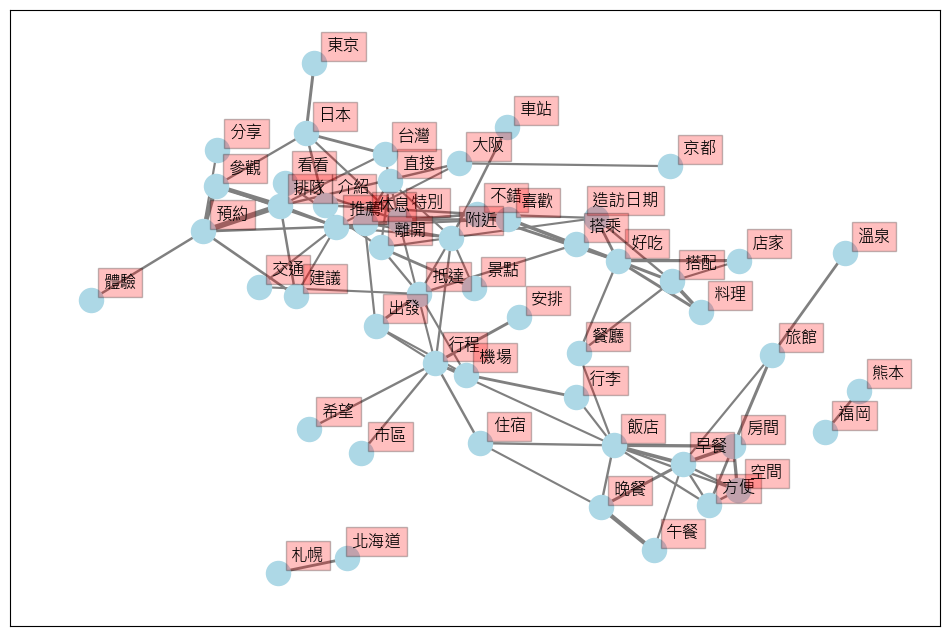

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

pos = nx.spring_layout(g_j, k=0.3)

# networks
nx.draw_networkx(g_j, pos,
                 font_size=16,
                 width=weights_j,
                 edge_color='grey',
                 node_color='lightblue',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=12)

plt.show()

此圖代表的是日旅版主題詞彙間的連結關係。

🔹 正中央密集群為行程規劃與交通動線，是旅客安排自由行時最基礎的討論源頭。包含「機場」、「出發」、「抵達」與「交通」等核心詞彙。

🔹 上方與周邊群組為熱門旅遊城市與景點。 描述的是旅客造訪的目的地輪廓，包含「東京」、「大阪」、「京都」、「北海道」等知名地名，並與「車站」相連，屬於地理與景點面向的語意群。

🔹 右下群則與住宿品質與餐飲體驗細節有關。 也是PPT論壇遊記高度聚焦的面向，呈現出網民對「飯店」、「旅館」、「房間」的空間感受，以及「早餐」、「晚餐」、「餐廳」與「料理」等實質吃住細節的強烈關注。

🔹 左側群與旅遊分享與體驗回饋有關。 探討旅客出發前與實際造訪後的準備與感受，包含「預約」、「參觀」、「排隊」以及網民的「推薦」、「分享」與「介紹」等延伸討論。

🔹 右側邊緣涉及特定區域與主題行程。 包含「福岡」、「熊本」與「溫泉」等詞，代表特定地區的深度旅遊與具體的泡湯行程體驗。

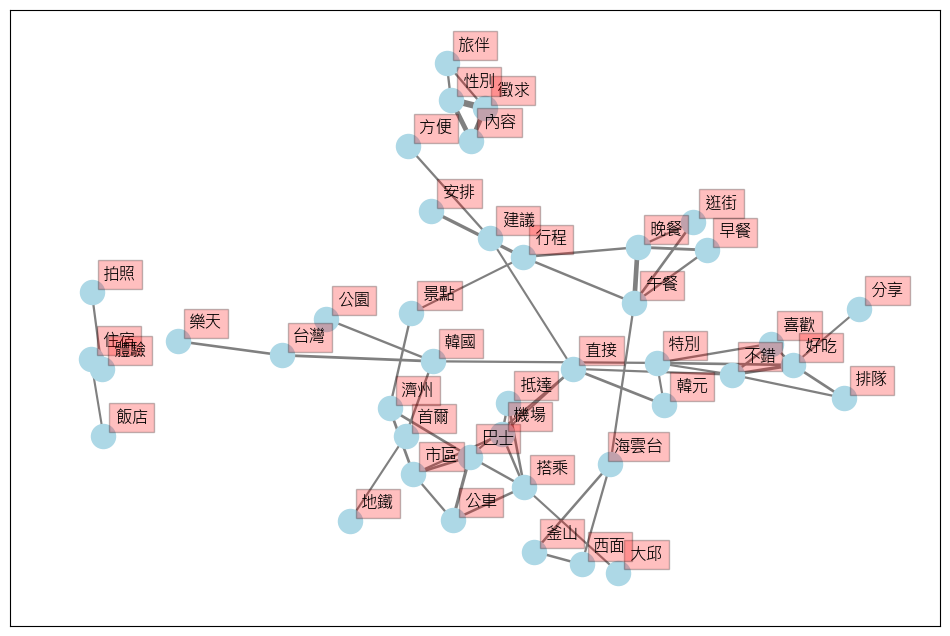

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

pos = nx.spring_layout(g_k, k=0.3)

# networks
nx.draw_networkx(g_k, pos,
                 font_size=16,
                 width=weights_k,
                 edge_color='grey',
                 node_color='lightblue',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=12)

plt.show()

此圖代表的是韓旅版詞彙間的連結關係。

🔸 正中央至中下群為當地交通轉乘與核心行程安排，是引發旅遊請益熱度的核心源頭。包含「韓國」、「首爾」、「機場」、「巴士」、「地鐵」、「公車」與「市區」等詞，顯示大眾運輸動線為討論主軸。

🔸 正上方群為徵求旅伴與同行條件。 描述的是論壇特有的社群互動本質，強調發文「徵求」「旅伴」時的「性別」限制與「內容」條件，屬於社群行動媒合面向的語意群。

🔸 右側群則與美食餐飲與逛街購物細節有關。 呈現出網民對「早餐」、「午餐」、「晚餐」、「逛街」行程的緊密安排，以及對「好吃」、「特別」的排隊名店與「韓元」消費等實質體驗的強烈熱衷。

🔸 右下角與南部重點旅遊城市有關。 探討首爾以外的觀光熱點，包含「釜山」、「海雲台」、「西面」與「大邱」等地緣延伸討論。

🔸 左側邊緣涉及住宿選擇與打卡體驗。 包含「飯店」、「住宿」、「體驗」與「拍照」等核心詞，代表旅客對實體旅館評價及旅遊留影記錄的具體關注行動。

----------

綜合日本與韓國的旅遊討論網絡，可以看出兩者在社群關注點上的異同：

🔹🔸共通點： 交通動線（機場、車站、轉乘）絕對是自由行請益的最核心樞紐。

🔹 日本線重 廣度與深度： 討論涵蓋多個熱門大城市，且極度重視「飯店空間」與「三餐/溫泉」等細緻的住宿體驗。

🔸 韓國線重 社交與吃逛： 獨立出明顯的「徵求旅伴」社交群集，並高度聚焦於「排隊美食」與特定商圈（釜山、海雲台）的實體走訪。

雖然日韓自由行皆以「交通攻略」為基石，但日本線的討論更偏向 深度體驗與住宿品質評比，而韓國線則展現出更強的 實體社交與吃喝逛街。

## 8. 主題模型

### 日本

把每一篇文章，整理成一個「由斷詞組成的字串清單（List of Words）」

In [ ]:
grouped_j = noStop_df_j.groupby(['artTitle', 'artDate'])['word'].apply(list).reset_index()
docs_j = grouped_j['word'].tolist()
docs_j[0]

['我個',
 '過一次',
 '函館',
 '想帶',
 '家人',
 '遊玩',
 '路線',
 '還算',
 '了解',
 '一共',
 '三人',
 '出遊',
 '大阪',
 '北海道',
 '請教',
 '三天',
 '函館',
 '有沒有',
 '麻煩',
 '版友',
 '提供',
 '1020',
 'Day8',
 '預計',
 '札幌',
 '函館',
 '深夜',
 '巴士',
 '早上',
 '530',
 '函館',
 '車站',
 'JR',
 'IN',
 '函館',
 '寄放',
 '行李',
 '海鮮',
 '市場',
 '逛逛',
 '過後',
 '星巴克',
 '濱海',
 '休息',
 '片刻',
 '估計',
 '半天',
 '慢慢',
 '以下',
 '金森',
 '紅磚',
 '倉庫',
 '八幡',
 '坡及',
 '洋式',
 '建築',
 '教會',
 '領事館',
 '甜品店',
 '咖啡店',
 '暫定',
 '午餐',
 '利本店',
 '尚未',
 '電話',
 '預約',
 '暫定',
 '晚餐',
 '幸運',
 '小丑',
 '本店',
 '旁邊',
 '燒鳥',
 '便當',
 '回飯店',
 '放著當',
 '宵夜',
 '回到',
 '小憩',
 '片刻',
 '估計',
 '點多',
 '函館',
 '車站',
 '公車',
 '函館',
 '晚上',
 '夜景',
 '官網',
 '好像',
 '期間',
 '纜車',
 '年度',
 '整修',
 '停駛',
 '理解',
 '錯誤',
 '改搭',
 '巴士',
 '1021',
 'Day9',
 '退房',
 '寄放',
 '行李',
 '估計',
 '點多',
 '電車',
 '大沼',
 '國定',
 '公園',
 '希望',
 '公園',
 '山川',
 '牧場',
 '冰淇淋',
 '預計',
 '中午',
 '左右',
 '搭車',
 '轉搭',
 '公車',
 '郭跡',
 '參觀',
 '午餐',
 '預計',
 '郭旁',
 '鹽味',
 '拉麵',
 '本店',
 '結束',
 '回到',
 'JR',
 'IN',
 '函館',
 '行李',
 '函館市',
 '電到',
 '湯之川',
 '溫泉',
 '稍微'

建立**詞典**並過濾掉出現頻率過高或過低的極端詞彙，以優化 LDA 模型的主題聚焦效果。

經過過濾（刪除出現少於 5 次、或超過 99% 文章都出現的詞）之後，你所有日本旅遊的文章中，一共留下了 5,899 個「有效關鍵詞」。接下來的 LDA 主題模型，就只會用這 5,899 個詞來計算與分群。

['1020', '1021', '1022', '1230', '530']...：
這是字典裡目前排在最前面的幾個詞（Token）的範例。在 PTT 日旅版的文章中，**這些數字通常代表時間（例如 10/20、10/21）、航班編號或是價格。**

In [ ]:
dictionary = Dictionary(docs_j)

dictionary.filter_extremes(no_below=5, no_above=0.99)
print(dictionary)

Dictionary<5899 unique tokens: ['1020', '1021', '1022', '1230', '530']...>


印出字典中前 12 個「關鍵字」與其對應的「數位編號（ID）」，以確認字詞編號對照表的建立狀況

In [ ]:
for idx, (k, v) in enumerate(dictionary.token2id.items()):
    print(f"{k}: {v}")
    if idx > 10:
        break

1020: 0
1021: 1
1022: 2
1230: 3
530: 4
Day10: 5
Day8: 6
Day9: 7
JR: 8
一共: 9
三人: 10
三天: 11


隨機抽樣（第 601 篇）文章，將該篇文章所有斷詞用「空格」串接起來並排版印出，用來檢查文字清理與斷詞的實際效果。

文中包含了讓售的標準格式欄位：品項、期限、物品、買入價格、欲售價格、交易方式（匯款後給 QR code、自行到車站兌換）以及聯絡方式（站內信）。反映出 PTT 日本旅遊版一個非常典型的文章類型——「票券讓售文」。

In [ ]:
pprint(" ".join(grouped_j['word'].iloc[600]))

('讓售 品項 東京 地鐵 一日券 大人 期限 2026424 物品 圖片 物品 買入 價格 讓售 小於 於此 金額 大人 332 欲售 價格 大人 300 '
 '交易 方式 匯款 後給 QR 自行 車站 兌換 聯絡 方式 內信 說明')


將所有文章的文字清單，轉換為 LDA 模型可以直接讀懂的「詞頻矩陣（Bag-of-Words, 簡稱 BoW）」向量語料庫（Corpus）

In [ ]:
# 建立 Bag-of-words 作為文章的特徵表示
# 用 gensim ldamodel input 需要將文章轉換成 bag of words
corpus = [dictionary.doc2bow(doc) for doc in docs_j]

訓練一個包含 5 個主題的 LDA 模型

主題1：聚焦在「日式溫泉旅館與在地美食的傳統文化體驗」：鄉民在分享與討論去日本旅遊時，最經典的傳統住宿與飲食享受。

主題2：聚焦在「跨區域的日本自由行（多日行程規劃與交通工具選擇）」：鄉民在版上向大家請益、分享「多天數（Day）」的日本行程順不順、交通路線如何銜接。

主題3：聚焦在「機場出入境與大眾運輸（特別是新幹線/JR）的鐵道交通銜接」：鄉民在討論如何從主要的國際機場順暢地轉乘交通工具前往日本各核心城市。

主題4：聚焦在「大阪萬博會（世博）等特定大型盛事與展館場館的現場參觀心得」：鄉民在分享或詢問去日本參加特定大型活動、展演或球賽時的實務攻略與現場體驗。

主題5：聚焦在「關西延伸西日本（京阪神、岡山、鳥取）的旅遊規劃與2025年最新資訊」：鄉民在討論與請益以關西地區（大阪、京都）為核心樞紐，並利用交通票券（如 JR Pass）向外延伸至岡山、鳥取等西日本地區的深度自由行規劃。

In [ ]:
model_5 = LdaModel(
    corpus = corpus,
    num_topics = 5,
    id2word=dictionary,
    random_state = 1500,
    passes = 5 # 訓練次數
    )
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(model_5, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.067935  0.081866       1        1  30.918384
4      0.125160  0.015082       2        1  22.867186
2      0.060438 -0.051397       3        1  18.901438
0     -0.103318 -0.068862       4        1  14.346008
1     -0.014344  0.023312       5        1  12.966984, topic_info=     Term        Freq       Total Category  logprob  loglift
122    預約  634.000000  634.000000  Default  30.0000  30.0000
170    排隊  462.000000  462.000000  Default  29.0000  29.0000
1572   場館  192.000000  192.000000  Default  28.0000  28.0000
586    入場  195.000000  195.000000  Default  27.0000  27.0000
84     札幌  308.000000  308.000000  Default  26.0000  26.0000
...   ...         ...         ...      ...      ...      ...
108    車站   49.619690  575.040257   Topic5  -6.0038  -0.4073
33     參觀   40.357467  224.113918   Topic5  -6.2104   0.3284
24     公園   43.959706  504.210570   Topic5  -6.1249  -0.3970
76     晚上   42.702741  456.219636   Topic5  -6.1539  -0.3259
95     神社   42.545266  481.098841   Topic5  -6.1576  -0.3827

[425 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
5439      2  0.894014   021
5171      3  0.144227  0603
5171      5  0.865362  0603
5820      3  0.164419  0604
5820      5  0.822096  0604
...     ...       ...   ...
3618      1  0.282899    麵條
3618      2  0.035362    麵條
3618      3  0.017681    麵條
3618      4  0.636523    麵條
3618      5  0.035362    麵條

[1327 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 5, 3, 1, 2])

In [ ]:
# 取得每條新聞的主題分佈
topics_doc = model_5.get_document_topics(corpus)

隨機抽樣（第 101 篇）文章，查看它在各個主題中的「機率分佈百分比」，用來檢查模型對單一文章的分類效果。

此執行結果代表這篇文章屬於主題 2 的機率高達 99.32%。

In [ ]:
topics_doc[100]

[(1, np.float32(0.9932652))]

In [ ]:
# 把 gensim 的稀疏表示法轉成稀疏矩陣
m_theta = corpus2csc(topics_doc).T.toarray() # 倒置讓shape變為(num_docs, num_topics)
m_theta

array([[0.        , 0.        , 0.49533558, 0.        , 0.50134087],
       [0.        , 0.        , 0.36727878, 0.        , 0.62734044],
       [0.        , 0.        , 0.63032728, 0.36733299, 0.        ],
       ...,
       [0.        , 0.        , 0.        , 0.        , 0.98889261],
       [0.        , 0.        , 0.97743815, 0.        , 0.        ],
       [0.01485793, 0.01463405, 0.94130778, 0.01469291, 0.01450732]])

In [ ]:
# 將主題的機率分布轉換成主題標籤
grouped_j['topic_label'] = m_theta.argmax(axis=1) + 1

統計並印出這 5 個主題在所有文章中各自被分配到了多少篇，觀察在 PTT 日旅版中，哪一個旅遊話題的「討論文章聲量最高（最熱門）」。

In [ ]:
grouped_j['topic_label'].value_counts()

,count
topic_label,
5,330
3,255
4,234
1,159
2,138


In [ ]:
grouped_j.head()

,artTitle,artDate,word,topic_label
0,10月北海道之旅請益（函館部分）,2025/6/23 12:20,"[我個, 過一次, 函館, 想帶, 家人, 遊玩, 路線, 還算, 了解, 一共, 三人, ...",5
1,10月底立山黑部/上高地行程請益,2025/8/1 23:53,"[實際, 跑起來, 會不會, 太累, 天內, 立山, 看著, 排起來, 還可以, 30, 體...",5
2,Fw:[分享]中華航空CI222台北松山TSA→東京羽田HND,2025/6/14 15:15,"[作者, lion1227, 阿達, 看板, Aviation, 標題, 中華, 航空, C...",3
3,Fw:[心得]到東京健身房訓練健力吧！,2025/8/27 11:04,"[作者, hunter72762, 阿帕契, 看板, MuscleBeach, 標題, 心得...",2
4,Fw:[食記]勝烈庵日本橫濱香酥現炸豬排爽脆高麗菜,2025/8/5 00:36,"[作者, Geiwoyujie, Food, 標題, 食記, 勝烈, 橫濱, 香酥, 炸豬排...",2


觀察 5 大旅遊主題的討論熱度，隨著「日期時間」推移的消長趨勢與比例變化。

例如2025-05-27：焦點在「行程」與「鐵道交通」

主題 2（佔 40%）最高：代表當天有四成的文章都在問「跨區域多日行程規劃、自駕與景點銜接」。

主題 3（佔 40%）並列最高：代表有四成的文章在討論「機場出入境與新幹線/JR鐵道交通轉乘」。

主題 5（佔 20%）：其餘兩成在聊「關西、岡山、鳥取旅遊」。

In [ ]:
grouped_j['artDate'] = pd.to_datetime(grouped_j['artDate'])
grouped_j.groupby(grouped_j['artDate'].dt.date)['topic_label'].value_counts(normalize=True)

artDate     topic_label
2025-05-27  2              0.400000
            3              0.400000
            5              0.200000
2025-05-28  5              0.400000
            1              0.200000
                             ...   
2025-10-01  4              0.083333
2025-10-02  1              0.333333
            3              0.333333
            5              0.222222
            2              0.111111
Name: proportion, Length: 493, dtype: float64

將前面計算好的「每日主題比例」統計結果，從垂直的清單格式轉換成水平的表格，並印出前 5 天的資料。

In [ ]:
date_topic = grouped_j.groupby(grouped_j['artDate'].dt.date)['topic_label'].value_counts(normalize=True).unstack()
date_topic.head()

topic_label,1,2,3,4,5
artDate,,,,,
2025-05-27,NaN,0.400000,0.400000,NaN,0.200000
2025-05-28,0.200000,0.100000,0.100000,0.200000,0.400000
2025-05-29,0.133333,0.133333,0.133333,0.133333,0.466667
2025-05-30,0.375000,NaN,NaN,0.375000,0.250000
2025-05-31,0.200000,0.400000,NaN,NaN,0.400000


在大多數的日子裡，5 個主題同時存在於當天的討論中。主題 4 與 主題 5 在許多日子裡都佔據了相當顯著的比例，是社群討論的常態主力。

極端的大幅波動（突發焦點日）：因為是以「日」為單位，可以明顯觀察到某些日子的討論比例出現劇烈極端化：

單一話題強勢主導：圖中有幾天的柱子，幾乎完全被 主題 4 填滿（例如在 9 月中旬與 5 月底的某些日子），代表當天社群可能發生了重大的特定盛事，導致九成以上的討論都集中在該主題。

特定主題的突發增長：在 7 月中旬（約 2025-07-13 左右），出現了一根幾乎完全由 主題 3 與 主題 1 組成、而主題 4 降到極低的特殊日子；此外，8 月中旬也有幾天主題 3 的比例明顯集中的現象。

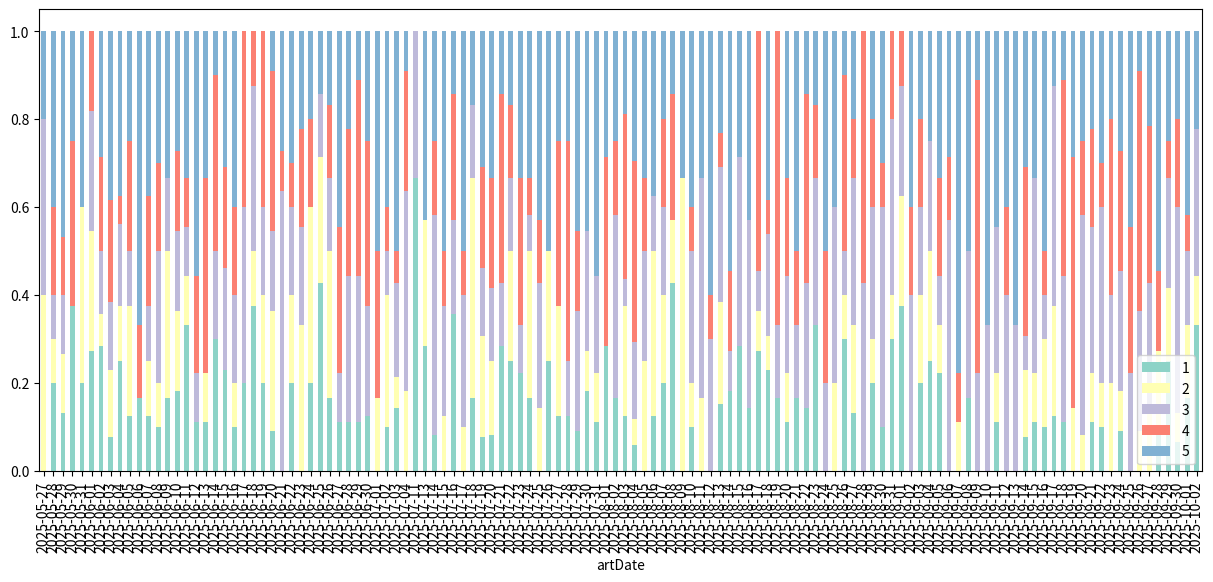

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
date_topic.plot.bar(ax=ax, stacked=True, color = plt.cm.Set3.colors)
ax.legend(loc='lower right')

### 韓國

In [ ]:
grouped_k = noStop_df_k.groupby(['artTitle', 'artDate'])['word'].apply(list).reset_index()
docs_k = grouped_k['word'].tolist()
docs_k[0]

['po',
 '徵求',
 '類別',
 '夜店',
 '徵伴',
 '性別',
 '1993',
 '徵求',
 '女性',
 '為主',
 '324',
 '弘大',
 '夜店',
 '好玩',
 'BAR',
 '決定',
 '329',
 '江南',
 'RACE',
 'OCTAGON',
 '夜店',
 'BAR',
 '喝杯',
 '認識',
 '聊天',
 '內容',
 '臨時',
 '同行',
 '友人',
 '放鳥',
 '夜店',
 '問問',
 '有沒有',
 '興趣',
 '夥伴',
 '會想',
 '熟悉',
 '韓文',
 '哪間',
 '夜店',
 '討論',
 '24',
 '29',
 '弘大',
 '江南',
 '想以',
 '這兩個',
 '區塊',
 '為主',
 '真心',
 '希望',
 '找到',
 '同行',
 '夥伴',
 '啊啊',
 '備註',
 '麻煩',
 '興趣',
 '內信',
 '留下',
 'LINE',
 'ID',
 '聯繫']

In [ ]:
dictionary = Dictionary(docs_k)

dictionary.filter_extremes(no_below=5, no_above=0.99)
print(dictionary)

Dictionary<3967 unique tokens: ['24', '29', 'ID', 'LINE', 'po']...>


In [ ]:
for idx, (k, v) in enumerate(dictionary.token2id.items()):
    print(f"{k}: {v}")
    if idx > 10:
        break

24: 0
29: 1
ID: 2
LINE: 3
po: 4
備註: 5
內信: 6
內容: 7
區塊: 8
友人: 9
同行: 10
哪間: 11


In [ ]:
pprint(" ".join(grouped_k['word'].iloc[600]))

('徵求 類別 徵求 首爾 食伴 性別 三十中代胖 阿姨 921923 首爾 食伴 晚餐 男女 分食 份量 餐點 ex 糖醋 炸雞 嘗試 市場 多樣 小吃 '
 '五年 挑戰 釜山 大邱 幸運 認識 幾個 不雷好 飯友 一大 年紀 首爾 疫情 首飛 再來 碰碰運氣 煩惱 用餐 交個 社恐 ISFJ 至少 放鳥 生日 '
 '閃行 心情 吃飯 旅行 配合 歡迎 內信 聯絡')


In [ ]:
# 建立 Bag-of-words 作為文章的特徵表示
# 用 gensim ldamodel input 需要將文章轉換成 bag of words
corpus = [dictionary.doc2bow(doc) for doc in docs_k]

**訓練一個包含 5 個主題的 LDA 模型**

主題1：聚焦在「韓國三大城市（首爾、釜山、大邱）的經典在地美食與熱門商圈住宿交通」：鄉民在分享與詢問去韓國旅遊時，最不可錯過的傳統美食體驗與明星商圈的便利住宿。

主題2：聚焦在「以釜山為核心的海岸線風光、膠囊列車與周邊歷史城市（慶州）的踩點行程」：鄉民在討論與分享前往南韓第二大城釜山以及鄰近古都慶州的經典觀光路線與熱門打卡景點。

主題3：聚焦在「出發前往韓國（首爾、釜山）前的徵旅伴、徵食伴與結伴分攤費用」：鄉民利用旅遊版作為媒合平台，尋找可以一起在韓國旅行、分攤開銷或一起吃飯的夥伴。

主題4：聚焦在「首爾時髦商圈（聖水洞、弘大）、濟州島自然風光與文化景點的網美打卡與文青散策」：鄉民在分享或尋求去韓國時，適合慢活散步、拍照紀錄與感受歷史文化的特色景點。

主題5：聚焦在「韓國各大機場（仁川、清州、金海）的航班搭乘與落地後的聯外交通接駁」：鄉民在討論如何從台灣出發抵達韓國各大機場，以及下飛機後如何順暢地轉乘大眾運輸前往市區。

In [ ]:
model_5 = LdaModel(
    corpus = corpus,
    num_topics = 5,
    id2word=dictionary,
    random_state = 1500,
    passes = 5 # 訓練次數
    )
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(model_5, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.065547 -0.066000       1        1  26.220182
4      0.086691 -0.051703       2        1  21.806861
3      0.080777  0.024849       3        1  21.350661
2     -0.086694  0.006117       4        1  18.081406
0     -0.015227  0.086737       5        1  12.540889, topic_info=     Term         Freq        Total Category  logprob  loglift
20     徵求   235.000000   235.000000  Default  30.0000  30.0000
106    首爾  1110.000000  1110.000000  Default  29.0000  29.0000
596    釜山   855.000000   855.000000  Default  28.0000  28.0000
21     性別   192.000000   192.000000  Default  27.0000  27.0000
1417  海雲台   258.000000   258.000000  Default  26.0000  26.0000
...   ...          ...          ...      ...      ...      ...
27     決定    27.916882   111.461501   Topic5  -6.0553   0.6917
70     抵達    31.701118   210.833116   Topic5  -5.9282   0.1815
162    不用    29.715658   184.487530   Topic5  -5.9929   0.2503
20     徵求    29.335005   235.285145   Topic5  -6.0058  -0.0058
51     之後    27.128148   131.834284   Topic5  -6.0840   0.4952

[410 rows x 6 columns], token_table=      Topic      Freq Term
term                      
836       1  0.517403  000
836       2  0.087273  000
836       3  0.174546  000
836       4  0.118442  000
836       5  0.099740  000
...     ...       ...  ...
1328      2  0.820041   龍宮
1328      3  0.136673   龍宮
1329      1  0.024838  龍宮寺
1329      2  0.844489  龍宮寺
1329      3  0.099352  龍宮寺

[1273 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 5, 4, 3, 1])

In [ ]:
# 取得每條新聞的主題分佈
topics_doc = model_5.get_document_topics(corpus)

In [ ]:
topics_doc[100]

[(0, np.float32(0.02041301)),
 (1, np.float32(0.02032846)),
 (2, np.float32(0.020134272)),
 (3, np.float32(0.91880405)),
 (4, np.float32(0.020320209))]

In [ ]:
# 把 gensim 的稀疏表示法轉成稀疏矩陣
m_theta = corpus2csc(topics_doc).T.toarray() # 倒置讓shape變為(num_docs, num_topics)
m_theta

array([[0.        , 0.        , 0.        , 0.98501325, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.99060333],
       [0.21973485, 0.        , 0.        , 0.7560094 , 0.        ],
       ...,
       [0.97870874, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.59233755, 0.        , 0.38961756, 0.        ],
       [0.        , 0.        , 0.        , 0.71128136, 0.26676524]])

In [ ]:
# 將主題的機率分布轉換成主題標籤
grouped_k['topic_label'] = m_theta.argmax(axis=1) + 1

In [ ]:
grouped_k['topic_label'].value_counts()

,count
topic_label,
4,468
2,194
5,183
1,122
3,106


In [ ]:
grouped_k.head()

,artTitle,artDate,word,topic_label
0,0324、0329誠徵夜店夥伴（女性）,2024/3/19 20:08,"[po, 徵求, 類別, 夜店, 徵伴, 性別, 1993, 徵求, 女性, 為主, 324...",4
1,10月韓國行程請益,2023/9/25 10:49,"[中要, 好不好, 請求, 幫忙, 調整, 有什麼, 意見, 提供給, 參考, Day1, ...",5
2,11/27仁川二航共乘至明洞,2024/11/25 20:35,"[徵求, 類別, 共乘, 性別, 1127, 晚上, 計程車, 共乘, 首爾, 市區, 大韓...",4
3,12/30-31食伴,2023/12/11 22:43,"[徵求, 類別, 食伴, 性別, 30, 前半, 分食, 夥伴, 次飛, 吃吃, 給他, 多...",4
4,2025韓國遊學推薦｜LEXISKorea弘大新校區,2025/10/10 23:15,"[LEXIS, 弘大, 校區, 一週, VLOG, 學堂, VS, 補習班, 評比, 外國人...",3


#### **以「日」計算主題比例**

In [ ]:
grouped_k['artDate'] = pd.to_datetime(grouped_k['artDate'])
grouped_k.groupby(grouped_k['artDate'].dt.date)['topic_label'].value_counts(normalize=True)

artDate     topic_label
2023-04-27  1              0.5
            2              0.5
2023-04-28  2              0.5
            4              0.5
2023-04-29  2              1.0
                          ... 
2026-04-26  5              1.0
2026-04-27  3              1.0
2026-04-29  5              1.0
2026-04-30  2              1.0
2026-05-04  4              1.0
Name: proportion, Length: 902, dtype: float64

In [ ]:
date_topic = grouped_k.groupby(grouped_k['artDate'].dt.date)['topic_label'].value_counts(normalize=True).unstack()
date_topic.head()

topic_label,1,2,3,4,5
artDate,,,,,
2023-04-27,0.500000,0.500000,NaN,NaN,NaN
2023-04-28,NaN,0.500000,NaN,0.500000,NaN
2023-04-29,NaN,1.000000,NaN,NaN,NaN
2023-04-30,NaN,NaN,NaN,1.000000,NaN
2023-05-01,0.333333,0.333333,NaN,0.333333,NaN


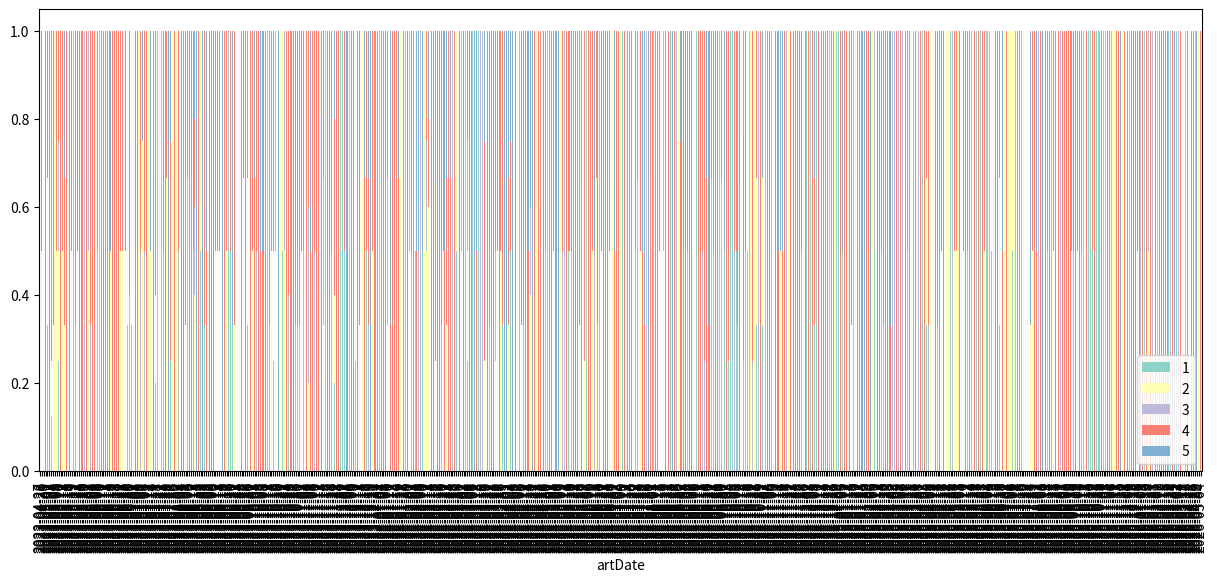

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
date_topic.plot.bar(ax=ax, stacked=True, color = plt.cm.Set3.colors)
ax.legend(loc='lower right')

#### **以「月份 (Monthly)」計算主題比例**
主導話題：在絕大多數的月份中，主題 4 佔據了單月柱狀圖中最大的面積比例，顯示該話題在整個觀測區間內是討論聲量最穩定且最龐大的核心主題。

季節性或突發性波動：

2023-04：主題 2 佔了將近一半的比例，而當月完全沒有主題 3  與主題 5  的分佈。

2024-12：主題 1  出現了明顯的區塊增長。

2025-02 至 2025-03：主題 3 的比例顯著擴大，在 2025-02 甚至與主題 4 分庭抗禮。

2025-09、2025-10、2025-12、2026-05：在這些特定月份中，主題 5 的比例縮減到極低甚至接近消失，使得當月幾乎完全由主題 4 或其他話題主導。

2026-05：在最後一個觀測月份，主題 4 的比例達到了極致，幾乎吞噬了整根柱子，其他主題的比例微乎其微。

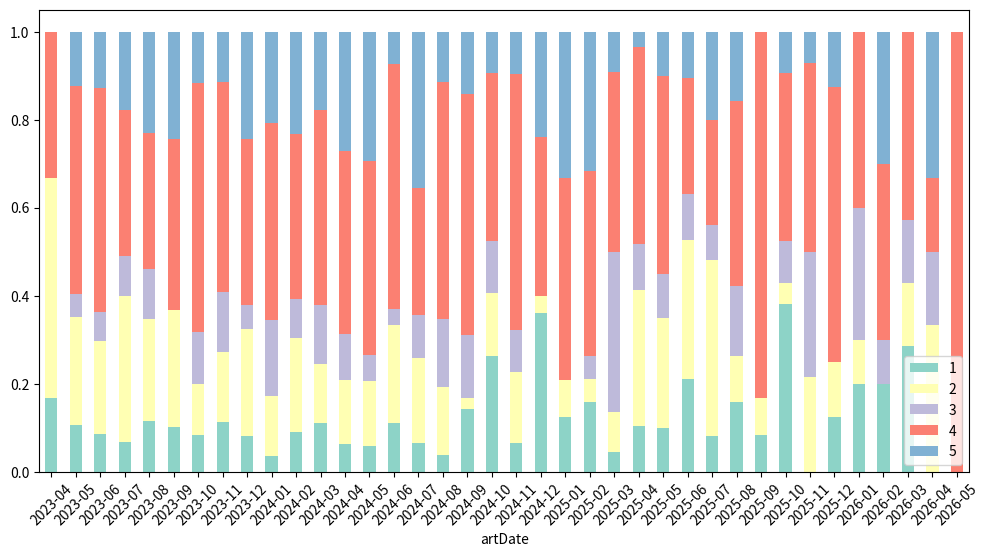

In [ ]:
grouped_k['artDate'] = pd.to_datetime(grouped_k['artDate'])
month_topic = grouped_k.groupby(grouped_k['artDate'].dt.to_period('M'))['topic_label'].value_counts(normalize=True).unstack()
month_topic = month_topic.fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
month_topic.plot.bar(ax=ax, stacked=True, color = plt.cm.Set3.colors)
ax.legend(loc='lower right')
plt.xticks(rotation=45)
plt.show()

## 9. 結論
**一、 日本旅遊版（日旅版）討論方向**


*   **極度重視行前規劃與預約：** 在日旅版的前十大高頻詞彙中，「預約」（654次）位居榜首，此外「日期」（549次）與「住宿」（530次）也名列前茅，顯示赴日旅遊需要大量的行程確認與事前卡位。

*   **文化體驗與自然觀光：** 除了大城市「東京」（555次）之外，旅客高度關注「溫泉」（528次）、「公園」（519次）與「神社」（495次），行程多樣且偏向深度體驗。

*   **交通依賴與時間成本：**「車站」（599次）是第二大高頻詞，顯示日本鐵道旅行的普及；同時「排隊」（473次）也是核心熱詞，突顯出在日本熱門餐廳或景點常需耗費較多的時間成本。

**二、 韓國旅遊版（韓旅版）討論方向**

*   **旅遊目的地高度集中：**「首爾」（1162次）與「釜山」（904次）以壓倒性的次數佔據榜首，顯示赴韓旅遊的地點非常集中於這兩大城市。

*   **主打「吃」與「買」的商圈行程：** 高頻詞彙包含了「市場」（359次）、「明洞」（336次）、「樂天」（300次）與「餐廳」（280次），反映出韓國旅遊的討論主軸極度圍繞在逛街購物與美食體驗。

*   **市區移動與行李處理：** 交通討論多集中於短程市區移動的「地鐵」（291次）與「計程車」（286次）；另外，「行李」（307次）一詞上榜，可能與大量購物後的移動需求或機場往返的寄放問題有關。

三、 總體比較與特殊發現

*   **旅遊型態差異（體驗放鬆 vs. 都市消費）：** 日本的討論除了城市外，有很大部分聚焦於「溫泉」與「神社」的文化休閒；韓國的討論則幾乎都是都市型的消費娛樂（如市場、明洞、樂天）。

*   **交通與痛點差異（車站排隊 vs. 計程車行李）：** 日本旅遊的移動以「車站」為核心，主要痛點可能是各種名店與景點的「排隊」狀況與繁瑣的「預約」制度。韓國旅遊則更依賴「地鐵」與「計程車」，並常需要處理「行李」問題。

*   **地點發散程度不同：** 韓國討論聲量幾乎被「首爾」與「釜山」囊括，顯示地點單一性高；而日本雖然「東京」上榜，但也穿插了神戶、高千穗、函館、東北、北海道等多元近郊或遠程景點（從內文段落可見），顯示赴日旅遊的地域分布較為廣泛。